# Logistic regression 

## Initialize

In [1]:
# import required libraries
import numpy as np
from numpy.polynomial.polynomial import Polynomial
import sympy as sp
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import tensorflow as tf #type: ignore
import torch #type: ignore
import torch.nn.functional as F #type: ignore
#
from IPython.display import display, Math
# Import typyng library for type hinting
from typing import Callable, Union, List, Any, Tuple
#
# Initialize pretty printing
sp.init_printing()

## Logistic function (sigmoid)

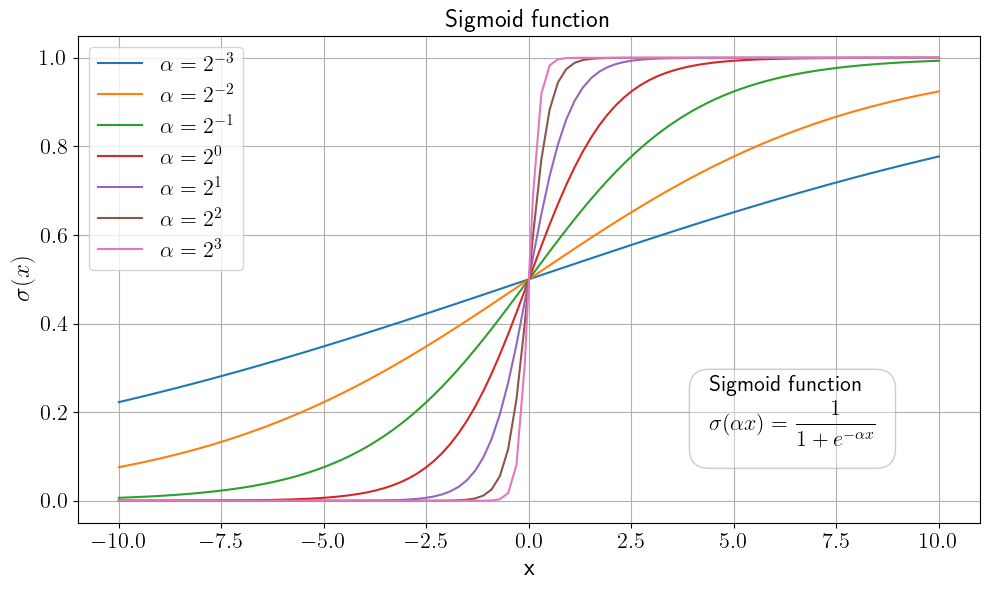

In [2]:
# Show plot of the sigmoit function for different values of alpha
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

x = np.linspace(-10, 10, 100)
plt.figure(figsize=(10, 6))
for i in range(-3, 4):
    alpha = 2**i
    y = 1 / (1 + np.exp(-alpha * x))
    plt.plot(x, y, label=r"$\alpha=2^{%d}$" % i)
    
plt.text(
            0.7, 0.3,
            'Sigmoid function\n' + r'$\displaystyle\sigma(\alpha x) = \frac{1}{1 + e^{-\alpha x}}$',
            transform=plt.gca().transAxes,  # Use axis coordinates (0,0) lower left, (1,1) upper right
            horizontalalignment='left',     # Align text to the right edge of the box
            verticalalignment='top',         # Align text to the top edge of the box
            fontsize=16,
            color='black',
            bbox=dict(facecolor='white', edgecolor='gray', alpha=0.4, boxstyle='round,pad=0.9')
)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel("x", fontsize = 18)
plt.ylabel(r"$\sigma(x)$", fontsize = 18)
plt.legend(loc='upper left', fontsize = 16)
plt.grid(True)
plt.title("Sigmoid function", fontsize = 18)
plt.tight_layout()
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_linear.pdf')
plt.show()

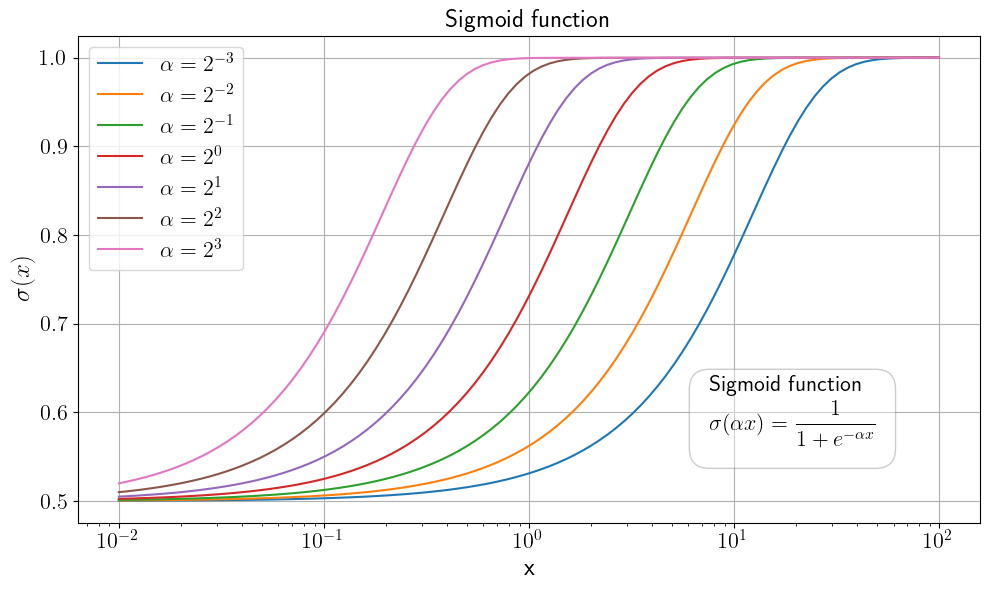

In [3]:
# Show plot of the sigmoit function for different values of alpha in log scale
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

x = np.logspace(-2, 2, 100)
plt.figure(figsize=(10, 6))
for i in range(-3, 4):
    alpha = 2**i
    y = 1 / (1 + np.exp(-alpha * x))
    plt.plot(x, y, label=r"$\alpha=2^{%d}$" % i)
    
plt.text(
            0.7, 0.3,
            'Sigmoid function\n' + r'$\displaystyle\sigma(\alpha x) = \frac{1}{1 + e^{-\alpha x}}$',
            transform=plt.gca().transAxes,  # Use axis coordinates (0,0) lower left, (1,1) upper right
            horizontalalignment='left',     # Align text to the right edge of the box
            verticalalignment='top',         # Align text to the top edge of the box
            fontsize=16,
            color='black',
            bbox=dict(facecolor='white', edgecolor='gray', alpha=0.4, boxstyle='round,pad=0.9')
)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel("x", fontsize = 18)
plt.ylabel(r"$\sigma(x)$", fontsize = 18)
plt.legend(loc='upper left', fontsize = 16)
plt.grid(True)
plt.title("Sigmoid function", fontsize = 18)
plt.xscale('log')
plt.tight_layout()
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_log.pdf')
plt.show()

## Numpy

### Deterministic model (linear data)

In [273]:
# Define symbols
x = sp.symbols('x', real=True)
omega0, omega1 = sp.symbols('omega0 omega1', real=True)

# Define the polynomial: poly(omega0, omega1, 0, 0, x) = omega0 + omega1*x
poly = omega0 + omega1 * x

# Define the logistic function: y(omega, x) = 1/(1 + exp(-poly))
y = 1/(1 + sp.exp(-poly))

# Set the true parameters (omega_true = {2, -3})
omega_true = {omega0: 2, omega1: -3}

# Solve for x such that y(omega_true, x) == 0.5
solution = sp.solve(sp.Eq(y.subs(omega_true), 0.5), x)
db = solution[0]

print("Decision boundary x =", db)

Decision boundary x = 0.666666666666667


In [274]:
def poly(x: float, omega: np.ndarray) -> float:
    """Evaluates a polynomial with coefficients omega at x.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients of the polynomial.
        
    Returns
    -------
    float
        Polynomial value.
    """
    output = 0.0
    for i, omega_i in enumerate(omega):
        output += omega_i * x**i
    return output

def p(x: float, omega: np.ndarray) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega)
    return 1.0 / (1.0 + np.exp(-poly_val))

def p_approx(x: float, omega: np.ndarray) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega)
    return 1./2 + poly_val/4.

def design_matrix(x: np.ndarray, degree: int) -> np.ndarray:
    """Computes the design matrix for a polynomial of a given degree.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    degree : int
        Degree of the polynomial.
    
    Returns
    -------
    np.ndarray
        Design matrix.
    """
    X = np.zeros((len(x), degree + 1))
    for i in range(degree + 1):
        X[:, i] = x**i
    return X

In [275]:
# Define the true parameters
omega_true = np.array([2, -3])

# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Define the approximate objective: squared difference between y_approx(x,omega_true) and 0.5.
def objective_approx(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p_approx(x_scalar, omega) - 0.5)**2

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])

# Optimize using minimize; here we pass omega_true as an extra argument.
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')

# Optimize using minimize; here we pass omega_true as an extra argument.
result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary x =", result.x[0])
print("Objective value =", result.fun)
decision_boundary = result.x[0]

print("Decision boundary (from approx solution) x =", result_approx.x[0])
print("Objective value (from approx solution) =", result_approx.fun)

Decision boundary x = 0.6666669622623926
Objective value = 4.914946870639898e-14
Decision boundary (from approx solution) x = 0.6666666593080686
Objective value (from approx solution) = 3.0458793996399694e-17


In [276]:
# Generate data coordinates
x_train = np.sort(np.concatenate(((2/3) - 0.02 * np.arange(1, 101),(2/3) + 0.02 * np.arange(1, 101))))
x_val = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) + 0.03
x_test = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) - 0.03

X_train = design_matrix(x_train, 1)
X_val = design_matrix(x_val, 1)
X_test = design_matrix(x_test, 1)

p_train = p(x_train, omega_true)
p_val = p(x_val, omega_true)
p_test = p(x_test, omega_true)

Y_train = np.array([1 if p_i >= 0.5 else 0 for p_i in p_train])
Y_val = np.array([1 if p_i >= 0.5 else 0 for p_i in p_val])
Y_test = np.array([1 if p_i >= 0.5 else 0 for p_i in p_test])

In [277]:
omega_approx = np.linalg.pinv(X_train.T @ X_train) @ (4 * X_train.T @ Y_train - 2 * X_train.T @ np.ones_like(Y_train))
print("Approximate omega:", omega_approx)

result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary (from approx solution) x =", result_approx.x[0])

Approximate omega: [ 0.99502488 -1.49253731]
Decision boundary (from approx solution) x = 0.6666666593080686


In [278]:
def Y_pred(p: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    """Converts probabilities to predictions using a threshold.
    
    Parameters
    ----------
    p : np.ndarray
        Probabilities.
    threshold : float
        Threshold for the conversion.
    
    Returns
    -------
    np.ndarray
        Predictions.
    """
    return np.array([1 if p_i > threshold else 0 for p_i in p])

def loss_fn(X: np.ndarray, 
            p: np.ndarray, 
            omega: np.ndarray,
            threshold: float = 0.5) -> float:
    """Computes the logistic loss for a given dataset and parameters.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega : np.ndarray
        Parameters.
    
    Returns
    -------
    float
        Logistic loss.
    """
    Y = Y_pred(p, threshold)
    res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
    return -1 * res

In [279]:
# Minimize the loss function and extract omega
objective = lambda omega: loss_fn(X_train, p_train, omega)
result = minimize(objective, omega_true, method='BFGS')
omega_exact = result.x

In [280]:
loss_fn(X_train, p_train, omega_true)

In [281]:
loss_fn(X_train, p_train, omega_exact)

In [282]:
train_loss = loss_fn(X_train, Y_train, omega_approx)
val_loss = loss_fn(X_val, Y_val, omega_approx)
test_loss = loss_fn(X_test, Y_test, omega_approx)
print("Train loss:", train_loss)
print("Validation loss:", val_loss)
print("Test loss:", test_loss)

Train loss: 51.11964133050873
Validation loss: 25.256239837580452
Test loss: 25.256239837580452


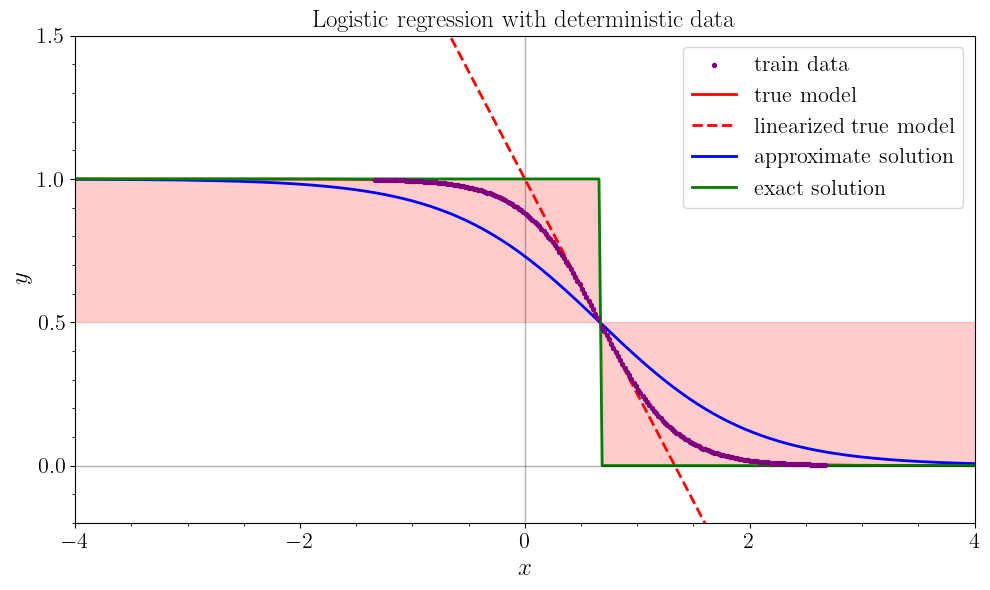

In [283]:
save = True

def H(c: float) -> float:
    """Computes the entropy function H(c).
    
    Parameters
    ----------
    c : float
        Value of c.
    
    Returns
    -------
    float
    
        Entropy value.
    """
    return np.heaviside(c, 0.5)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Generate custom tick marks ---
x_major_ticks = np.arange(-10, 10+1, 2)
x_minor_ticks = np.arange(-10, 10+0.5, 0.5)
y_major_ticks = np.arange(-2, 2+0.5, 0.5)
y_minor_ticks = np.arange(-2, 2+0.1, 0.1)

# --- Define plotting range and decision boundary ---
x_plot = np.linspace(-7, 7, 500)

# --- Create the main plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot training data ---
# Assume x_train and p_train are numpy arrays. For demonstration, we create dummy data:
ax.scatter(x_train, p_train, color='purple', s=8, zorder=5, label=r'$\text{train data}$')

# Plot the various curves with styles similar to your Mathematica code:
ax.plot(x_plot, p(x_plot,omega_true), color='red', linewidth=2, label=r'$\text{true model}$')
ax.plot(x_plot, p_approx(x_plot,omega_true), color='red', linestyle='--', linewidth=2, label=r'$\text{linearized true model}$')
ax.plot(x_plot, p(x_plot, omega_approx), color='blue', linewidth=2, label=r'$\text{approximate solution}$')
ax.plot(x_plot, H(decision_boundary - x_plot), color='green', linewidth=2, label=r'$\text{exact solution}$')
# The constant 0.5 curve (with zero opacity) is included for filling purposes:
ax.plot(x_plot, 0.5*np.ones_like(x_plot), color='black', alpha=0, linewidth=2)

# Fill between the constant 0.5 and the Heaviside curve.
# In Mathematica, you filled curve 5 -> 4 and 4 -> 5.
# Here, we assume we want to fill between heaviside(db - x) and 0.5.
# Choose the fill condition appropriately. Here, we fill where heaviside < 0.5.
ax.fill_between(x_plot, H(decision_boundary - x_plot), 0.5, where=(H(decision_boundary - x_plot) < 0.5),
                color='red', alpha=0.2)
ax.fill_between(x_plot, 0.5, H(decision_boundary - x_plot), where=(H(decision_boundary - x_plot) > 0.5),
                color='red', alpha=0.2)

# Draw axes
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Finalizing plot
plt.title(f'Logistic regression with deterministic data', fontsize = 18)
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)
#ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
#ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)
ax.set_xlabel(r'$x$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.legend(loc='upper right', fontsize=16)
ax.set_xlim(-4,4)
ax.set_ylim(-0.2, 1.5)

# --- Adjust aspect ratio and layout ---
plt.tight_layout()

# --- Save and show the figure ---
if save:
    plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution.pdf')
plt.show()

In [284]:
Y_pred(p_train, threshold=0.5)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [285]:
ytrue = Y_pred(p(x_train, omega_true), threshold=0.5)
ypred = Y_pred(p(x_train, omega_approx), threshold=0.5)

TP = np.sum((ypred == 1) & (ytrue == 1))
FP = np.sum((ypred == 1) & (ytrue == 0))
FN = np.sum((ypred == 0) & (ytrue == 1))
TN = np.sum((ypred == 0) & (ytrue == 0))

confusion_matrix = np.array([[TP, FP],
                             [FN, TN]])

print(confusion_matrix)

[[100   0]
 [  0 100]]


In [286]:
def ROC_curve(x: np.ndarray, 
              omega_solution: np.ndarray,
              p_true: np.ndarray,
             ) -> Tuple[np.ndarray, np.ndarray]:
    """Computes the ROC curve for a given dataset and parameters.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    omega_true : np.ndarray
        True parameters.
    onega_solution : np.ndarray
        Estimated parameters.
    
    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        ROC curve.
    """
    p_solution = p(x, omega_solution)
    
    #thresholds = np.unique(np.concatenate((p_true, p_approx)))
    thresholds = np.linspace(0, 1, 1000)
    spacing = thresholds[1] - thresholds[0]
    TPR = []
    FPR = []
    AUC = 0.0
    
    for i, threshold in enumerate(thresholds):
        y_true = Y_pred(p_true, 0.5)
        y_pred = Y_pred(p_solution, threshold)
        
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        FN = np.sum((y_pred == 0) & (y_true == 1))
        TN = np.sum((y_pred == 0) & (y_true == 0))
        
        if (TP + FN) > 0:
            TPR.append(TP / (TP + FN))
        else:
            TPR.append(0.0)
    
        if (FP + TN) > 0:
            FPR.append(FP / (FP + TN))
        else:
            FPR.append(0.0)

        AUC += TPR[-1] * spacing
        
    return FPR, TPR, AUC

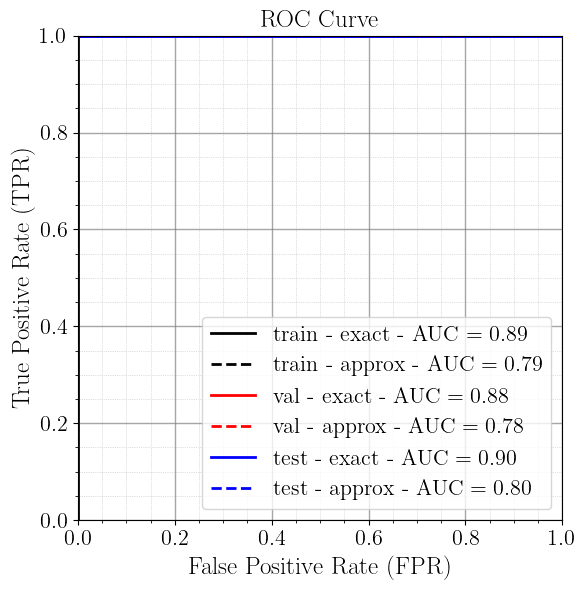

In [287]:
import numpy as np
import matplotlib.pyplot as plt

# Assume ROC_curve returns two numpy arrays: FPR and TPR, both in [0,1].
FPR_train_exact, TPR_train_exact, AUC_train_exact = ROC_curve(x_train, omega_true, p_train)
FPR_train_approx, TPR_train_approx, AUC_train_approx = ROC_curve(x_train, omega_approx, p_train)
FPR_val_exact, TPR_val_exact, AUC_val_exact = ROC_curve(x_val, omega_true, p_val)
FPR_val_approx, TPR_val_approx, AUC_val_approx = ROC_curve(x_val, omega_approx, p_val)
FPR_test_exact, TPR_test_exact, AUC_test_exact = ROC_curve(x_test, omega_true, p_test)
FPR_test_approx, TPR_test_approx, AUC_test_approx = ROC_curve(x_test, omega_approx, p_test)

# --- Define custom tick marks ---
x_major_ticks = np.arange(0, 1.01, 0.2)
x_minor_ticks = np.arange(0, 1.01, 0.05)
y_major_ticks = np.arange(0, 1.01, 0.2)
y_minor_ticks = np.arange(0, 1.01, 0.05)

# Enable LaTeX rendering for text (if a full TeX installation is available)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage{amssymb}'

# --- Create the ROC plot ---
fig, ax = plt.subplots(figsize=(6, 6))  # Square figure for aspect ratio 1

# Plot the ROC curve as a joined red, thick line.
ax.plot(FPR_train_exact, TPR_train_exact, color='black', linewidth=2, label=r'$\text{train - exact - AUC} = %.2f$' % AUC_train_exact)
ax.plot(FPR_train_approx, TPR_train_approx, color='black', linestyle='--', linewidth=2, label=r'$\text{train - approx - AUC} = %.2f$' % AUC_train_approx)
ax.plot(FPR_val_exact, TPR_val_exact, color='red', linewidth=2, label=r'$\text{val - exact - AUC} = %.2f$' % AUC_val_exact)
ax.plot(FPR_val_approx, TPR_val_approx, color='red', linestyle='--', linewidth=2, label=r'$\text{val - approx - AUC} = %.2f$' % AUC_val_approx)
ax.plot(FPR_test_exact, TPR_test_exact, color='blue', linewidth=2, label=r'$\text{test - exact - AUC} = %.2f$' % AUC_test_exact)
ax.plot(FPR_test_approx, TPR_test_approx, color='blue', linestyle='--', linewidth=2, label=r'$\text{test - approx - AUC} = %.2f$' % AUC_test_approx)

# Set title
plt.title(r'$\text{ROC Curve}$', fontsize = 18)

# Set the plot range.
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Set the aspect ratio to 1.
ax.set_aspect('equal')

# Set custom major and minor ticks.
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# Set axis labels in LaTeX.
ax.set_xlabel(r'$\text{False Positive Rate (FPR)}$', fontsize=18)
ax.set_ylabel(r'$\text{True Positive Rate (TPR)}$', fontsize=18)

# Add a legend in the lower right.
ax.legend(loc='lower right', fontsize=16)

# Optionally, add grid lines for better readability.
ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)

plt.tight_layout()

# Save the figure as a PDF file.
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution_roc.pdf')

plt.show()

### Probabilistic model (linear data)

In [288]:
def poly(x: np.ndarray, 
         omega: np.ndarray, 
         noise_std: float = 0.
        ) -> np.ndarray:
    """
    Evaluates a polynomial with coefficients omega at x, adding independent Gaussian noise 
    to each coefficient for each data point.
    
    Parameters
    ----------
    x : np.ndarray
        Input values. Can be a scalar or a 1D numpy array.
    omega : np.ndarray
        Coefficients of the polynomial.
    noise_std : float, optional
        Standard deviation of the Gaussian noise added to each coefficient, by default 1.
        
    Returns
    -------
    np.ndarray or float
        The output of the polynomial function evaluated at each x, with independent noise for each data point.
    """
    np.random.seed(0)
    # Ensure x is an array.
    x = np.atleast_1d(x)
    # Number of coefficients.
    k = len(omega)
    # For each coefficient, compute the corresponding powers of x: this creates a (k, len(x)) array.
    powers = np.array([x**i for i in range(k)])
    # Generate independent noise for each coefficient and each data point.
    noise = np.random.normal(0, noise_std, size=powers.shape)
    # Add noise to the coefficients and multiply elementwise by the power of x.
    effective_terms = (omega.reshape(-1, 1) + noise) * powers
    # Sum over the coefficients (axis 0) to get the final result.
    result = effective_terms.sum(axis=0)
    # If x was originally a scalar, return a scalar.
    if result.size == 1:
        return result.item()
    return result

def p(x: float, 
      omega: np.ndarray,
      noise_std: float = 0.
      ) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega, noise_std)
    return 1.0 / (1.0 + np.exp(-poly_val))

def p_approx(x: float, 
             omega: np.ndarray,
             noise_std: float = 0.
             ) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega, noise_std)
    return 1./2 + poly_val/4.

def design_matrix(x: np.ndarray, degree: int) -> np.ndarray:
    """Computes the design matrix for a polynomial of a given degree.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    degree : int
        Degree of the polynomial.
    
    Returns
    -------
    np.ndarray
        Design matrix.
    """
    X = np.zeros((len(x), degree + 1))
    for i in range(degree + 1):
        X[:, i] = x**i
    return X

In [180]:
# Define the true parameters
omega_true = np.array([2, -3])

# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Define the approximate objective: squared difference between y_approx(x,omega_true) and 0.5.
def objective_approx(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p_approx(x_scalar, omega) - 0.5)**2

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])

# Optimize using minimize; here we pass omega_true as an extra argument.
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')

# Optimize using minimize; here we pass omega_true as an extra argument.
result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary x =", result.x[0])
print("Objective value =", result.fun)
decision_boundary = result.x[0]

print("Decision boundary (from approx solution) x =", result_approx.x[0])
print("Objective value (from approx solution) =", result_approx.fun)

Decision boundary x = 0.6666669622623926
Objective value = 4.914946870639898e-14
Decision boundary (from approx solution) x = 0.6666666593080686
Objective value (from approx solution) = 3.0458793996399694e-17


In [181]:
# Generate data coordinates
x_train = np.sort(np.concatenate(((2/3) - 0.02 * np.arange(1, 101),(2/3) + 0.02 * np.arange(1, 101))))
x_val = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) + 0.03
x_test = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) - 0.03

X_train = design_matrix(x_train, 1)
X_val = design_matrix(x_val, 1)
X_test = design_matrix(x_test, 1)

p_train = p(x_train, omega_true, noise_std=1)
p_val = p(x_val, omega_true, noise_std=1)
p_test = p(x_test, omega_true, noise_std=1)

Y_train = np.array([1 if p_i >= 0.5 else 0 for p_i in p_train])
Y_val = np.array([1 if p_i >= 0.5 else 0 for p_i in p_val])
Y_test = np.array([1 if p_i >= 0.5 else 0 for p_i in p_test])

print("Train data for class 1:", np.count_nonzero(Y_train), "out of", len(Y_train))
print("Validation data for class 1:", np.count_nonzero(Y_val), "out of", len(Y_val))
print("Test data for class 1:", np.count_nonzero(Y_test), "out of", len(Y_test))

Train data for class 1: 106 out of 200
Validation data for class 1: 46 out of 100
Test data for class 1: 47 out of 100


In [182]:
omega_approx = np.linalg.pinv(X_train.T @ X_train) @ (4 * X_train.T @ Y_train - 2 * X_train.T @ np.ones_like(Y_train))
print("Approximate omega:", omega_approx)

result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary (from approx solution) x =", result_approx.x[0])

Approximate omega: [ 1.06872174 -1.42308261]
Decision boundary (from approx solution) x = 0.6666666593080686


In [183]:
def Y_pred(p: np.ndarray, 
           threshold: float = 0.5
          ) -> np.ndarray:
    """Converts probabilities to predictions using a threshold.
    
    Parameters
    ----------
    p : np.ndarray
        Probabilities.
    threshold : float
        Threshold for the conversion.
    
    Returns
    -------
    np.ndarray
        Predictions.
    """
    return (p >= threshold).astype(int)#np.array([1 if p_i > threshold else 0 for p_i in p])

def loss_fn(X: np.ndarray, 
            p: np.ndarray, 
            omega: np.ndarray,
            threshold: float = 0.5
           ) -> float:
    """Computes the logistic loss for a given dataset and parameters.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega : np.ndarray
        Parameters.
    
    Returns
    -------
    float
        Logistic loss.
    """
    Y = Y_pred(p, threshold)
    res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
    return -1 * res

In [184]:
# Minimize the loss function and extract omega
objective = lambda omega: loss_fn(X_train, p_train, omega)
result = minimize(objective, omega_true, method='BFGS')
omega_exact = result.x
print("Exact omega:", omega_exact)

Exact omega: [ 3.43813285 -4.35583397]


In [185]:
# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective_exact(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])

# Optimize using minimize; here we pass omega_true as an extra argument.
result_approx = minimize(objective_exact, initial_x, args=(omega_approx,), method='BFGS')

# Optimize using minimize; here we pass omega_true as an extra argument.
result_exact = minimize(objective_exact, initial_x, args=(omega_exact,), method='BFGS')

print("Decision boundary x =", result_exact.x[0])
print("Objective value =", result_exact.fun)
decision_boundary = result_exact.x[0]

print("Decision boundary (from approx solution) x =", result_approx.x[0])
print("Objective value (from approx solution) =", result_approx.fun)

Decision boundary x = 0.7893168083862617
Objective value = 9.134995394832429e-16
Decision boundary (from approx solution) x = 0.7509908185795665
Objective value (from approx solution) = 3.4198437874844666e-15


In [186]:
print("Approximate omega:", omega_approx)
print("Approximate decision boundary x =", result_approx.x[0])
print("Train loss - approximate omega:", loss_fn(X_train, p_train, omega_approx))
print("Validation loss - approximate omega:", loss_fn(X_val, p_val, omega_approx))
print("Test loss - approximate omega:", loss_fn(X_test, p_test, omega_approx))
print("\nExact omega:", omega_exact)
print("Exact decision boundary x =", result_exact.x[0])
print("Train loss - exact omega:", loss_fn(X_train, p_train, omega_exact))
print("Validation loss - exact omega:", loss_fn(X_val, p_val, omega_exact))
print("Test loss - exact omega:", loss_fn(X_test, p_test, omega_exact))

Approximate omega: [ 1.06872174 -1.42308261]
Approximate decision boundary x = 0.7509908185795665
Train loss - approximate omega: 59.32981194844342
Validation loss - approximate omega: 30.70744779436268
Test loss - approximate omega: 30.076767106237583

Exact omega: [ 3.43813285 -4.35583397]
Exact decision boundary x = 0.7893168083862617
Train loss - exact omega: 37.06175458214511
Validation loss - exact omega: 23.36671921924014
Test loss - exact omega: 21.55229132055831


In [187]:
train_loss = loss_fn(X_train, Y_train, omega_approx)
val_loss = loss_fn(X_val, Y_val, omega_approx)
test_loss = loss_fn(X_test, Y_test, omega_approx)
print("Train loss:", train_loss)
print("Validation loss:", val_loss)
print("Test loss:", test_loss)

Train loss: 59.32981194844342
Validation loss: 30.70744779436268
Test loss: 30.076767106237583


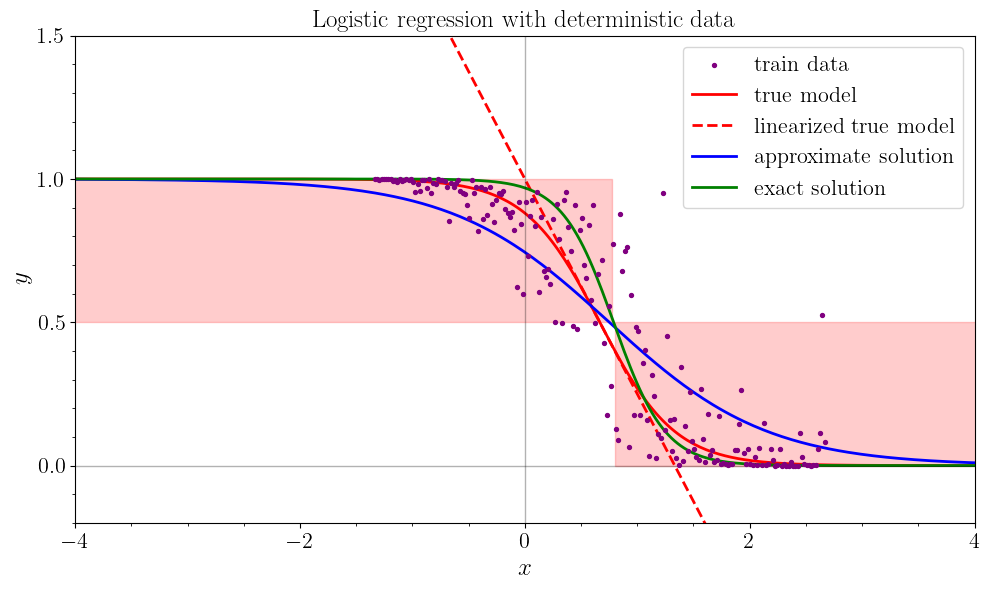

In [188]:
save = True

def H(c: float) -> float:
    """Computes the entropy function H(c).
    
    Parameters
    ----------
    c : float
        Value of c.
    
    Returns
    -------
    float
    
        Entropy value.
    """
    return np.heaviside(c, 0.5)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Generate custom tick marks ---
x_major_ticks = np.arange(-10, 10+1, 2)
x_minor_ticks = np.arange(-10, 10+0.5, 0.5)
y_major_ticks = np.arange(-2, 2+0.5, 0.5)
y_minor_ticks = np.arange(-2, 2+0.1, 0.1)

# --- Define plotting range and decision boundary ---
x_plot = np.linspace(-7, 7, 500)

# --- Create the main plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot training data ---
# Assume x_train and p_train are numpy arrays. For demonstration, we create dummy data:
ax.scatter(x_train, p_train, color='purple', s=8, zorder=5, label=r'$\text{train data}$')

# Plot the various curves with styles similar to your Mathematica code:
ax.plot(x_plot, p(x_plot,omega_true), color='red', linewidth=2, label=r'$\text{true model}$')
ax.plot(x_plot, p_approx(x_plot,omega_true), color='red', linestyle='--', linewidth=2, label=r'$\text{linearized true model}$')
ax.plot(x_plot, p(x_plot, omega_approx), color='blue', linewidth=2, label=r'$\text{approximate solution}$')
ax.plot(x_plot, p(x_plot, omega_exact), color='green', linewidth=2, label=r'$\text{exact solution}$')
# The constant 0.5 curve (with zero opacity) is included for filling purposes:
ax.plot(x_plot, 0.5*np.ones_like(x_plot), color='black', alpha=0, linewidth=2)

# Fill between the constant 0.5 and the Heaviside curve.
# In Mathematica, you filled curve 5 -> 4 and 4 -> 5.
# Here, we assume we want to fill between heaviside(db - x) and 0.5.
# Choose the fill condition appropriately. Here, we fill where heaviside < 0.5.
ax.fill_between(x_plot, H(decision_boundary - x_plot), 0.5, where=(H(decision_boundary - x_plot) < 0.5),
                color='red', alpha=0.2)
ax.fill_between(x_plot, 0.5, H(decision_boundary - x_plot), where=(H(decision_boundary - x_plot) > 0.5),
                color='red', alpha=0.2)

# Draw axes
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Finalizing plot
plt.title(f'Logistic regression with deterministic data', fontsize = 18)
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)
#ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
#ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)
ax.set_xlabel(r'$x$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.legend(loc='upper right', fontsize=16)
ax.set_xlim(-4,4)
ax.set_ylim(-0.2, 1.5)

# --- Adjust aspect ratio and layout ---
plt.tight_layout()

# --- Save and show the figure ---
if save:
    plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution_noise.pdf')
plt.show()

In [189]:
for t in np.arange(0, 1.1, 0.1):
    #ytrue = Y_train#Y_pred(p(x_train, omega_true, noise_std = 1), threshold=0.5)
    ytrue = Y_pred(p(x_train, omega_true), threshold=0.5)
    ypred = Y_pred(p(x_train, omega_approx, noise_std = 0), threshold=t)

    TP = np.sum((ypred == 1) & (ytrue == 1))
    FP = np.sum((ypred == 1) & (ytrue == 0))
    FN = np.sum((ypred == 0) & (ytrue == 1))
    TN = np.sum((ypred == 0) & (ytrue == 0))

    confusion_matrix = np.array([[TP, FP],
                                 [FN, TN]])
    
    if (TP + FN) > 0:
        TPR = TP / (TP + FN)
    else:
        TPR = 0.0  # or np.nan, depending on your preference

    if (FP + TN) > 0:
        FPR = FP / (FP + TN)
    else:
        FPR = 0.0  # or np.nan

    print("\n--------------------")
    print("Threshold:", t)
    print("[FPR,TPR]:", [FPR, TPR])    
    print("Confusion matrix: \n", confusion_matrix)


--------------------
Threshold: 0.0
[FPR,TPR]: [np.float64(1.0), np.float64(1.0)]
Confusion matrix: 
 [[100 100]
 [  0   0]]

--------------------
Threshold: 0.1
[FPR,TPR]: [np.float64(0.81), np.float64(1.0)]
Confusion matrix: 
 [[100  81]
 [  0  19]]

--------------------
Threshold: 0.2
[FPR,TPR]: [np.float64(0.52), np.float64(1.0)]
Confusion matrix: 
 [[100  52]
 [  0  48]]

--------------------
Threshold: 0.30000000000000004
[FPR,TPR]: [np.float64(0.33), np.float64(1.0)]
Confusion matrix: 
 [[100  33]
 [  0  67]]

--------------------
Threshold: 0.4
[FPR,TPR]: [np.float64(0.18), np.float64(1.0)]
Confusion matrix: 
 [[100  18]
 [  0  82]]

--------------------
Threshold: 0.5
[FPR,TPR]: [np.float64(0.04), np.float64(1.0)]
Confusion matrix: 
 [[100   4]
 [  0  96]]

--------------------
Threshold: 0.6000000000000001
[FPR,TPR]: [np.float64(0.0), np.float64(0.9)]
Confusion matrix: 
 [[ 90   0]
 [ 10 100]]

--------------------
Threshold: 0.7000000000000001
[FPR,TPR]: [np.float64(0.0), n

In [190]:
def ROC_curve(x: np.ndarray, 
              omega_solution: np.ndarray,
              p_true: np.ndarray,
             ) -> Tuple[np.ndarray, np.ndarray]:
    """Computes the ROC curve for a given dataset and parameters.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    omega_true : np.ndarray
        True parameters.
    onega_solution : np.ndarray
        Estimated parameters.
    
    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        ROC curve.
    """
    p_solution = p(x, omega_solution)
    
    #thresholds = np.unique(np.concatenate((p_true, p_approx)))
    thresholds = np.linspace(0, 1, 1000)
    spacing = thresholds[1] - thresholds[0]
    TPR = []
    FPR = []
    AUC = 0.0
    
    for i, threshold in enumerate(thresholds):
        y_true = Y_pred(p_true, 0.5)
        y_pred = Y_pred(p_solution, threshold)
        
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        FN = np.sum((y_pred == 0) & (y_true == 1))
        TN = np.sum((y_pred == 0) & (y_true == 0))
        
        if (TP + FN) > 0:
            TPR.append(TP / (TP + FN))
        else:
            TPR.append(0.0)
    
        if (FP + TN) > 0:
            FPR.append(FP / (FP + TN))
        else:
            FPR.append(0.0)

        AUC += TPR[-1] * spacing
        
    return FPR, TPR, AUC

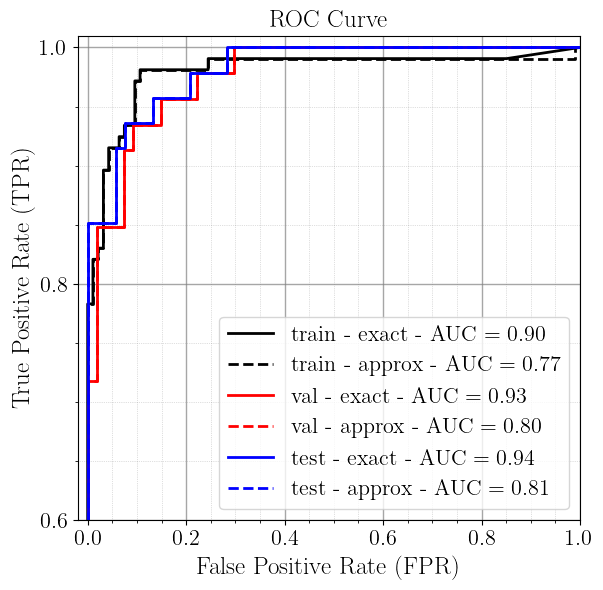

In [191]:
import numpy as np
import matplotlib.pyplot as plt

# Assume ROC_curve returns two numpy arrays: FPR and TPR, both in [0,1].
FPR_train_exact, TPR_train_exact, AUC_train_exact = ROC_curve(x_train, omega_exact, p_train)
FPR_val_exact, TPR_val_exact, AUC_val_exact = ROC_curve(x_val, omega_exact, p_val)
FPR_train_approx, TPR_train_approx, AUC_train_approx = ROC_curve(x_train, omega_approx, p_train)
FPR_val_approx, TPR_val_approx, AUC_val_approx = ROC_curve(x_val, omega_approx, p_val)
FPR_test_exact, TPR_test_exact, AUC_test_exact = ROC_curve(x_test, omega_exact, p_test)
FPR_test_approx, TPR_test_approx, AUC_test_approx = ROC_curve(x_test, omega_approx, p_test)

# --- Define custom tick marks ---
x_major_ticks = np.arange(0, 1.01, 0.2)
x_minor_ticks = np.arange(0, 1.01, 0.05)
y_major_ticks = np.arange(0, 1.01, 0.2)
y_minor_ticks = np.arange(0, 1.01, 0.05)

# Enable LaTeX rendering for text (if a full TeX installation is available)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage{amssymb}'

# --- Create the ROC plot ---
fig, ax = plt.subplots(figsize=(6, 6))  # Square figure for aspect ratio 1

# Plot the ROC curve as a joined red, thick line.
ax.plot(FPR_train_exact, TPR_train_exact, color='black', linewidth=2, label=r'$\text{train - exact - AUC} = %.2f$' % AUC_train_exact)
ax.plot(FPR_train_approx, TPR_train_approx, color='black', linestyle='--', linewidth=2, label=r'$\text{train - approx - AUC} = %.2f$' % AUC_train_approx)
ax.plot(FPR_val_exact, TPR_val_exact, color='red', linewidth=2, label=r'$\text{val - exact - AUC} = %.2f$' % AUC_val_exact)
ax.plot(FPR_val_approx, TPR_val_approx, color='red', linestyle='--', linewidth=2, label=r'$\text{val - approx - AUC} = %.2f$' % AUC_val_approx)
ax.plot(FPR_test_exact, TPR_test_exact, color='blue', linewidth=2, label=r'$\text{test - exact - AUC} = %.2f$' % AUC_test_exact)
ax.plot(FPR_test_approx, TPR_test_approx, color='blue', linestyle='--', linewidth=2, label=r'$\text{test - approx - AUC} = %.2f$' % AUC_test_approx)

# Set title
plt.title(r'$\text{ROC Curve}$', fontsize = 18)

# Set the aspect ratio to 1.
ax.set_aspect('auto')

# Set custom major and minor ticks.
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# Set axis labels in LaTeX.
ax.set_xlabel(r'$\text{False Positive Rate (FPR)}$', fontsize=18)
ax.set_ylabel(r'$\text{True Positive Rate (TPR)}$', fontsize=18)

# Add a legend in the lower right.
ax.legend(loc='lower right', fontsize=16)

# Optionally, add grid lines for better readability.
ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)

plt.tight_layout()

# Set the plot range.
ax.set_xlim(-0.02, 1.)
ax.set_ylim(0.6, 1.01)

# Save the figure as a PDF file.
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution_noise_roc.pdf')

plt.show()

### Deterministic model (cubic data - linear model)

In [2]:
def poly(x: float, omega: np.ndarray) -> float:
    """Evaluates a polynomial with coefficients omega at x.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients of the polynomial.
        
    Returns
    -------
    float
        Polynomial value.
    """
    output = 0.0
    for i, omega_i in enumerate(omega):
        output += omega_i * x**i
    return output

def p(x: float, omega: np.ndarray) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega)
    return 1.0 / (1.0 + np.exp(-poly_val))

def p_approx(x: float, omega: np.ndarray) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega)
    return 1./2 + poly_val/4.

def design_matrix(x: np.ndarray, degree: int) -> np.ndarray:
    """Computes the design matrix for a polynomial of a given degree.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    degree : int
        Degree of the polynomial.
    
    Returns
    -------
    np.ndarray
        Design matrix.
    """
    X = np.zeros((len(x), degree + 1))
    for i in range(degree + 1):
        X[:, i] = x**i
    return X

In [4]:
# Define the true parameters
omega_true = np.array([2, -3, -2, 1])

# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Define the approximate objective: squared difference between y_approx(x,omega_true) and 0.5.
def objective_approx(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p_approx(x_scalar, omega) - 0.5)**2

decision_boundary = []

# Initial guess for x (e.g., 0)
initial_x = np.array([-2.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([2.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

Decision boundary x = [-1.34292303]
Decision boundary (from approx solution) x = -1.342923012576254
Decision boundary x = [0.52931647]
Decision boundary (from approx solution) x = -1.342923012576254
Decision boundary x = [2.8136065]
Decision boundary (from approx solution) x = -1.342923012576254


In [5]:
# Generate data coordinates
x_train = np.sort(np.concatenate(((2/3) - 0.02 * np.arange(1, 101),(2/3) + 0.02 * np.arange(1, 101))))
x_val = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) + 0.03
x_test = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) - 0.03

X_train = design_matrix(x_train, 1)
X_val = design_matrix(x_val, 1)
X_test = design_matrix(x_test, 1)

p_train = p(x_train, omega_true)
p_val = p(x_val, omega_true)
p_test = p(x_test, omega_true)

Y_train = np.array([1 if p_i >= 0.5 else 0 for p_i in p_train])
Y_val = np.array([1 if p_i >= 0.5 else 0 for p_i in p_val])
Y_test = np.array([1 if p_i >= 0.5 else 0 for p_i in p_test])

In [6]:
omega_approx = np.linalg.pinv(X_train.T @ X_train) @ (4 * X_train.T @ Y_train - 2 * X_train.T @ np.ones_like(Y_train))
print("Approximate omega:", omega_approx)

result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary (from approx solution) x =", result_approx.x)

Approximate omega: [ 0.87088715 -1.48633072]
Decision boundary (from approx solution) x = [2.8136065]


In [7]:
def Y_pred(p: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    """Converts probabilities to predictions using a threshold.
    
    Parameters
    ----------
    p : np.ndarray
        Probabilities.
    threshold : float
        Threshold for the conversion.
    
    Returns
    -------
    np.ndarray
        Predictions.
    """
    return np.array([1 if p_i > threshold else 0 for p_i in p])

def loss_fn(X: np.ndarray, 
            p: np.ndarray, 
            omega: np.ndarray,
            threshold: float = 0.5) -> float:
    """Computes the logistic loss for a given dataset and parameters.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega : np.ndarray
        Parameters.
    
    Returns
    -------
    float
        Logistic loss.
    """
    Y = Y_pred(p, threshold)
    res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
    return -1 * res

In [10]:
# Minimize the loss function and extract omega
objective = lambda omega: loss_fn(X_train, p_train, omega)
result = minimize(objective, [0,0], method='BFGS')
omega_exact = result.x
omega_exact

/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_36213/4062348815.py:39: RuntimeWarning: overflow encountered in exp
  res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
/opt/anaconda3/envs/tf_torch_env/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_36213/4062348815.py:39: RuntimeWarning: overflow encountered in exp
  res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_36213/4062348815.py:39: RuntimeWarning: overflow encountered in exp
  res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
/opt/anaconda3/envs/tf_torch_env/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_36213/4062348815.py:39: RuntimeW

array([ 203.19154983, -377.65871201])

In [13]:
loss_fn(X_train, p_train, omega_exact)

In [14]:
train_loss = loss_fn(X_train, Y_train, omega_approx)
val_loss = loss_fn(X_val, Y_val, omega_approx)
test_loss = loss_fn(X_test, Y_test, omega_approx)
print("Train loss:", train_loss)
print("Validation loss:", val_loss)
print("Test loss:", test_loss)

Train loss: 51.41634522501204
Validation loss: 25.46822107857419
Test loss: 28.296583621393026


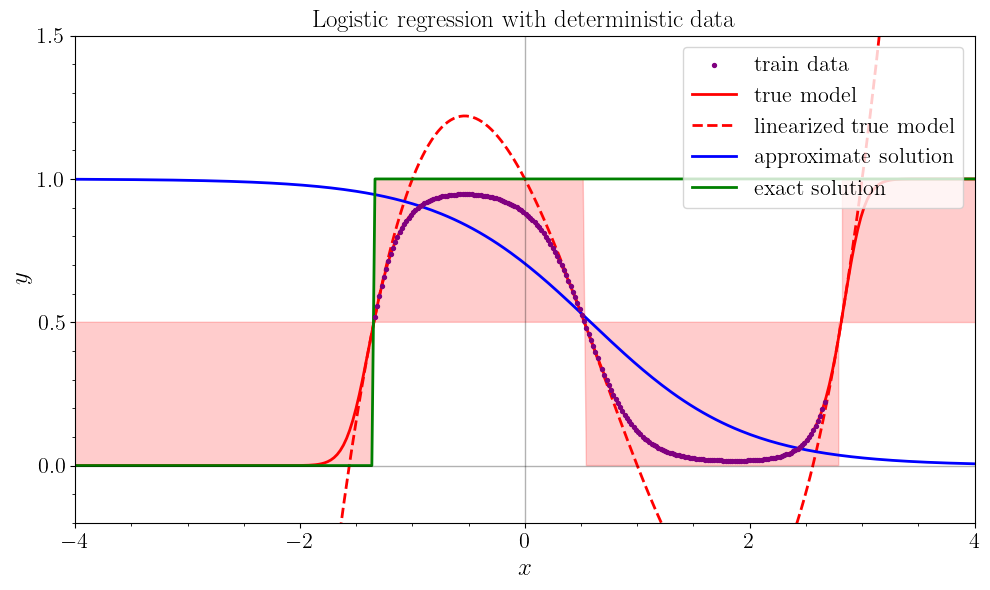

In [15]:
def H(c: float) -> float:
    """Computes the entropy function H(c).
    
    Parameters
    ----------
    c : float
        Value of c.
    
    Returns
    -------
    float
    
        Entropy value.
    """
    return np.heaviside(c, 0.5)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Generate custom tick marks ---
x_major_ticks = np.arange(-10, 10+1, 2)
x_minor_ticks = np.arange(-10, 10+0.5, 0.5)
y_major_ticks = np.arange(-2, 2+0.5, 0.5)
y_minor_ticks = np.arange(-2, 2+0.1, 0.1)

# --- Define plotting range and decision boundary ---
x_plot = np.linspace(-7, 7, 500)

# --- Create the main plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot training data ---
# Assume x_train and p_train are numpy arrays. For demonstration, we create dummy data:
ax.scatter(x_train, p_train, color='purple', s=8, zorder=5, label=r'$\text{train data}$')

# Plot the various curves with styles similar to your Mathematica code:
ax.plot(x_plot, p(x_plot,omega_true), color='red', linewidth=2, label=r'$\text{true model}$')
ax.plot(x_plot, p_approx(x_plot,omega_true), color='red', linestyle='--', linewidth=2, label=r'$\text{linearized true model}$')
ax.plot(x_plot, p(x_plot, omega_approx), color='blue', linewidth=2, label=r'$\text{approximate solution}$')
ax.plot(x_plot, H(x_plot - decision_boundary[0]), color='green', linewidth=2, label=r'$\text{exact solution}$')
# The constant 0.5 curve (with zero opacity) is included for filling purposes:
ax.plot(x_plot, 0.5*np.ones_like(x_plot), color='black', alpha=0, linewidth=2)

# Fill between the constant 0.5 and the Heaviside curve.
# In Mathematica, you filled curve 5 -> 4 and 4 -> 5.
# Here, we assume we want to fill between heaviside(db - x) and 0.5.
# Choose the fill condition appropriately. Here, we fill where heaviside < 0.5.
#ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[0]), where=(H(decision_boundary[0] - x_plot) > 0.5),
#                color='red', alpha=0.2)
ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[0]) - H(x_plot - decision_boundary[1]) + H(x_plot - decision_boundary[2]), where=(H(decision_boundary[2] - x_plot) > 0.5),
                color='red', alpha=0.2)
ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[2]), where=(H(decision_boundary[2] - x_plot) < 0.5),
                color='red', alpha=0.2)


# Draw axes
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Finalizing plot
plt.title(f'Logistic regression with deterministic data', fontsize = 18)
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)
#ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
#ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)
ax.set_xlabel(r'$x$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.legend(loc='upper right', fontsize=16)
ax.set_xlim(-4,4)
ax.set_ylim(-0.2, 1.5)

# --- Adjust aspect ratio and layout ---
plt.tight_layout()

plt.show()

In [16]:
Y_pred(p_train, threshold=0.5)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [17]:
ytrue = Y_pred(p(x_train, omega_true), threshold=0.5)
ypred = Y_pred(p(x_train, omega_approx), threshold=0.5)

TP = np.sum((ypred == 1) & (ytrue == 1))
FP = np.sum((ypred == 1) & (ytrue == 0))
FN = np.sum((ypred == 0) & (ytrue == 1))
TN = np.sum((ypred == 0) & (ytrue == 0))

confusion_matrix = np.array([[TP, FP],
                             [FN, TN]])

print(confusion_matrix)

[[ 94   2]
 [  0 104]]


In [18]:
def ROC_curve(x: np.ndarray, 
              omega_solution: np.ndarray,
              p_true: np.ndarray,
             ) -> Tuple[np.ndarray, np.ndarray]:
    """Computes the ROC curve for a given dataset and parameters.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    omega_true : np.ndarray
        True parameters.
    onega_solution : np.ndarray
        Estimated parameters.
    
    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        ROC curve.
    """
    p_solution = p(x, omega_solution)
    
    #thresholds = np.unique(np.concatenate((p_true, p_approx)))
    thresholds = np.linspace(0, 1, 1000)
    spacing = thresholds[1] - thresholds[0]
    TPR = []
    FPR = []
    AUC = 0.0
    
    for i, threshold in enumerate(thresholds):
        y_true = Y_pred(p_true, 0.5)
        y_pred = Y_pred(p_solution, threshold)
        
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        FN = np.sum((y_pred == 0) & (y_true == 1))
        TN = np.sum((y_pred == 0) & (y_true == 0))
        
        if (TP + FN) > 0:
            TPR.append(TP / (TP + FN))
        else:
            TPR.append(0.0)
    
        if (FP + TN) > 0:
            FPR.append(FP / (FP + TN))
        else:
            FPR.append(0.0)

        AUC += TPR[-1] * spacing
        
    return FPR, TPR, AUC

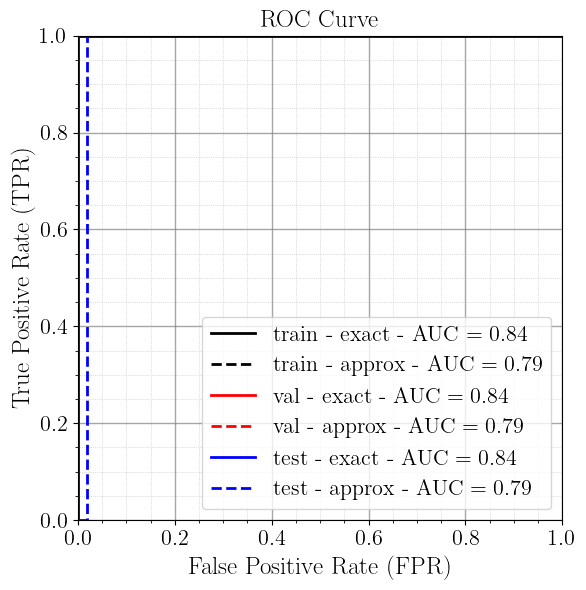

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Assume ROC_curve returns two numpy arrays: FPR and TPR, both in [0,1].
FPR_train_exact, TPR_train_exact, AUC_train_exact = ROC_curve(x_train, omega_true, p_train)
FPR_train_approx, TPR_train_approx, AUC_train_approx = ROC_curve(x_train, omega_approx, p_train)
FPR_val_exact, TPR_val_exact, AUC_val_exact = ROC_curve(x_val, omega_true, p_val)
FPR_val_approx, TPR_val_approx, AUC_val_approx = ROC_curve(x_val, omega_approx, p_val)
FPR_test_exact, TPR_test_exact, AUC_test_exact = ROC_curve(x_test, omega_true, p_test)
FPR_test_approx, TPR_test_approx, AUC_test_approx = ROC_curve(x_test, omega_approx, p_test)

# --- Define custom tick marks ---
x_major_ticks = np.arange(0, 1.01, 0.2)
x_minor_ticks = np.arange(0, 1.01, 0.05)
y_major_ticks = np.arange(0, 1.01, 0.2)
y_minor_ticks = np.arange(0, 1.01, 0.05)

# Enable LaTeX rendering for text (if a full TeX installation is available)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage{amssymb}'

# --- Create the ROC plot ---
fig, ax = plt.subplots(figsize=(6, 6))  # Square figure for aspect ratio 1

# Plot the ROC curve as a joined red, thick line.
ax.plot(FPR_train_exact, TPR_train_exact, color='black', linewidth=2, label=r'$\text{train - exact - AUC} = %.2f$' % AUC_train_exact)
ax.plot(FPR_train_approx, TPR_train_approx, color='black', linestyle='--', linewidth=2, label=r'$\text{train - approx - AUC} = %.2f$' % AUC_train_approx)
ax.plot(FPR_val_exact, TPR_val_exact, color='red', linewidth=2, label=r'$\text{val - exact - AUC} = %.2f$' % AUC_val_exact)
ax.plot(FPR_val_approx, TPR_val_approx, color='red', linestyle='--', linewidth=2, label=r'$\text{val - approx - AUC} = %.2f$' % AUC_val_approx)
ax.plot(FPR_test_exact, TPR_test_exact, color='blue', linewidth=2, label=r'$\text{test - exact - AUC} = %.2f$' % AUC_test_exact)
ax.plot(FPR_test_approx, TPR_test_approx, color='blue', linestyle='--', linewidth=2, label=r'$\text{test - approx - AUC} = %.2f$' % AUC_test_approx)

# Set title
plt.title(r'$\text{ROC Curve}$', fontsize = 18)

# Set the plot range.
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Set the aspect ratio to 1.
ax.set_aspect('equal')

# Set custom major and minor ticks.
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# Set axis labels in LaTeX.
ax.set_xlabel(r'$\text{False Positive Rate (FPR)}$', fontsize=18)
ax.set_ylabel(r'$\text{True Positive Rate (TPR)}$', fontsize=18)

# Add a legend in the lower right.
ax.legend(loc='lower right', fontsize=16)

# Optionally, add grid lines for better readability.
ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)

plt.tight_layout()

plt.show()

### Probabilistic model (cubic data - linear model)

In [20]:
def poly(x: np.ndarray, 
         omega: np.ndarray, 
         noise_std: float = 0.
        ) -> np.ndarray:
    """
    Evaluates a polynomial with coefficients omega at x, adding independent Gaussian noise 
    to each coefficient for each data point.
    
    Parameters
    ----------
    x : np.ndarray
        Input values. Can be a scalar or a 1D numpy array.
    omega : np.ndarray
        Coefficients of the polynomial.
    noise_std : float, optional
        Standard deviation of the Gaussian noise added to each coefficient, by default 1.
        
    Returns
    -------
    np.ndarray or float
        The output of the polynomial function evaluated at each x, with independent noise for each data point.
    """
    np.random.seed(0)
    # Ensure x is an array.
    x = np.atleast_1d(x)
    # Number of coefficients.
    k = len(omega)
    # For each coefficient, compute the corresponding powers of x: this creates a (k, len(x)) array.
    powers = np.array([x**i for i in range(k)])
    # Generate independent noise for each coefficient and each data point.
    noise = np.random.normal(0, noise_std, size=powers.shape)
    # Add noise to the coefficients and multiply elementwise by the power of x.
    effective_terms = (omega.reshape(-1, 1) + noise) * powers
    # Sum over the coefficients (axis 0) to get the final result.
    result = effective_terms.sum(axis=0)
    # If x was originally a scalar, return a scalar.
    if result.size == 1:
        return result.item()
    return result

def p(x: float, 
      omega: np.ndarray,
      noise_std: float = 0.
      ) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega, noise_std)
    return 1.0 / (1.0 + np.exp(-poly_val))

def p_approx(x: float, 
             omega: np.ndarray,
             noise_std: float = 0.
             ) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega, noise_std)
    return 1./2 + poly_val/4.

def design_matrix(x: np.ndarray, degree: int) -> np.ndarray:
    """Computes the design matrix for a polynomial of a given degree.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    degree : int
        Degree of the polynomial.
    
    Returns
    -------
    np.ndarray
        Design matrix.
    """
    X = np.zeros((len(x), degree + 1))
    for i in range(degree + 1):
        X[:, i] = x**i
    return X

In [21]:
# Define the true parameters
omega_true = np.array([2, -3, -2, 1])

# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Define the approximate objective: squared difference between y_approx(x,omega_true) and 0.5.
def objective_approx(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p_approx(x_scalar, omega) - 0.5)**2

decision_boundary = []

# Initial guess for x (e.g., 0)
initial_x = np.array([-2.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([2.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

Decision boundary x = [-1.34292303]
Decision boundary (from approx solution) x = -1.342923012576254
Decision boundary x = [0.52931647]
Decision boundary (from approx solution) x = -1.342923012576254
Decision boundary x = [2.8136065]
Decision boundary (from approx solution) x = -1.342923012576254


In [22]:
# Generate data coordinates
x_train = np.sort(np.concatenate(((2/3) - 0.02 * np.arange(1, 101),(2/3) + 0.02 * np.arange(1, 101))))
x_val = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) + 0.03
x_test = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) - 0.03

X_train = design_matrix(x_train, 1)
X_val = design_matrix(x_val, 1)
X_test = design_matrix(x_test, 1)

p_train = p(x_train, omega_true, noise_std = 0.5)
p_val = p(x_val, omega_true, noise_std = 0.5)
p_test = p(x_test, omega_true, noise_std = 0.5)

Y_train = np.array([1 if p_i >= 0.5 else 0 for p_i in p_train])
Y_val = np.array([1 if p_i >= 0.5 else 0 for p_i in p_val])
Y_test = np.array([1 if p_i >= 0.5 else 0 for p_i in p_test])

print("Train data for class 1:", np.count_nonzero(Y_train), "out of", len(Y_train))
print("Validation data for class 1:", np.count_nonzero(Y_val), "out of", len(Y_val))
print("Test data for class 1:", np.count_nonzero(Y_test), "out of", len(Y_test))

Train data for class 1: 102 out of 200
Validation data for class 1: 52 out of 100
Test data for class 1: 54 out of 100


In [23]:
omega_approx = np.linalg.pinv(X_train.T @ X_train) @ (4 * X_train.T @ Y_train - 2 * X_train.T @ np.ones_like(Y_train))
print("Approximate omega:", omega_approx)

result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary (from approx solution) x =", result_approx.x[0])

Approximate omega: [ 0.94281267 -1.354219  ]
Decision boundary (from approx solution) x = 2.8136064975014605


In [26]:
def Y_pred(p: np.ndarray, 
           threshold: float = 0.5
          ) -> np.ndarray:
    """Converts probabilities to predictions using a threshold.
    
    Parameters
    ----------
    p : np.ndarray
        Probabilities.
    threshold : float
        Threshold for the conversion.
    
    Returns
    -------
    np.ndarray
        Predictions.
    """
    return (p >= threshold).astype(int)#np.array([1 if p_i > threshold else 0 for p_i in p])

def loss_fn(X: np.ndarray, 
            p: np.ndarray, 
            omega: np.ndarray,
            threshold: float = 0.5
           ) -> float:
    """Computes the logistic loss for a given dataset and parameters.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega : np.ndarray
        Parameters.
    
    Returns
    -------
    float
        Logistic loss.
    """
    Y = Y_pred(p, threshold)
    res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
    return -1 * res

In [27]:
# Minimize the loss function and extract omega
objective = lambda omega: loss_fn(X_train, p_train, omega)
result = minimize(objective, [0,0], method='BFGS')
omega_exact = result.x
print("Exact omega:", omega_exact)

Exact omega: [ 2.07730176 -2.93616357]


In [30]:
# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective_exact(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Initial guess for x (e.g., 0)
initial_x = np.array([-2.0])
result = minimize(objective_exact, initial_x, args=(omega_approx,), method='BFGS')
result_approx = minimize(objective_exact, initial_x, args=(omega_exact,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])
result = minimize(objective_exact, initial_x, args=(omega_approx,), method='BFGS')
result_approx = minimize(objective_exact, initial_x, args=(omega_exact,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([2.0])
result = minimize(objective_exact, initial_x, args=(omega_approx,), method='BFGS')
result_approx = minimize(objective_exact, initial_x, args=(omega_exact,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])

Decision boundary x = [0.69620385]
Decision boundary (from approx solution) x = 0.70748742931133
Decision boundary x = [0.69620409]
Decision boundary (from approx solution) x = 0.7074889425912964
Decision boundary x = [0.69620265]
Decision boundary (from approx solution) x = 0.7074914828904655


In [31]:
print("Approximate omega:", omega_approx)
print("Approximate decision boundary x =", result_approx.x[0])
print("Train loss - approximate omega:", loss_fn(X_train, p_train, omega_approx))
print("Validation loss - approximate omega:", loss_fn(X_val, p_val, omega_approx))
print("Test loss - approximate omega:", loss_fn(X_test, p_test, omega_approx))
print("\nExact omega:", omega_exact)
print("Exact decision boundary x =", result.x[0])
print("Train loss - exact omega:", loss_fn(X_train, p_train, omega_exact))
print("Validation loss - exact omega:", loss_fn(X_val, p_val, omega_exact))
print("Test loss - exact omega:", loss_fn(X_test, p_test, omega_exact))

Approximate omega: [ 0.94281267 -1.354219  ]
Approximate decision boundary x = 0.7074914828904655
Train loss - approximate omega: 67.8868702419621
Validation loss - approximate omega: 53.48625730320466
Test loss - approximate omega: 52.51018001815696

Exact omega: [ 2.07730176 -2.93616357]
Exact decision boundary x = 0.6962026501379439
Train loss - exact omega: 54.59293382299046
Validation loss - exact omega: 69.94456351032728
Test loss - exact omega: 67.8230947793124


In [32]:
train_loss = loss_fn(X_train, Y_train, omega_approx)
val_loss = loss_fn(X_val, Y_val, omega_approx)
test_loss = loss_fn(X_test, Y_test, omega_approx)
print("Train loss:", train_loss)
print("Validation loss:", val_loss)
print("Test loss:", test_loss)

Train loss: 67.8868702419621
Validation loss: 53.48625730320466
Test loss: 52.51018001815696


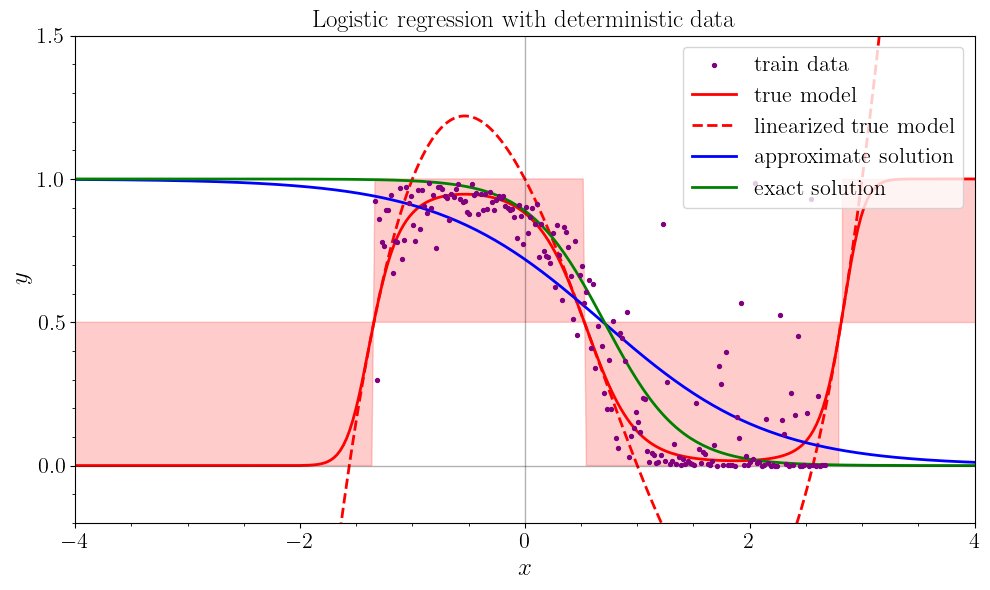

In [33]:
save = True

def H(c: float) -> float:
    """Computes the entropy function H(c).
    
    Parameters
    ----------
    c : float
        Value of c.
    
    Returns
    -------
    float
    
        Entropy value.
    """
    return np.heaviside(c, 0.5)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Generate custom tick marks ---
x_major_ticks = np.arange(-10, 10+1, 2)
x_minor_ticks = np.arange(-10, 10+0.5, 0.5)
y_major_ticks = np.arange(-2, 2+0.5, 0.5)
y_minor_ticks = np.arange(-2, 2+0.1, 0.1)

# --- Define plotting range and decision boundary ---
x_plot = np.linspace(-7, 7, 500)

# --- Create the main plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot training data ---
# Assume x_train and p_train are numpy arrays. For demonstration, we create dummy data:
ax.scatter(x_train, p_train, color='purple', s=8, zorder=5, label=r'$\text{train data}$')

# Plot the various curves with styles similar to your Mathematica code:
ax.plot(x_plot, p(x_plot,omega_true), color='red', linewidth=2, label=r'$\text{true model}$')
ax.plot(x_plot, p_approx(x_plot,omega_true), color='red', linestyle='--', linewidth=2, label=r'$\text{linearized true model}$')
ax.plot(x_plot, p(x_plot, omega_approx), color='blue', linewidth=2, label=r'$\text{approximate solution}$')
ax.plot(x_plot, p(x_plot, omega_exact), color='green', linewidth=2, label=r'$\text{exact solution}$')
# The constant 0.5 curve (with zero opacity) is included for filling purposes:
ax.plot(x_plot, 0.5*np.ones_like(x_plot), color='black', alpha=0, linewidth=2)

# Fill between the constant 0.5 and the Heaviside curve.
# In Mathematica, you filled curve 5 -> 4 and 4 -> 5.
# Here, we assume we want to fill between heaviside(db - x) and 0.5.
# Choose the fill condition appropriately. Here, we fill where heaviside < 0.5.
ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[0]) - H(x_plot - decision_boundary[1]) + H(x_plot - decision_boundary[2]), where=(H(decision_boundary[2] - x_plot) > 0.5),
                color='red', alpha=0.2)
ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[2]), where=(H(decision_boundary[2] - x_plot) < 0.5),
                color='red', alpha=0.2)

# Draw axes
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Finalizing plot
plt.title(f'Logistic regression with deterministic data', fontsize = 18)
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)
#ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
#ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)
ax.set_xlabel(r'$x$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.legend(loc='upper right', fontsize=16)
ax.set_xlim(-4,4)
ax.set_ylim(-0.2, 1.5)

# --- Adjust aspect ratio and layout ---
plt.tight_layout()

# --- Save and show the figure ---
if save:
    plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution_cubic.pdf')
plt.show()

In [34]:
for t in np.arange(0, 1.1, 0.1):
    #ytrue = Y_train#Y_pred(p(x_train, omega_true, noise_std = 1), threshold=0.5)
    ytrue = Y_pred(p(x_train, omega_true), threshold=0.5)
    ypred = Y_pred(p(x_train, omega_approx, noise_std = 0), threshold=t)

    TP = np.sum((ypred == 1) & (ytrue == 1))
    FP = np.sum((ypred == 1) & (ytrue == 0))
    FN = np.sum((ypred == 0) & (ytrue == 1))
    TN = np.sum((ypred == 0) & (ytrue == 0))

    confusion_matrix = np.array([[TP, FP],
                                 [FN, TN]])
    
    if (TP + FN) > 0:
        TPR = TP / (TP + FN)
    else:
        TPR = 0.0  # or np.nan, depending on your preference

    if (FP + TN) > 0:
        FPR = FP / (FP + TN)
    else:
        FPR = 0.0  # or np.nan

    print("\n--------------------")
    print("Threshold:", t)
    print("[FPR,TPR]:", [FPR, TPR])    
    print("Confusion matrix: \n", confusion_matrix)


--------------------
Threshold: 0.0
[FPR,TPR]: [np.float64(1.0), np.float64(1.0)]
Confusion matrix: 
 [[ 94 106]
 [  0   0]]

--------------------
Threshold: 0.1
[FPR,TPR]: [np.float64(0.8301886792452831), np.float64(1.0)]
Confusion matrix: 
 [[94 88]
 [ 0 18]]

--------------------
Threshold: 0.2
[FPR,TPR]: [np.float64(0.5471698113207547), np.float64(1.0)]
Confusion matrix: 
 [[94 58]
 [ 0 48]]

--------------------
Threshold: 0.30000000000000004
[FPR,TPR]: [np.float64(0.3584905660377358), np.float64(1.0)]
Confusion matrix: 
 [[94 38]
 [ 0 68]]

--------------------
Threshold: 0.4
[FPR,TPR]: [np.float64(0.20754716981132076), np.float64(1.0)]
Confusion matrix: 
 [[94 22]
 [ 0 84]]

--------------------
Threshold: 0.5
[FPR,TPR]: [np.float64(0.0660377358490566), np.float64(1.0)]
Confusion matrix: 
 [[94  7]
 [ 0 99]]

--------------------
Threshold: 0.6000000000000001
[FPR,TPR]: [np.float64(0.0), np.float64(0.925531914893617)]
Confusion matrix: 
 [[ 87   0]
 [  7 106]]

----------------

In [35]:
def ROC_curve(x: np.ndarray, 
              omega_solution: np.ndarray,
              p_true: np.ndarray,
             ) -> Tuple[np.ndarray, np.ndarray]:
    """Computes the ROC curve for a given dataset and parameters.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    omega_true : np.ndarray
        True parameters.
    onega_solution : np.ndarray
        Estimated parameters.
    
    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        ROC curve.
    """
    p_solution = p(x, omega_solution)
    
    #thresholds = np.unique(np.concatenate((p_true, p_approx)))
    thresholds = np.linspace(0, 1, 1000)
    spacing = thresholds[1] - thresholds[0]
    TPR = []
    FPR = []
    AUC = 0.0
    
    for i, threshold in enumerate(thresholds):
        y_true = Y_pred(p_true, 0.5)
        y_pred = Y_pred(p_solution, threshold)
        
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        FN = np.sum((y_pred == 0) & (y_true == 1))
        TN = np.sum((y_pred == 0) & (y_true == 0))
        
        if (TP + FN) > 0:
            TPR.append(TP / (TP + FN))
        else:
            TPR.append(0.0)
    
        if (FP + TN) > 0:
            FPR.append(FP / (FP + TN))
        else:
            FPR.append(0.0)

        AUC += TPR[-1] * spacing
        
    return FPR, TPR, AUC

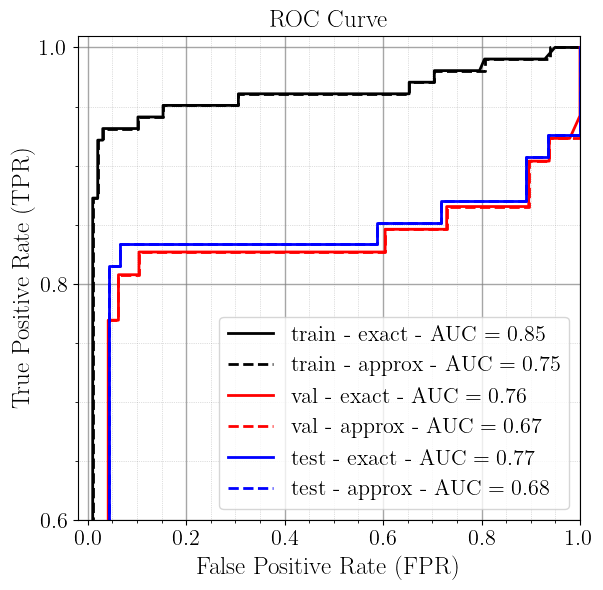

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Assume ROC_curve returns two numpy arrays: FPR and TPR, both in [0,1].
FPR_train_exact, TPR_train_exact, AUC_train_exact = ROC_curve(x_train, omega_exact, p_train)
FPR_val_exact, TPR_val_exact, AUC_val_exact = ROC_curve(x_val, omega_exact, p_val)
FPR_train_approx, TPR_train_approx, AUC_train_approx = ROC_curve(x_train, omega_approx, p_train)
FPR_val_approx, TPR_val_approx, AUC_val_approx = ROC_curve(x_val, omega_approx, p_val)
FPR_test_exact, TPR_test_exact, AUC_test_exact = ROC_curve(x_test, omega_exact, p_test)
FPR_test_approx, TPR_test_approx, AUC_test_approx = ROC_curve(x_test, omega_approx, p_test)

# --- Define custom tick marks ---
x_major_ticks = np.arange(0, 1.01, 0.2)
x_minor_ticks = np.arange(0, 1.01, 0.05)
y_major_ticks = np.arange(0, 1.01, 0.2)
y_minor_ticks = np.arange(0, 1.01, 0.05)

# Enable LaTeX rendering for text (if a full TeX installation is available)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage{amssymb}'

# --- Create the ROC plot ---
fig, ax = plt.subplots(figsize=(6, 6))  # Square figure for aspect ratio 1

# Plot the ROC curve as a joined red, thick line.
ax.plot(FPR_train_exact, TPR_train_exact, color='black', linewidth=2, label=r'$\text{train - exact - AUC} = %.2f$' % AUC_train_exact)
ax.plot(FPR_train_approx, TPR_train_approx, color='black', linestyle='--', linewidth=2, label=r'$\text{train - approx - AUC} = %.2f$' % AUC_train_approx)
ax.plot(FPR_val_exact, TPR_val_exact, color='red', linewidth=2, label=r'$\text{val - exact - AUC} = %.2f$' % AUC_val_exact)
ax.plot(FPR_val_approx, TPR_val_approx, color='red', linestyle='--', linewidth=2, label=r'$\text{val - approx - AUC} = %.2f$' % AUC_val_approx)
ax.plot(FPR_test_exact, TPR_test_exact, color='blue', linewidth=2, label=r'$\text{test - exact - AUC} = %.2f$' % AUC_test_exact)
ax.plot(FPR_test_approx, TPR_test_approx, color='blue', linestyle='--', linewidth=2, label=r'$\text{test - approx - AUC} = %.2f$' % AUC_test_approx)

# Set title
plt.title(r'$\text{ROC Curve}$', fontsize = 18)

# Set the aspect ratio to 1.
ax.set_aspect('auto')

# Set custom major and minor ticks.
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# Set axis labels in LaTeX.
ax.set_xlabel(r'$\text{False Positive Rate (FPR)}$', fontsize=18)
ax.set_ylabel(r'$\text{True Positive Rate (TPR)}$', fontsize=18)

# Add a legend in the lower right.
ax.legend(loc='lower right', fontsize=16)

# Optionally, add grid lines for better readability.
ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)

plt.tight_layout()

# Set the plot range.
ax.set_xlim(-0.02, 1.)
ax.set_ylim(0.6, 1.01)

# Save the figure as a PDF file.
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution_cubic_roc.pdf')

plt.show()

### Deterministic model (cubic data - cubic model)

In [37]:
def poly(x: float, omega: np.ndarray) -> float:
    """Evaluates a polynomial with coefficients omega at x.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients of the polynomial.
        
    Returns
    -------
    float
        Polynomial value.
    """
    output = 0.0
    for i, omega_i in enumerate(omega):
        output += omega_i * x**i
    return output

def p(x: float, omega: np.ndarray) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega)
    return 1.0 / (1.0 + np.exp(-poly_val))

def p_approx(x: float, omega: np.ndarray) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega)
    return 1./2 + poly_val/4.

def design_matrix(x: np.ndarray, degree: int) -> np.ndarray:
    """Computes the design matrix for a polynomial of a given degree.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    degree : int
        Degree of the polynomial.
    
    Returns
    -------
    np.ndarray
        Design matrix.
    """
    X = np.zeros((len(x), degree + 1))
    for i in range(degree + 1):
        X[:, i] = x**i
    return X

In [39]:
# Define the true parameters
omega_true = np.array([2, -3, -2, 1])

# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Define the approximate objective: squared difference between y_approx(x,omega_true) and 0.5.
def objective_approx(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p_approx(x_scalar, omega) - 0.5)**2

decision_boundary = []

# Initial guess for x (e.g., 0)
initial_x = np.array([-2.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([2.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

Decision boundary x = [-1.34292303]
Decision boundary (from approx solution) x = -1.342923012576254
Decision boundary x = [0.52931647]
Decision boundary (from approx solution) x = -1.342923012576254
Decision boundary x = [2.8136065]
Decision boundary (from approx solution) x = -1.342923012576254


In [40]:
# Generate data coordinates
x_train = np.sort(np.concatenate(((2/3) - 0.02 * np.arange(1, 101),(2/3) + 0.02 * np.arange(1, 101))))
x_val = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) + 0.03
x_test = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) - 0.03

X_train = design_matrix(x_train, 3)
X_val = design_matrix(x_val, 3)
X_test = design_matrix(x_test, 3)

p_train = p(x_train, omega_true)
p_val = p(x_val, omega_true)
p_test = p(x_test, omega_true)

Y_train = np.array([1 if p_i >= 0.5 else 0 for p_i in p_train])
Y_val = np.array([1 if p_i >= 0.5 else 0 for p_i in p_val])
Y_test = np.array([1 if p_i >= 0.5 else 0 for p_i in p_test])

In [41]:
omega_approx = np.linalg.pinv(X_train.T @ X_train) @ (4 * X_train.T @ Y_train - 2 * X_train.T @ np.ones_like(Y_train))
print("Approximate omega:", omega_approx)

result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary (from approx solution) x =", result_approx.x)

Approximate omega: [ 1.4628086  -2.20812321 -0.93922233  0.52540746]
Decision boundary (from approx solution) x = [2.8136065]


In [42]:
def Y_pred(p: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    """Converts probabilities to predictions using a threshold.
    
    Parameters
    ----------
    p : np.ndarray
        Probabilities.
    threshold : float
        Threshold for the conversion.
    
    Returns
    -------
    np.ndarray
        Predictions.
    """
    return np.array([1 if p_i > threshold else 0 for p_i in p])

def loss_fn(X: np.ndarray, 
            p: np.ndarray, 
            omega: np.ndarray,
            threshold: float = 0.5) -> float:
    """Computes the logistic loss for a given dataset and parameters.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega : np.ndarray
        Parameters.
    
    Returns
    -------
    float
        Logistic loss.
    """
    Y = Y_pred(p, threshold)
    res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
    return -1 * res

In [43]:
# Minimize the loss function and extract omega
objective = lambda omega: loss_fn(X_train, p_train, omega)
result = minimize(objective, omega_true, method='BFGS')
omega_exact = result.x
omega_exact

array([ 333.49378214, -496.61069327, -315.20960288,  169.38682688])

In [44]:
loss_fn(X_train, p_train, omega_true)

In [45]:
loss_fn(X_train, p_train, omega_exact)

In [46]:
train_loss = loss_fn(X_train, Y_train, omega_approx)
val_loss = loss_fn(X_val, Y_val, omega_approx)
test_loss = loss_fn(X_test, Y_test, omega_approx)
print("Train loss:", train_loss)
print("Validation loss:", val_loss)
print("Test loss:", test_loss)

Train loss: 40.04970022341419
Validation loss: 20.035929034398833
Test loss: 21.17810502715969


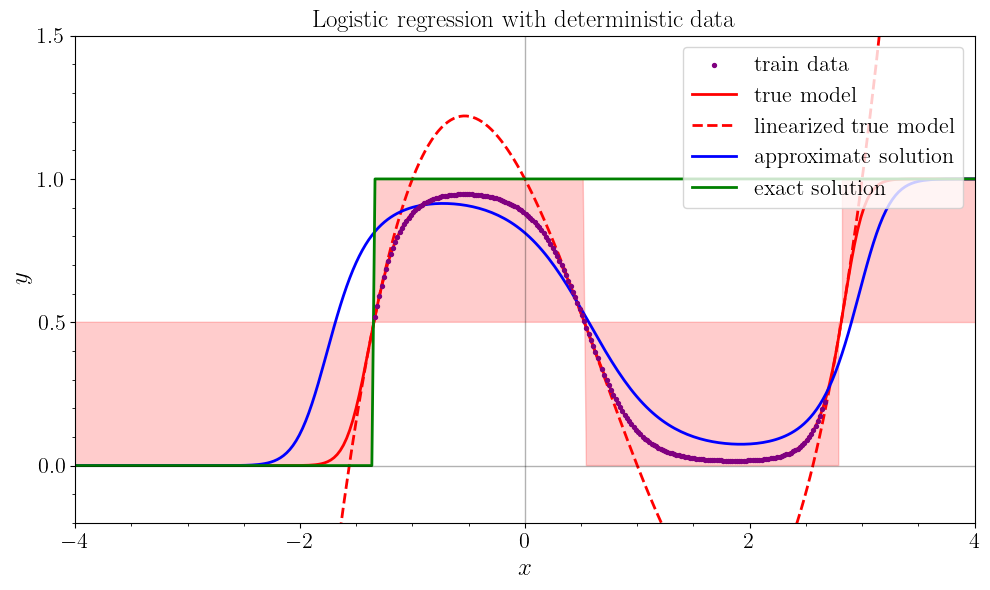

In [ ]:
def H(c: float) -> float:
    """Computes the entropy function H(c).
    
    Parameters
    ----------
    c : float
        Value of c.
    
    Returns
    -------
    float
    
        Entropy value.
    """
    return np.heaviside(c, 0.5)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Generate custom tick marks ---
x_major_ticks = np.arange(-10, 10+1, 2)
x_minor_ticks = np.arange(-10, 10+0.5, 0.5)
y_major_ticks = np.arange(-2, 2+0.5, 0.5)
y_minor_ticks = np.arange(-2, 2+0.1, 0.1)

# --- Define plotting range and decision boundary ---
x_plot = np.linspace(-7, 7, 500)

# --- Create the main plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot training data ---
# Assume x_train and p_train are numpy arrays. For demonstration, we create dummy data:
ax.scatter(x_train, p_train, color='purple', s=8, zorder=5, label=r'$\text{train data}$')

# Plot the various curves with styles similar to your Mathematica code:
ax.plot(x_plot, p(x_plot,omega_true), color='red', linewidth=2, label=r'$\text{true model}$')
ax.plot(x_plot, p_approx(x_plot,omega_true), color='red', linestyle='--', linewidth=2, label=r'$\text{linearized true model}$')
ax.plot(x_plot, p(x_plot, omega_approx), color='blue', linewidth=2, label=r'$\text{approximate solution}$')
ax.plot(x_plot, H(x_plot - decision_boundary[0]), color='green', linewidth=2, label=r'$\text{exact solution}$')
# The constant 0.5 curve (with zero opacity) is included for filling purposes:
ax.plot(x_plot, 0.5*np.ones_like(x_plot), color='black', alpha=0, linewidth=2)

# Fill between the constant 0.5 and the Heaviside curve.
# In Mathematica, you filled curve 5 -> 4 and 4 -> 5.
# Here, we assume we want to fill between heaviside(db - x) and 0.5.
# Choose the fill condition appropriately. Here, we fill where heaviside < 0.5.
#ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[0]), where=(H(decision_boundary[0] - x_plot) > 0.5),
#                color='red', alpha=0.2)
ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[0]) - H(x_plot - decision_boundary[1]) + H(x_plot - decision_boundary[2]), where=(H(decision_boundary[2] - x_plot) > 0.5),
                color='red', alpha=0.2)
ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[2]), where=(H(decision_boundary[2] - x_plot) < 0.5),
                color='red', alpha=0.2)


# Draw axes
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Finalizing plot
plt.title(f'Logistic regression with deterministic data', fontsize = 18)
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)
#ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
#ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)
ax.set_xlabel(r'$x$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.legend(loc='upper right', fontsize=16)
ax.set_xlim(-4,4)
ax.set_ylim(-0.2, 1.5)

# --- Adjust aspect ratio and layout ---
plt.tight_layout()

plt.show()

In [ ]:
Y_pred(p_train, threshold=0.5)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [ ]:
ytrue = Y_pred(p(x_train, omega_true), threshold=0.5)
ypred = Y_pred(p(x_train, omega_approx), threshold=0.5)

TP = np.sum((ypred == 1) & (ytrue == 1))
FP = np.sum((ypred == 1) & (ytrue == 0))
FN = np.sum((ypred == 0) & (ytrue == 1))
TN = np.sum((ypred == 0) & (ytrue == 0))

confusion_matrix = np.array([[TP, FP],
                             [FN, TN]])

print(confusion_matrix)

[[100   0]
 [  0 100]]


In [ ]:
def ROC_curve(x: np.ndarray, 
              omega_solution: np.ndarray,
              p_true: np.ndarray,
             ) -> Tuple[np.ndarray, np.ndarray]:
    """Computes the ROC curve for a given dataset and parameters.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    omega_true : np.ndarray
        True parameters.
    onega_solution : np.ndarray
        Estimated parameters.
    
    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        ROC curve.
    """
    p_solution = p(x, omega_solution)
    
    #thresholds = np.unique(np.concatenate((p_true, p_approx)))
    thresholds = np.linspace(0, 1, 1000)
    spacing = thresholds[1] - thresholds[0]
    TPR = []
    FPR = []
    AUC = 0.0
    
    for i, threshold in enumerate(thresholds):
        y_true = Y_pred(p_true, 0.5)
        y_pred = Y_pred(p_solution, threshold)
        
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        FN = np.sum((y_pred == 0) & (y_true == 1))
        TN = np.sum((y_pred == 0) & (y_true == 0))
        
        if (TP + FN) > 0:
            TPR.append(TP / (TP + FN))
        else:
            TPR.append(0.0)
    
        if (FP + TN) > 0:
            FPR.append(FP / (FP + TN))
        else:
            FPR.append(0.0)

        AUC += TPR[-1] * spacing
        
    return FPR, TPR, AUC

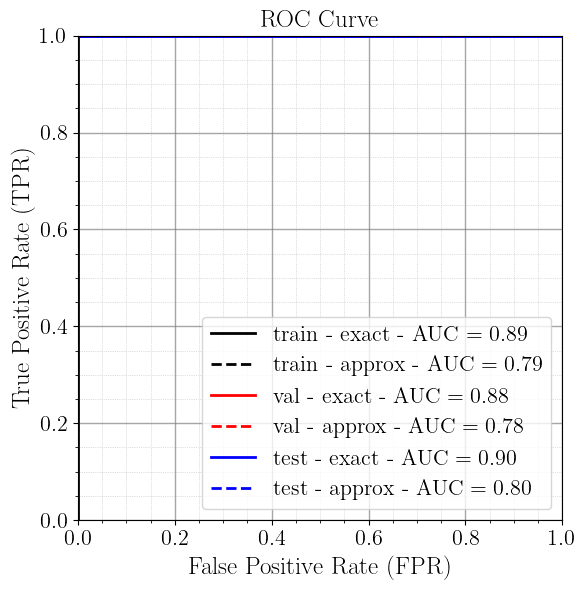

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume ROC_curve returns two numpy arrays: FPR and TPR, both in [0,1].
FPR_train_exact, TPR_train_exact, AUC_train_exact = ROC_curve(x_train, omega_true, p_train)
FPR_train_approx, TPR_train_approx, AUC_train_approx = ROC_curve(x_train, omega_approx, p_train)
FPR_val_exact, TPR_val_exact, AUC_val_exact = ROC_curve(x_val, omega_true, p_val)
FPR_val_approx, TPR_val_approx, AUC_val_approx = ROC_curve(x_val, omega_approx, p_val)
FPR_test_exact, TPR_test_exact, AUC_test_exact = ROC_curve(x_test, omega_true, p_test)
FPR_test_approx, TPR_test_approx, AUC_test_approx = ROC_curve(x_test, omega_approx, p_test)

# --- Define custom tick marks ---
x_major_ticks = np.arange(0, 1.01, 0.2)
x_minor_ticks = np.arange(0, 1.01, 0.05)
y_major_ticks = np.arange(0, 1.01, 0.2)
y_minor_ticks = np.arange(0, 1.01, 0.05)

# Enable LaTeX rendering for text (if a full TeX installation is available)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage{amssymb}'

# --- Create the ROC plot ---
fig, ax = plt.subplots(figsize=(6, 6))  # Square figure for aspect ratio 1

# Plot the ROC curve as a joined red, thick line.
ax.plot(FPR_train_exact, TPR_train_exact, color='black', linewidth=2, label=r'$\text{train - exact - AUC} = %.2f$' % AUC_train_exact)
ax.plot(FPR_train_approx, TPR_train_approx, color='black', linestyle='--', linewidth=2, label=r'$\text{train - approx - AUC} = %.2f$' % AUC_train_approx)
ax.plot(FPR_val_exact, TPR_val_exact, color='red', linewidth=2, label=r'$\text{val - exact - AUC} = %.2f$' % AUC_val_exact)
ax.plot(FPR_val_approx, TPR_val_approx, color='red', linestyle='--', linewidth=2, label=r'$\text{val - approx - AUC} = %.2f$' % AUC_val_approx)
ax.plot(FPR_test_exact, TPR_test_exact, color='blue', linewidth=2, label=r'$\text{test - exact - AUC} = %.2f$' % AUC_test_exact)
ax.plot(FPR_test_approx, TPR_test_approx, color='blue', linestyle='--', linewidth=2, label=r'$\text{test - approx - AUC} = %.2f$' % AUC_test_approx)

# Set title
plt.title(r'$\text{ROC Curve}$', fontsize = 18)

# Set the plot range.
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Set the aspect ratio to 1.
ax.set_aspect('equal')

# Set custom major and minor ticks.
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# Set axis labels in LaTeX.
ax.set_xlabel(r'$\text{False Positive Rate (FPR)}$', fontsize=18)
ax.set_ylabel(r'$\text{True Positive Rate (TPR)}$', fontsize=18)

# Add a legend in the lower right.
ax.legend(loc='lower right', fontsize=16)

# Optionally, add grid lines for better readability.
ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)

plt.tight_layout()

# Save the figure as a PDF file.
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution_roc.pdf')

plt.show()

### Probabilistic model (cubic data - cubic model)

In [54]:
def poly(x: np.ndarray, 
         omega: np.ndarray, 
         noise_std: float = 0.
        ) -> np.ndarray:
    """
    Evaluates a polynomial with coefficients omega at x, adding independent Gaussian noise 
    to each coefficient for each data point.
    
    Parameters
    ----------
    x : np.ndarray
        Input values. Can be a scalar or a 1D numpy array.
    omega : np.ndarray
        Coefficients of the polynomial.
    noise_std : float, optional
        Standard deviation of the Gaussian noise added to each coefficient, by default 1.
        
    Returns
    -------
    np.ndarray or float
        The output of the polynomial function evaluated at each x, with independent noise for each data point.
    """
    np.random.seed(0)
    # Ensure x is an array.
    x = np.atleast_1d(x)
    # Number of coefficients.
    k = len(omega)
    # For each coefficient, compute the corresponding powers of x: this creates a (k, len(x)) array.
    powers = np.array([x**i for i in range(k)])
    # Generate independent noise for each coefficient and each data point.
    noise = np.random.normal(0, noise_std, size=powers.shape)
    # Add noise to the coefficients and multiply elementwise by the power of x.
    effective_terms = (omega.reshape(-1, 1) + noise) * powers
    # Sum over the coefficients (axis 0) to get the final result.
    result = effective_terms.sum(axis=0)
    # If x was originally a scalar, return a scalar.
    if result.size == 1:
        return result.item()
    return result

def p(x: float, 
      omega: np.ndarray,
      noise_std: float = 0.
      ) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega, noise_std)
    return 1.0 / (1.0 + np.exp(-poly_val))

def p_approx(x: float, 
             omega: np.ndarray,
             noise_std: float = 0.
             ) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega, noise_std)
    return 1./2 + poly_val/4.

def design_matrix(x: np.ndarray, degree: int) -> np.ndarray:
    """Computes the design matrix for a polynomial of a given degree.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    degree : int
        Degree of the polynomial.
    
    Returns
    -------
    np.ndarray
        Design matrix.
    """
    X = np.zeros((len(x), degree + 1))
    for i in range(degree + 1):
        X[:, i] = x**i
    return X

In [55]:
# Define the true parameters
omega_true = np.array([2, -3, -2, 1])

# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Define the approximate objective: squared difference between y_approx(x,omega_true) and 0.5.
def objective_approx(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p_approx(x_scalar, omega) - 0.5)**2

decision_boundary = []

# Initial guess for x (e.g., 0)
initial_x = np.array([-2.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([2.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

Decision boundary x = [-1.34292303]
Decision boundary (from approx solution) x = -1.342923012576254
Decision boundary x = [0.52931647]
Decision boundary (from approx solution) x = -1.342923012576254
Decision boundary x = [2.8136065]
Decision boundary (from approx solution) x = -1.342923012576254


In [56]:
# Generate data coordinates
x_train = np.sort(np.concatenate(((2/3) - 0.02 * np.arange(1, 101),(2/3) + 0.02 * np.arange(1, 101))))
x_val = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) + 0.03
x_test = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) - 0.03

X_train = design_matrix(x_train, 3)
X_val = design_matrix(x_val, 3)
X_test = design_matrix(x_test, 3)

p_train = p(x_train, omega_true, noise_std = 0.5)
p_val = p(x_val, omega_true, noise_std = 0.5)
p_test = p(x_test, omega_true, noise_std = 0.5)

Y_train = np.array([1 if p_i >= 0.5 else 0 for p_i in p_train])
Y_val = np.array([1 if p_i >= 0.5 else 0 for p_i in p_val])
Y_test = np.array([1 if p_i >= 0.5 else 0 for p_i in p_test])

print("Train data for class 1:", np.count_nonzero(Y_train), "out of", len(Y_train))
print("Validation data for class 1:", np.count_nonzero(Y_val), "out of", len(Y_val))
print("Test data for class 1:", np.count_nonzero(Y_test), "out of", len(Y_test))

Train data for class 1: 102 out of 200
Validation data for class 1: 52 out of 100
Test data for class 1: 54 out of 100


In [57]:
omega_approx = np.linalg.pinv(X_train.T @ X_train) @ (4 * X_train.T @ Y_train - 2 * X_train.T @ np.ones_like(Y_train))
print("Approximate omega:", omega_approx)

result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary (from approx solution) x =", result_approx.x[0])

Approximate omega: [ 1.62370132 -2.01177318 -1.04910373  0.54730383]
Decision boundary (from approx solution) x = 2.8136064975014605


In [58]:
def Y_pred(p: np.ndarray, 
           threshold: float = 0.5
          ) -> np.ndarray:
    """Converts probabilities to predictions using a threshold.
    
    Parameters
    ----------
    p : np.ndarray
        Probabilities.
    threshold : float
        Threshold for the conversion.
    
    Returns
    -------
    np.ndarray
        Predictions.
    """
    return (p >= threshold).astype(int)#np.array([1 if p_i > threshold else 0 for p_i in p])

def loss_fn(X: np.ndarray, 
            p: np.ndarray, 
            omega: np.ndarray,
            threshold: float = 0.5
           ) -> float:
    """Computes the logistic loss for a given dataset and parameters.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega : np.ndarray
        Parameters.
    
    Returns
    -------
    float
        Logistic loss.
    """
    Y = Y_pred(p, threshold)
    res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
    return -1 * res

In [60]:
# Minimize the loss function and extract omega
objective = lambda omega: loss_fn(X_train, p_train, omega)
result = minimize(objective, omega_true, method='BFGS')
omega_exact = result.x
print("Exact omega:", omega_exact)

Exact omega: [ 3.64757775 -4.40694359 -2.4405024   1.30506133]


In [61]:
# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective_exact(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Initial guess for x (e.g., 0)
initial_x = np.array([-2.0])
result = minimize(objective_exact, initial_x, args=(omega_approx,), method='BFGS')
result_approx = minimize(objective_exact, initial_x, args=(omega_exact,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])
result = minimize(objective_exact, initial_x, args=(omega_approx,), method='BFGS')
result_approx = minimize(objective_exact, initial_x, args=(omega_exact,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([2.0])
result = minimize(objective_exact, initial_x, args=(omega_approx,), method='BFGS')
result_approx = minimize(objective_exact, initial_x, args=(omega_exact,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])

Decision boundary x = [-1.58453672]
Decision boundary (from approx solution) x = -1.5302495679971382
Decision boundary x = [0.65861607]
Decision boundary (from approx solution) x = 0.6686312158759256
Decision boundary x = [2.84277862]
Decision boundary (from approx solution) x = 2.7316476020318654


In [62]:
print("Approximate omega:", omega_approx)
print("Approximate decision boundary x =", result_approx.x[0])
print("Train loss - approximate omega:", loss_fn(X_train, p_train, omega_approx))
print("Validation loss - approximate omega:", loss_fn(X_val, p_val, omega_approx))
print("Test loss - approximate omega:", loss_fn(X_test, p_test, omega_approx))
print("\nExact omega:", omega_exact)
print("Exact decision boundary x =", result.x[0])
print("Train loss - exact omega:", loss_fn(X_train, p_train, omega_exact))
print("Validation loss - exact omega:", loss_fn(X_val, p_val, omega_exact))
print("Test loss - exact omega:", loss_fn(X_test, p_test, omega_exact))

Approximate omega: [ 1.62370132 -2.01177318 -1.04910373  0.54730383]
Approximate decision boundary x = 2.7316476020318654
Train loss - approximate omega: 55.55820958018984
Validation loss - approximate omega: 40.083312189370254
Test loss - approximate omega: 39.98138720505483

Exact omega: [ 3.64757775 -4.40694359 -2.4405024   1.30506133]
Exact decision boundary x = 2.842778615846823
Train loss - exact omega: 41.71975373894338
Validation loss - exact omega: 42.46379501249115
Test loss - exact omega: 42.480162059092436


In [63]:
train_loss = loss_fn(X_train, Y_train, omega_approx)
val_loss = loss_fn(X_val, Y_val, omega_approx)
test_loss = loss_fn(X_test, Y_test, omega_approx)
print("Train loss:", train_loss)
print("Validation loss:", val_loss)
print("Test loss:", test_loss)

Train loss: 55.55820958018984
Validation loss: 40.083312189370254
Test loss: 39.98138720505483


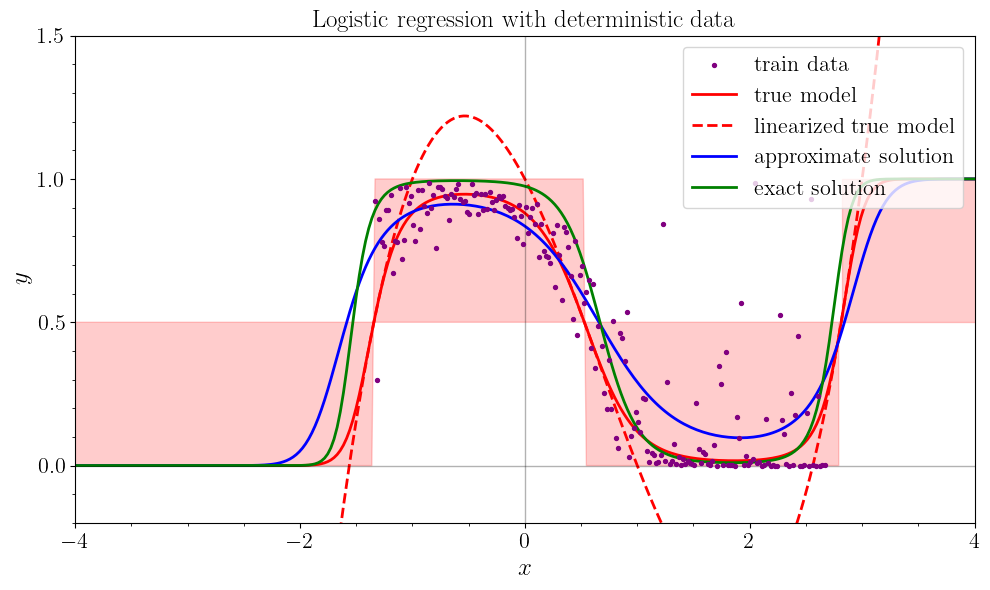

In [64]:
save = True

def H(c: float) -> float:
    """Computes the entropy function H(c).
    
    Parameters
    ----------
    c : float
        Value of c.
    
    Returns
    -------
    float
    
        Entropy value.
    """
    return np.heaviside(c, 0.5)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Generate custom tick marks ---
x_major_ticks = np.arange(-10, 10+1, 2)
x_minor_ticks = np.arange(-10, 10+0.5, 0.5)
y_major_ticks = np.arange(-2, 2+0.5, 0.5)
y_minor_ticks = np.arange(-2, 2+0.1, 0.1)

# --- Define plotting range and decision boundary ---
x_plot = np.linspace(-7, 7, 500)

# --- Create the main plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot training data ---
# Assume x_train and p_train are numpy arrays. For demonstration, we create dummy data:
ax.scatter(x_train, p_train, color='purple', s=8, zorder=5, label=r'$\text{train data}$')

# Plot the various curves with styles similar to your Mathematica code:
ax.plot(x_plot, p(x_plot,omega_true), color='red', linewidth=2, label=r'$\text{true model}$')
ax.plot(x_plot, p_approx(x_plot,omega_true), color='red', linestyle='--', linewidth=2, label=r'$\text{linearized true model}$')
ax.plot(x_plot, p(x_plot, omega_approx), color='blue', linewidth=2, label=r'$\text{approximate solution}$')
ax.plot(x_plot, p(x_plot, omega_exact), color='green', linewidth=2, label=r'$\text{exact solution}$')
# The constant 0.5 curve (with zero opacity) is included for filling purposes:
ax.plot(x_plot, 0.5*np.ones_like(x_plot), color='black', alpha=0, linewidth=2)

# Fill between the constant 0.5 and the Heaviside curve.
# In Mathematica, you filled curve 5 -> 4 and 4 -> 5.
# Here, we assume we want to fill between heaviside(db - x) and 0.5.
# Choose the fill condition appropriately. Here, we fill where heaviside < 0.5.
ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[0]) - H(x_plot - decision_boundary[1]) + H(x_plot - decision_boundary[2]), where=(H(decision_boundary[2] - x_plot) > 0.5),
                color='red', alpha=0.2)
ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[2]), where=(H(decision_boundary[2] - x_plot) < 0.5),
                color='red', alpha=0.2)

# Draw axes
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Finalizing plot
plt.title(f'Logistic regression with deterministic data', fontsize = 18)
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)
#ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
#ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)
ax.set_xlabel(r'$x$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.legend(loc='upper right', fontsize=16)
ax.set_xlim(-4,4)
ax.set_ylim(-0.2, 1.5)

# --- Adjust aspect ratio and layout ---
plt.tight_layout()

# --- Save and show the figure ---
if save:
    plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution_cubic2.pdf')
plt.show()

In [65]:
for t in np.arange(0, 1.1, 0.1):
    #ytrue = Y_train#Y_pred(p(x_train, omega_true, noise_std = 1), threshold=0.5)
    ytrue = Y_pred(p(x_train, omega_true), threshold=0.5)
    ypred = Y_pred(p(x_train, omega_approx, noise_std = 0), threshold=t)

    TP = np.sum((ypred == 1) & (ytrue == 1))
    FP = np.sum((ypred == 1) & (ytrue == 0))
    FN = np.sum((ypred == 0) & (ytrue == 1))
    TN = np.sum((ypred == 0) & (ytrue == 0))

    confusion_matrix = np.array([[TP, FP],
                                 [FN, TN]])
    
    if (TP + FN) > 0:
        TPR = TP / (TP + FN)
    else:
        TPR = 0.0  # or np.nan, depending on your preference

    if (FP + TN) > 0:
        FPR = FP / (FP + TN)
    else:
        FPR = 0.0  # or np.nan

    print("\n--------------------")
    print("Threshold:", t)
    print("[FPR,TPR]:", [FPR, TPR])    
    print("Confusion matrix: \n", confusion_matrix)


--------------------
Threshold: 0.0
[FPR,TPR]: [np.float64(1.0), np.float64(1.0)]
Confusion matrix: 
 [[ 94 106]
 [  0   0]]

--------------------
Threshold: 0.1
[FPR,TPR]: [np.float64(0.8773584905660378), np.float64(1.0)]
Confusion matrix: 
 [[94 93]
 [ 0 13]]

--------------------
Threshold: 0.2
[FPR,TPR]: [np.float64(0.3867924528301887), np.float64(1.0)]
Confusion matrix: 
 [[94 41]
 [ 0 65]]

--------------------
Threshold: 0.30000000000000004
[FPR,TPR]: [np.float64(0.20754716981132076), np.float64(1.0)]
Confusion matrix: 
 [[94 22]
 [ 0 84]]

--------------------
Threshold: 0.4
[FPR,TPR]: [np.float64(0.12264150943396226), np.float64(1.0)]
Confusion matrix: 
 [[94 13]
 [ 0 93]]

--------------------
Threshold: 0.5
[FPR,TPR]: [np.float64(0.05660377358490566), np.float64(1.0)]
Confusion matrix: 
 [[ 94   6]
 [  0 100]]

--------------------
Threshold: 0.6000000000000001
[FPR,TPR]: [np.float64(0.0), np.float64(0.9893617021276596)]
Confusion matrix: 
 [[ 93   0]
 [  1 106]]

---------

In [66]:
def ROC_curve(x: np.ndarray, 
              omega_solution: np.ndarray,
              p_true: np.ndarray,
             ) -> Tuple[np.ndarray, np.ndarray]:
    """Computes the ROC curve for a given dataset and parameters.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    omega_true : np.ndarray
        True parameters.
    onega_solution : np.ndarray
        Estimated parameters.
    
    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        ROC curve.
    """
    p_solution = p(x, omega_solution)
    
    #thresholds = np.unique(np.concatenate((p_true, p_approx)))
    thresholds = np.linspace(0, 1, 1000)
    spacing = thresholds[1] - thresholds[0]
    TPR = []
    FPR = []
    AUC = 0.0
    
    for i, threshold in enumerate(thresholds):
        y_true = Y_pred(p_true, 0.5)
        y_pred = Y_pred(p_solution, threshold)
        
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        FN = np.sum((y_pred == 0) & (y_true == 1))
        TN = np.sum((y_pred == 0) & (y_true == 0))
        
        if (TP + FN) > 0:
            TPR.append(TP / (TP + FN))
        else:
            TPR.append(0.0)
    
        if (FP + TN) > 0:
            FPR.append(FP / (FP + TN))
        else:
            FPR.append(0.0)

        AUC += TPR[-1] * spacing
        
    return FPR, TPR, AUC

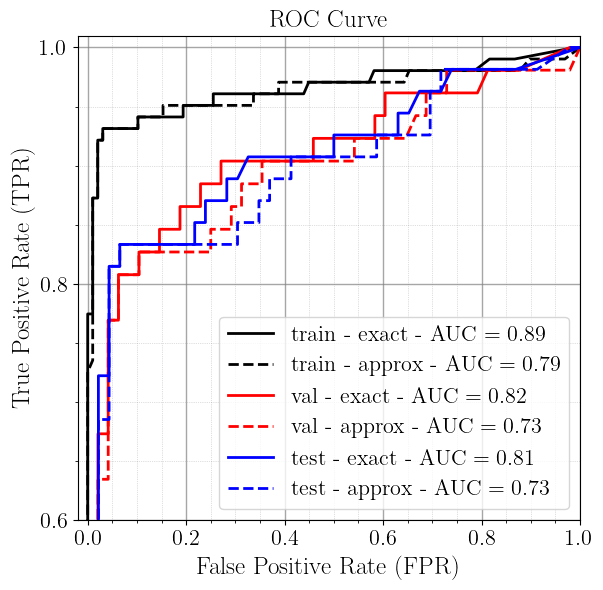

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# Assume ROC_curve returns two numpy arrays: FPR and TPR, both in [0,1].
FPR_train_exact, TPR_train_exact, AUC_train_exact = ROC_curve(x_train, omega_exact, p_train)
FPR_val_exact, TPR_val_exact, AUC_val_exact = ROC_curve(x_val, omega_exact, p_val)
FPR_train_approx, TPR_train_approx, AUC_train_approx = ROC_curve(x_train, omega_approx, p_train)
FPR_val_approx, TPR_val_approx, AUC_val_approx = ROC_curve(x_val, omega_approx, p_val)
FPR_test_exact, TPR_test_exact, AUC_test_exact = ROC_curve(x_test, omega_exact, p_test)
FPR_test_approx, TPR_test_approx, AUC_test_approx = ROC_curve(x_test, omega_approx, p_test)

# --- Define custom tick marks ---
x_major_ticks = np.arange(0, 1.01, 0.2)
x_minor_ticks = np.arange(0, 1.01, 0.05)
y_major_ticks = np.arange(0, 1.01, 0.2)
y_minor_ticks = np.arange(0, 1.01, 0.05)

# Enable LaTeX rendering for text (if a full TeX installation is available)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage{amssymb}'

# --- Create the ROC plot ---
fig, ax = plt.subplots(figsize=(6, 6))  # Square figure for aspect ratio 1

# Plot the ROC curve as a joined red, thick line.
ax.plot(FPR_train_exact, TPR_train_exact, color='black', linewidth=2, label=r'$\text{train - exact - AUC} = %.2f$' % AUC_train_exact)
ax.plot(FPR_train_approx, TPR_train_approx, color='black', linestyle='--', linewidth=2, label=r'$\text{train - approx - AUC} = %.2f$' % AUC_train_approx)
ax.plot(FPR_val_exact, TPR_val_exact, color='red', linewidth=2, label=r'$\text{val - exact - AUC} = %.2f$' % AUC_val_exact)
ax.plot(FPR_val_approx, TPR_val_approx, color='red', linestyle='--', linewidth=2, label=r'$\text{val - approx - AUC} = %.2f$' % AUC_val_approx)
ax.plot(FPR_test_exact, TPR_test_exact, color='blue', linewidth=2, label=r'$\text{test - exact - AUC} = %.2f$' % AUC_test_exact)
ax.plot(FPR_test_approx, TPR_test_approx, color='blue', linestyle='--', linewidth=2, label=r'$\text{test - approx - AUC} = %.2f$' % AUC_test_approx)

# Set title
plt.title(r'$\text{ROC Curve}$', fontsize = 18)

# Set the aspect ratio to 1.
ax.set_aspect('auto')

# Set custom major and minor ticks.
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# Set axis labels in LaTeX.
ax.set_xlabel(r'$\text{False Positive Rate (FPR)}$', fontsize=18)
ax.set_ylabel(r'$\text{True Positive Rate (TPR)}$', fontsize=18)

# Add a legend in the lower right.
ax.legend(loc='lower right', fontsize=16)

# Optionally, add grid lines for better readability.
ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)

plt.tight_layout()

# Set the plot range.
ax.set_xlim(-0.02, 1.)
ax.set_ylim(0.6, 1.01)

# Save the figure as a PDF file.
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution_cubic2_roc.pdf')

plt.show()

## TensorFlow2

### Deterministic model (polynomial data)

In [266]:
class PolynomialTF:
    def __init__(self, coefficients):
        """
        Initializes the polynomial with given coefficients.

        Args:
            coefficients: A 1D tf.Tensor or a Python list of polynomial coefficients
                          from the lowest to the highest degree.
        """
        self.coefficients = tf.convert_to_tensor(coefficients, dtype=tf.float64)

    def __call__(self, x):
        """
        Evaluates the polynomial at given x values.

        Args:
            x: A 1D tf.Tensor of x values where the polynomial is to be evaluated.

        Returns:
            A tf.Tensor containing the evaluated polynomial values at each x value.
        """
        x = tf.convert_to_tensor(x, dtype=tf.float64)
        degree = tf.shape(self.coefficients)[0]
        x_powers = tf.pow(tf.expand_dims(x, -1), tf.range(0, degree, dtype=tf.float64))
        poly_values = tf.reduce_sum(tf.multiply(x_powers, self.coefficients), axis=1)
        return poly_values

    def __str__(self):
        """
        Returns a string representation of the polynomial.
        """
        terms = []
        for i, coeff in enumerate(self.coefficients.numpy()):
            if coeff != 0:  # Skip terms with a coefficient of zero
                if i == 0:
                    terms.append(f"{coeff:.10g}")
                elif i == 1:
                    terms.append(f"{coeff:+.10g} x")
                else:
                    terms.append(f"{coeff:+.10g} x**{i}")
        return " ".join(terms)


In [267]:
def y(x: tf.Tensor) -> tf.Tensor:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A tf tensor of x values.
    
    Returns:
        A tf tensor of y values computed from the polynomial expression.
    """
    return tf.cast(-tf.pow(x, 4)/24 - tf.pow(x, 3)/6 + tf.pow(x, 2)/2 + x + 2, dtype=tf.float64)

def design_matrix(degree: int,
                  x_values: tf.Tensor
                 ) -> tf.Tensor:
    """Generates a design matrix for polynomial regression of a specified degree.
    
    Args:
        degree: The degree of the polynomial hypothesis.
        x_values: A tf tensor of x values.
    
    Returns:
        A design matrix as a tf tensor.
    """
    return tf.stack([x_values**i for i in range(degree + 1)], axis=1)

def omega_solution(X: tf.Tensor, 
                   Y: tf.Tensor
                  ) -> tf.Tensor:
    """Calculates the polynomial coefficients (omega) that best fit the data.
    
    Args:
        X: The design matrix.
        Y: A tf tensor of target y values.
    
    Returns:
        A tf tensor of calculated omega values.
    """
    XT: tf.Tensor = tf.transpose(X)
    Y: tf.Tensor = tf.reshape(Y, (-1, 1))
    omega: tf.Tensor = tf.linalg.pinv(XT @ X) @ XT @ Y
    return tf.reshape(omega, [-1])

def poly_solution(omega_solution: tf.Tensor) -> PolynomialTF:
    """Converts omega coefficients to a tf PolynomialTF object.
    
    Args:
        omega_solution: A tf.Tensor of omega coefficients.
    
    Returns:
        A tf PolynomialTF object representing the fitted polynomial.
    """
    return PolynomialTF(omega_solution)

def MSE(omega_solution: tf.Tensor, 
        x_values: tf.Tensor,
        y_true: tf.Tensor
       ) -> tf.Tensor:
    """
    Calculates the Mean Squared Error (MSE) for given omega coefficients and x values.
    Uses tensorflow MSE loss function.
    
    Args:
        omega_solution: A 1D tf.Tensor of omega coefficients.
        x_values: A 1D tf.Tensor of x values for evaluation.
        y_true: A 1D tf.Tensor of true y values.
    
    Returns:
        The MSE as a tf.Tensor.
    """
    poly: PolynomialTF = poly_solution(omega_solution)
    y_pred: tf.Tensor = poly(x_values)
    loss: tf.Tensor = tf.losses.MSE(y_true, y_pred)
    return loss

In [268]:
# Generate data coordinates
x_train: tf.Tensor = tf.range(-3, 4, 1, dtype=tf.float64)
x_val: tf.Tensor = tf.range(-2.5, 3.5, 1, dtype=tf.float64)

# Generate target values
y_train: tf.Tensor = y(x_train)
y_val: tf.Tensor = y(x_val)

# Perform the fit for each degree and print the results
show: bool = True
for d in range(8):
    # Generate the design matrix
    X_train: tf.Tensor = design_matrix(d, x_train)
    
    # Compute the weights of the solution
    omega_hat: tf.Tensor = omega_solution(X_train, y_train)
    
    # Define the fit polynomial
    poly: PolynomialTF = poly_solution(omega_hat)
    
    # Compute the MSE for the training and validation data
    MSE_train: tf.Tensor = MSE(omega_hat, x_train, y_train)
    MSE_val: tf.Tensor = MSE(omega_hat, x_val, y_val)
    
    # Print the results
    if show:
        print(f"===================================================")
        print(f"---------------------- d = {d} ----------------------")
        print(f"===================================================")
        print(f"The degree of the polynomial is: {d}\n")
        print(f"The design matrix is:\n{X_train}\n")
        print(f"The solution for omega is: {omega_hat}\n")  
        print(f"The polynomial is: {poly}\n")
        print(f"The MSE for the training data is: {MSE_train}")
        print(f"The MSE for the validation data is: {MSE_val}\n")

---------------------- d = 0 ----------------------
The degree of the polynomial is: 0

The design matrix is:
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]

The solution for omega is: [2.83333333]

The polynomial is: 2.833333333

The MSE for the training data is: 1.2033730158730158
The MSE for the validation data is: 0.6907619900173613

---------------------- d = 1 ----------------------
The degree of the polynomial is: 1

The design matrix is:
[[ 1. -3.]
 [ 1. -2.]
 [ 1. -1.]
 [ 1.  0.]
 [ 1.  1.]
 [ 1.  2.]
 [ 1.  3.]]

The solution for omega is: [ 2.83333333 -0.16666667]

The polynomial is: 2.833333333 -0.1666666667 x

The MSE for the training data is: 1.0922619047619047
The MSE for the validation data is: 0.925715693721065

---------------------- d = 2 ----------------------
The degree of the polynomial is: 2

The design matrix is:
[[ 1. -3.  9.]
 [ 1. -2.  4.]
 [ 1. -1.  1.]
 [ 1.  0.  0.]
 [ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]]

The solution for omega is: [ 2.42857143 -0.16666

### Deterministic model (non-polynomial data)

In [216]:
def y(x: tf.Tensor) -> tf.Tensor:
    """Computes the function 3 + sin(x) - cos(x) for given x values.
    
    Args:
        x: A tf tensor of x values.
    
    Returns:
        A tf tensor of y values computed from the function.
    """
    return 3. + tf.sin(x) - tf.cos(x)

In [217]:
# Generate data coordinates
x_train: tf.Tensor = tf.range(-3, 4, 1, dtype=tf.float64)
x_val: tf.Tensor = tf.range(-2.5, 3.5, 1, dtype=tf.float64)

# Generate target values
y_train: tf.Tensor = y(x_train)
y_val: tf.Tensor = y(x_val)

# Perform the fit for each degree and print the results
show: bool = True
for d in range(10):
    # Generate the design matrix
    X_train: tf.Tensor = design_matrix(d, x_train)
    
    # Compute the weights of the solution
    omega_hat: tf.Tensor = omega_solution(X_train, y_train)
    
    # Define the fit polynomial
    poly: PolynomialTF = poly_solution(omega_hat)
    
    # Compute the MSE for the training and validation data
    MSE_train: tf.Tensor = MSE(omega_hat, x_train, y_train)
    MSE_val: tf.Tensor = MSE(omega_hat, x_val, y_val)
    
    # Print the results
    if show:
        print(f"===================================================")
        print(f"---------------------- d = {d} ----------------------")
        print(f"===================================================")
        print(f"The degree of the polynomial is: {d}\n")
        #print(f"The hypothesis is: {poly}\n")
        print(f"The design matrix is:\n{X_train}\n")
        print(f"The solution for omega is: {omega_hat}\n")  
        print(f"The polynomial is: {poly}\n")
        print(f"The MSE for the training data is: {MSE_train}")
        print(f"The MSE for the validation data is: {MSE_val}\n")

---------------------- d = 0 ----------------------
The degree of the polynomial is: 0

The design matrix is:
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]

The solution for omega is: [3.10452486]

The polynomial is: 3.104524865

The MSE for the training data is: 0.9890745526099051
The MSE for the validation data is: 1.0211811587186352

---------------------- d = 1 ----------------------
The degree of the polynomial is: 1

The design matrix is:
[[ 1. -3.]
 [ 1. -2.]
 [ 1. -1.]
 [ 1.  0.]
 [ 1.  1.]
 [ 1.  2.]
 [ 1.  3.]]

The solution for omega is: [3.10452486 0.2202447 ]

The polynomial is: 3.104524865 +0.2202447045 x

The MSE for the training data is: 0.7950436332141866
The MSE for the validation data is: 0.6880882026927811

---------------------- d = 2 ----------------------
The degree of the polynomial is: 2

The design matrix is:
[[ 1. -3.  9.]
 [ 1. -2.  4.]
 [ 1. -1.  1.]
 [ 1.  0.  0.]
 [ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]]

The solution for omega is: [2.28825159 0.2202447 

### Deterministic model with non-polynomial fit (non-polynomial data)

In [ ]:
def y(x: tf.Tensor) -> tf.Tensor:
    """Computes the function 3 + sin(x) - cos(x) for given x values.
    
    Args:
        x: A tf tensor of x values.
    
    Returns:
        A tf tensor of y values computed from the function.
    """
    return 3. + tf.sin(x) - tf.cos(x)

def y_stat_np(x: np.ndarray) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y(x).numpy()
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, 1)
    
    return tf.cast(noisy_y_values, dtype=tf.float64)

def design_matrix_trig_tf(x_values: tf.Tensor) -> tf.Tensor:
    """Generates a design matrix for trigonometric regression with TensorFlow.
    
    Args:
        x_values: A tf.Tensor of x values.
    
    Returns:
        A tf.Tensor representing the design matrix with columns for 1, sin(x), and cos(x).
    """
    ones = tf.ones_like(x_values)
    sin_x = tf.sin(x_values)
    cos_x = tf.cos(x_values)
    # Stack along the second dimension (axis=1) to form the design matrix
    return tf.stack([ones, sin_x, cos_x], axis=1)

def omega_solution(X: tf.Tensor, 
                   Y: tf.Tensor
                  ) -> tf.Tensor:
    """Calculates the polynomial coefficients (omega) that best fit the data.
    
    Args:
        X: The design matrix.
        Y: A tf tensor of target y values.
    
    Returns:
        A tf tensor of calculated omega values.
    """
    XT: tf.Tensor = tf.transpose(X)
    Y: tf.Tensor = tf.reshape(Y, (-1, 1))
    omega: tf.Tensor = tf.linalg.pinv(XT @ X) @ XT @ Y
    return tf.reshape(omega, [-1])

def trig_solution(omega_solution: tf.Tensor, 
                  x_values: tf.Tensor
                 ) -> tf.Tensor:
    """Evaluates the trigonometric model at given x values using the omega coefficients.
    
    Args:
        omega_solution: A tf.Tensor of omega coefficients for [constant, sin(x), cos(x)].
        x_values: A tf.Tensor of x values for evaluation.
    
    Returns:
        A tf.Tensor of y values predicted by the trigonometric model.
    """
    return omega_solution[0] + omega_solution[1] * tf.sin(x_values) + omega_solution[2] * tf.cos(x_values)

def MSE(omega_solution: tf.Tensor, 
        x_values: tf.Tensor,
        y_true: tf.Tensor
       ) -> tf.Tensor:
    """
    Calculates the Mean Squared Error (MSE) for given omega coefficients and x values.
    Uses tensorflow MSE loss function.
    
    Args:
        omega_solution: A 1D tf.Tensor of omega coefficients.
        x_values: A 1D tf.Tensor of x values for evaluation.
    
    Returns:
        The MSE as a tf.Tensor.
    """
    y_pred: tf.Tensor = trig_solution(omega_solution, x_values)
    loss: tf.Tensor = tf.losses.MSE(y_true, y_pred)
    return loss


In [219]:
# Generate data coordinates
x_train: tf.Tensor = tf.range(-3, 4, 1, dtype=tf.float64)
x_val: tf.Tensor = tf.range(-2.5, 3.5, 1, dtype=tf.float64)

# Generate target values through the statistical model with tf
tf.random.set_seed(100)
y_train: tf.Tensor = y(x_train)
y_val: tf.Tensor = y(x_val)

# Flag to control printing of the solution details
show: bool = True

# Generate the design matrix
X_train: tf.Tensor = design_matrix_trig_tf(x_train)

# Compute the weights of the solution
omega_hat: tf.Tensor = omega_solution(X_train, y_train)

# Compute the MSE for the training and validation data
MSE_train: tf.Tensor = MSE(omega_hat, x_train, y_train)
MSE_val: tf.Tensor = MSE(omega_hat, x_val, y_val)

# Print the results
if show:
    print("----------------- Trigonometric Model -----------------")
    print(f"The design matrix is:\n{X_train}\n")
    print(f"The target values are:\n{y_train}\n")
    print(f"The solution for omega is: {omega_hat}\n")
    print(f"The MSE for the training data is: {MSE_train}")
    print(f"The MSE for the validation data is: {MSE_val}\n")

----------------- Trigonometric Model -----------------
The design matrix is:
[[ 1.         -0.14112001 -0.9899925 ]
 [ 1.         -0.90929743 -0.41614684]
 [ 1.         -0.84147098  0.54030231]
 [ 1.          0.          1.        ]
 [ 1.          0.84147098  0.54030231]
 [ 1.          0.90929743 -0.41614684]
 [ 1.          0.14112001 -0.9899925 ]]

The target values are:
[3.84887249 2.50684941 1.61822671 2.         3.30116868 4.32544426
 4.1311125 ]

The solution for omega is: [ 3.  1. -1.]

The MSE for the training data is: 1.2678121691051976e-30
The MSE for the validation data is: 7.888609052210118e-31



### Probabilistic model (polynomial data)

In [269]:
def y(x: tf.Tensor) -> tf.Tensor:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A tf tensor of x values.
    
    Returns:
        A tf tensor of y values computed from the polynomial expression.
    """
    return tf.cast(-tf.pow(x, 4)/24 - tf.pow(x, 3)/6 + tf.pow(x, 2)/2 + x + 2, dtype=tf.float64)
    
def y_stat(x: tf.Tensor) -> tf.Tensor:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A tf tensor of x values.
    
    Returns:
        A tf tensor of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: tf.Tensor = y(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: tf.Tensor = true_y_values + tf.random.normal(tf.shape(true_y_values), mean=0.0, stddev=1.0, dtype=tf.float64)
    
    return noisy_y_values

def y_numpy(x: np.ndarray) -> np.ndarray:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression.
    """
    return -x**4/24 - x**3/6 + x**2/2 + x + 2

def y_stat_numpy(x: np.ndarray) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y_numpy(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, 1)
    
    return noisy_y_values

def MSE(omega_solution: tf.Tensor, 
        x_values: tf.Tensor,
        y_true: tf.Tensor
       ) -> tf.Tensor:
    """
    Calculates the Mean Squared Error (MSE) for given omega coefficients and x values.
    Uses tensorflow MSE loss function.
    
    Args:
        omega_solution: A 1D tf.Tensor of omega coefficients.
        x_values: A 1D tf.Tensor of x values for evaluation.
        y_true: A 1D tf.Tensor of true y values.
    
    Returns:
        The MSE as a tf.Tensor.
    """
    poly: PolynomialTF = poly_solution(omega_solution)
    y_pred: tf.Tensor = poly(x_values)
    loss: tf.Tensor = tf.losses.MSE(y_true, y_pred)
    return loss

In [270]:
# Generate data coordinates
x_train: tf.Tensor = tf.range(-3, 4, 1, dtype=tf.float64)
x_val: tf.Tensor = tf.range(-2.5, 3.5, 1, dtype=tf.float64)

# Generate target values
tf.random.set_seed(100)
y_train: tf.Tensor = y_stat(x_train)
y_val: tf.Tensor = y_stat(x_val)

# Notice that the instance of data generated by TensorFlow2 is different than the one generated by numpy. To reproduce the same results as with numpy, one would need to generate data with numpy and then convert it to TensorFlow2 tensors. Comment/uncomment the following lines to use different/same data

# Generate data coordinates
x_train = np.arange(-3, 4, 1)
x_val = np.arange(-2.5, 3.5, 1)

# Generate target values through the statistical model
np.random.seed(100)
y_train = y_stat_numpy(x_train)
y_val = y_stat_numpy(x_val)

# Convert the numpy arrays to TensorFlow tensors
x_train = tf.convert_to_tensor(x_train, dtype=tf.float64)
x_val = tf.convert_to_tensor(x_val, dtype=tf.float64)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float64)
y_val = tf.convert_to_tensor(y_val, dtype=tf.float64)

# Prepare a list to store solutions
solutions: List[Tuple[Any, tf.Tensor, PolynomialTF, tf.Tensor, tf.Tensor]] = []

# Perform the fit for each degree and print the results
show: bool = True
for d in range(10):
    # Generate the design matrix
    X_train: tf.Tensor = design_matrix(d, x_train)
    
    # Compute the weights of the solution
    omega_hat: tf.Tensor = omega_solution(X_train, y_train)
    
    # Define the fit polynomial
    poly: PolynomialTF = poly_solution(omega_hat)
    
    # Compute the MSE for the training and validation data
    MSE_train: tf.Tensor = MSE(omega_hat, x_train, y_train)
    MSE_val: tf.Tensor = MSE(omega_hat, x_val, y_val)
    
    # Store the results
    solutions.append((d, omega_hat, poly, MSE_train, MSE_val))
    
    # Print the results
    if show:
        print(f"===================================================")
        print(f"---------------------- d = {d} ----------------------")
        print(f"===================================================")
        print(f"The degree of the polynomial is: {d}\n")
        #print(f"The hypothesis is: {poly}\n")
        print(f"The design matrix is:\n{X_train}\n")
        print(f"The solution for omega is: {omega_hat}\n")  
        print(f"The polynomial is: {poly}\n")
        print(f"The MSE for the training data is: {MSE_train}")
        print(f"The MSE for the validation data is: {MSE_val}\n")
polynomial_fits = [sol[2] for sol in solutions]

---------------------- d = 0 ----------------------
The degree of the polynomial is: 0

The design matrix is:
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]

The solution for omega is: [3.0062239]

The polynomial is: 3.006223904

The MSE for the training data is: 0.9825576964383046
The MSE for the validation data is: 0.8936504124278191

---------------------- d = 1 ----------------------
The degree of the polynomial is: 1

The design matrix is:
[[ 1. -3.]
 [ 1. -2.]
 [ 1. -1.]
 [ 1.  0.]
 [ 1.  1.]
 [ 1.  2.]
 [ 1.  3.]]

The solution for omega is: [3.0062239  0.05062609]

The polynomial is: 3.006223904 +0.0506260936 x

The MSE for the training data is: 0.9723056910272134
The MSE for the validation data is: 0.8240488071089421

---------------------- d = 2 ----------------------
The degree of the polynomial is: 2

The design matrix is:
[[ 1. -3.  9.]
 [ 1. -2.  4.]
 [ 1. -1.  1.]
 [ 1.  0.  0.]
 [ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]]

The solution for omega is: [ 3.22223603  0.0506260

The polynomial is: 3.006223904 



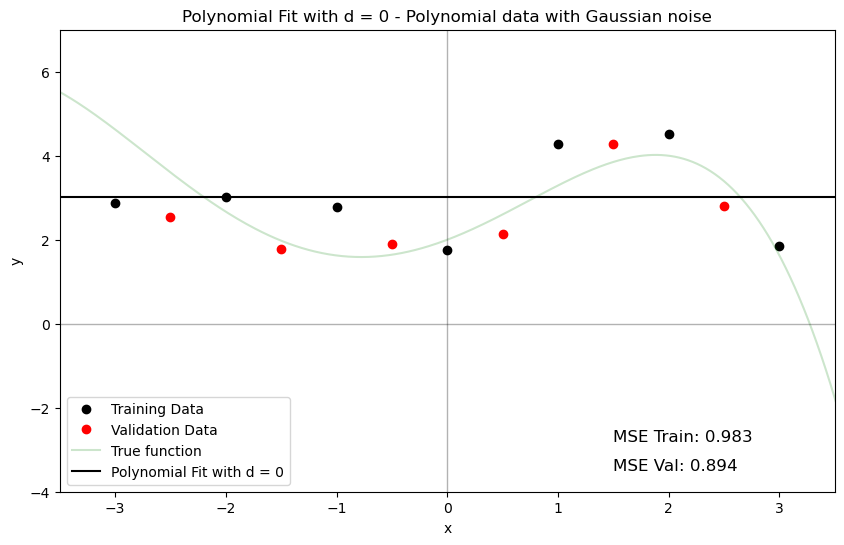

The polynomial is: 3.006223904 +0.0506260936 x 



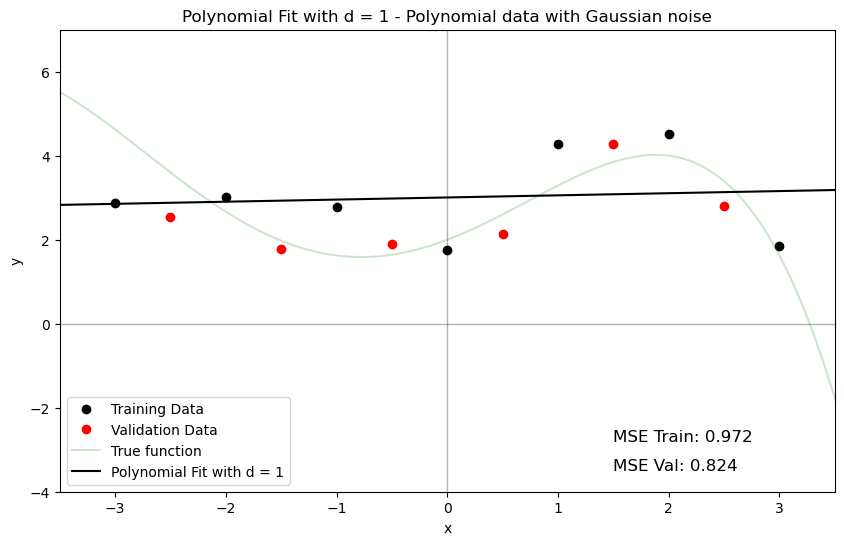

The polynomial is: 3.22223603 +0.0506260936 x -0.05400303145 x**2 



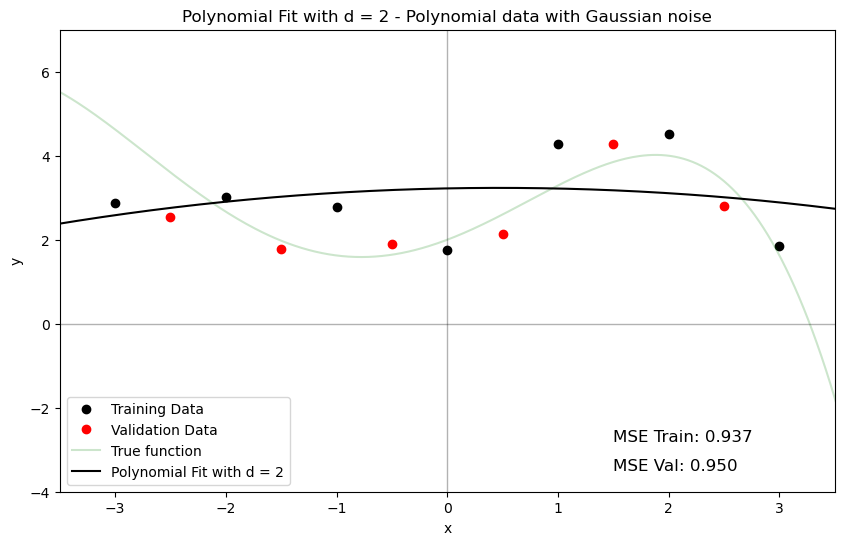

The polynomial is: 3.22223603 +0.8340190925 x -0.05400303145 x**2 -0.1119132856 x**3 



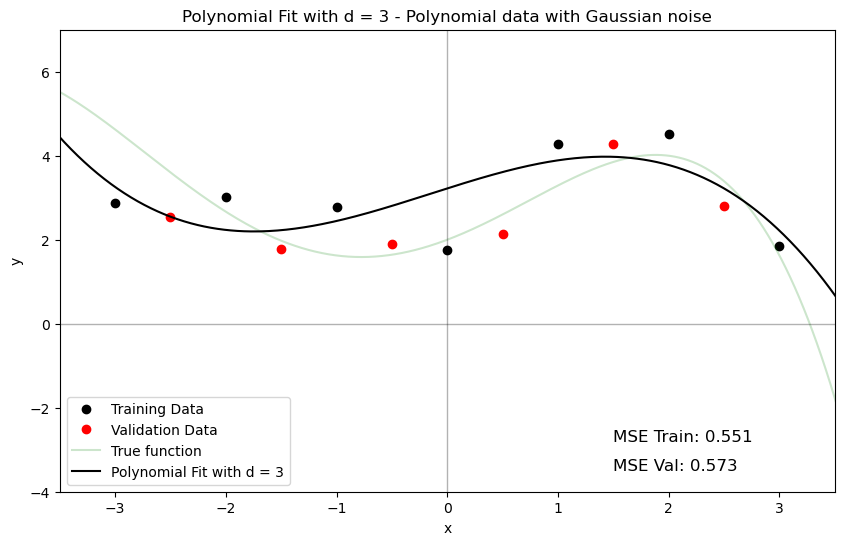

The polynomial is: 2.405444663 +0.8340190925 x +0.7060667129 x**2 -0.1119132856 x**3 -0.0794102718 x**4 



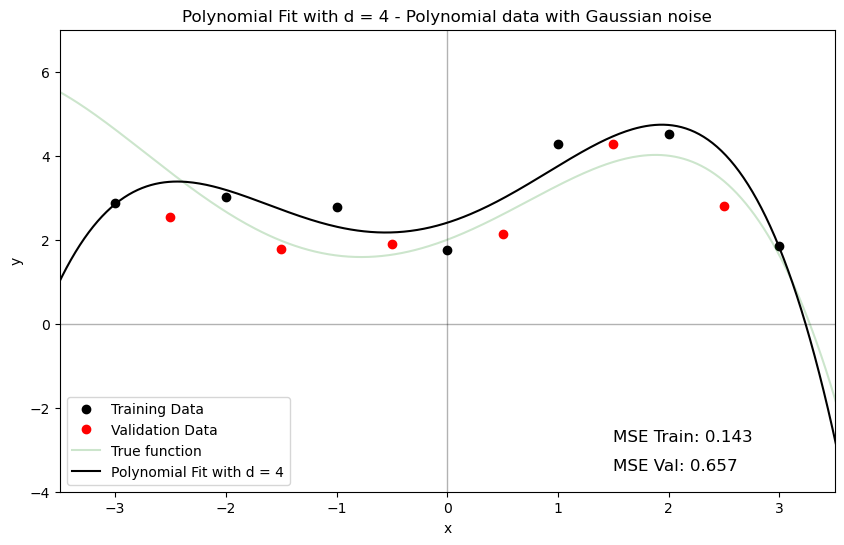

The polynomial is: 2.405444663 +0.8783320583 x +0.7060667129 x**2 -0.1326321341 x**3 -0.0794102718 x**4 +0.0017759013 x**5 



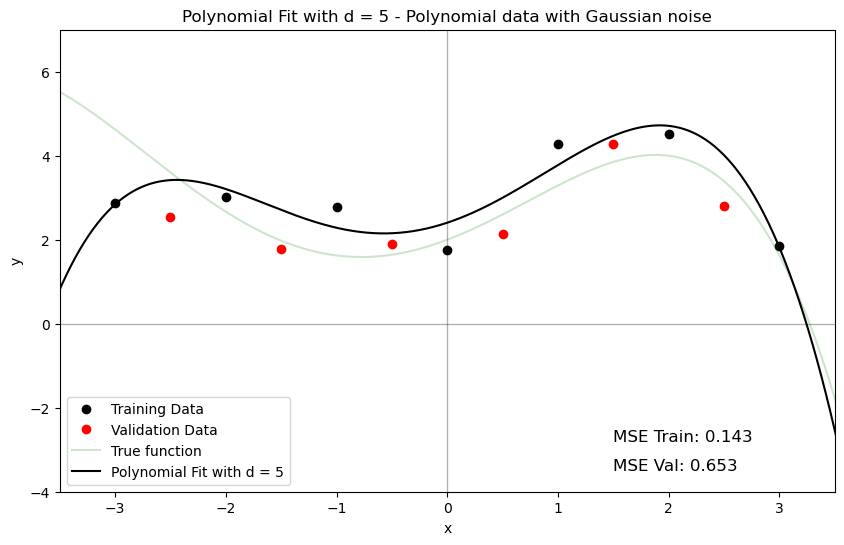

The polynomial is: 1.747563963 +0.8783320583 x +2.37160135 x**2 -0.1326321341 x**3 -0.6358676965 x**4 +0.0017759013 x**5 +0.04221401153 x**6 



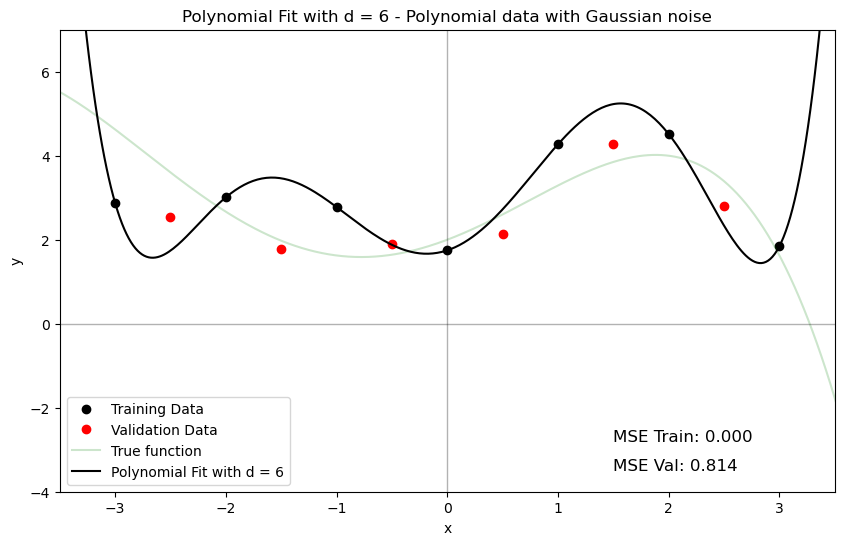

The polynomial is: 1.747563963 +0.5256930017 x +2.37160135 x**2 +0.347348804 x**3 -0.6358676965 x**4 -0.1353615096 x**5 +0.04221401153 x**6 +0.009795529349 x**7 



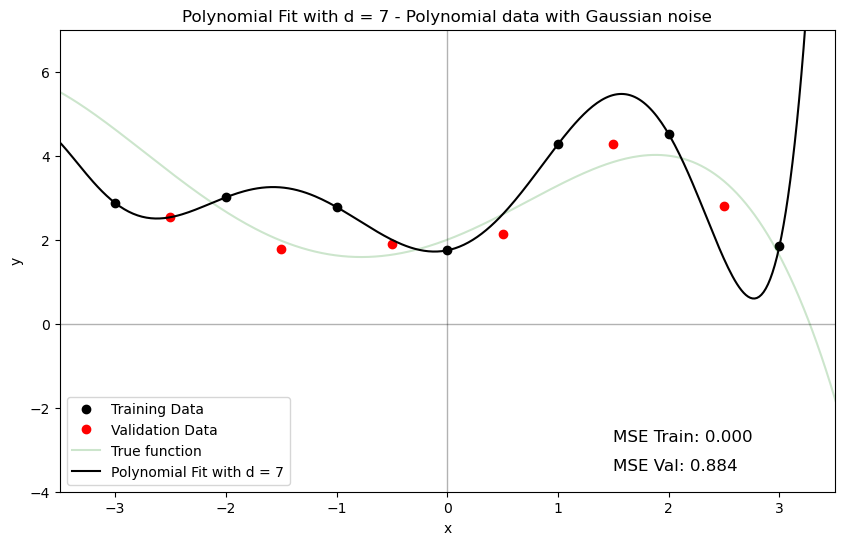

The polynomial is: 1.747563963 +0.5256930017 x +1.288770885 x**2 +0.347348804 x**3 +0.8379848798 x**4 -0.1353615096 x**5 -0.3788867245 x**6 +0.009795529349 x**7 +0.03007862401 x**8 



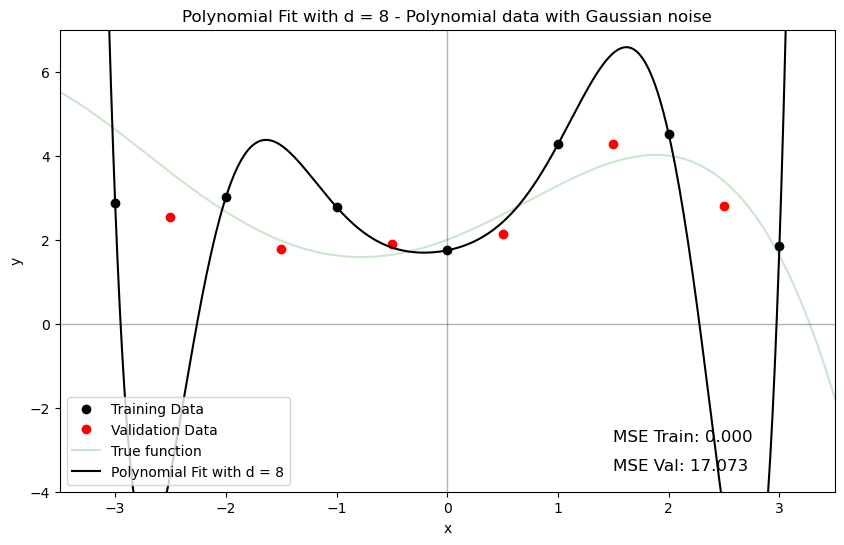

The polynomial is: 1.747563792 +0.3376454409 x +1.288771044 x**2 +0.3061201268 x**3 +0.8379849824 x**4 +0.1960070164 x**5 -0.3788867733 x**6 -0.1005518224 x**7 +0.03007862797 x**8 +0.008255063938 x**9 



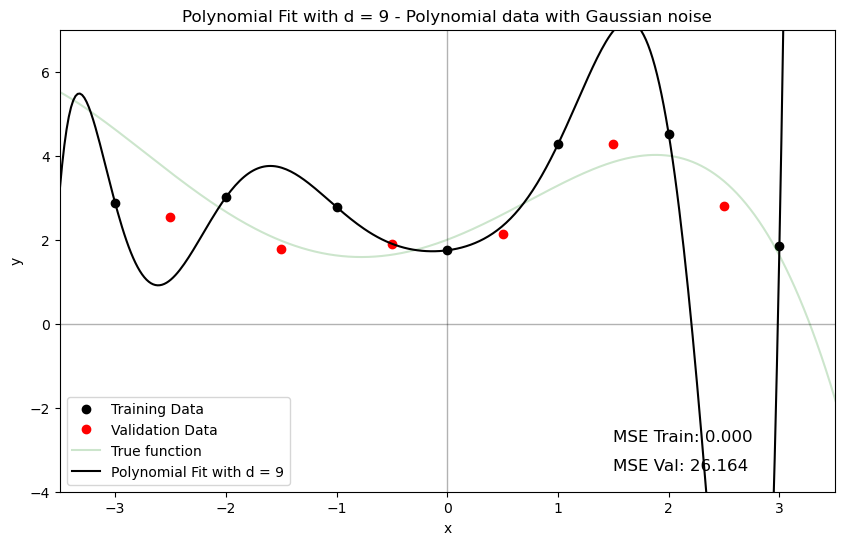

In [224]:
# Assuming polynomial_fits is a list of PolynomialTF objects and solutions is a list of tuples containing the degree,
# omega solutions, polynomial objects, MSE for training, and MSE for validation.

# Example preparation (ensure these are defined appropriately in your actual code)
# polynomial_fits = [PolynomialTF(omega_solution)(x) for d in range(8)]
# solutions = [(d, omega_hat, poly, MSE_train, MSE_val) for d, omega_hat, poly, MSE_train, MSE_val in ...]

def plot_polynomial_fits(x_train: tf.Tensor,
                         y_train: tf.Tensor,
                         x_val: tf.Tensor,
                         y_val: tf.Tensor,
                         polynomial_fits: List[PolynomialTF],
                         solutions: List[Tuple[int, tf.Tensor, PolynomialTF, tf.Tensor, tf.Tensor]],
                         dataset_name: str = "Dataset"
                        ) -> None:
    """Plots polynomial fits along with the training and validation data.
    
    Args:
        x_train: Training data x-values.
        y_train: Training data y-values.
        x_val: Validation data x-values.
        y_val: Validation data y-values.
        polynomial_fits: A list of polynomial fitting functions.
        solutions: A list of tuples containing information about each fit, including MSE for training and validation data.
    """
    for i in range(len(polynomial_fits)):
        print("The polynomial is:", polynomial_fits[i], "\n")
        plt.figure(figsize=(10, 6))
        plt.plot(x_train, y_train, 'o', label='Training Data', color='black')
        plt.plot(x_val, y_val, 'o', label='Validation Data', color='red')

        # Generate x values for plotting
        #x_values: np.ndarray = np.linspace(-4, 4, 400)
        x_values: tf.Tensor = tf.cast(tf.linspace(-4., 4., 400), dtype=tf.float64)
        
        # Generate y values for the original function and its polynomial fit
        y_values_func: tf.Tensor = y(x_values)
        y_values_fit: tf.Tensor = polynomial_fits[i](x_values)

        # Display MSE values as text on the plot
        mse_train: tf.Tensor = solutions[i][3]
        mse_val: tf.Tensor = solutions[i][4]
        plt.text(1.5, -2.8, f'MSE Train: {mse_train:.3f}', fontsize=12, color='black')
        plt.text(1.5, -3.5, f'MSE Val: {mse_val:.3f}', fontsize=12, color='black')
        
        # Plot the function and polynomial fit
        plt.plot(x_values, y_values_func, label='True function', color='green', alpha=0.2)
        plt.plot(x_values, y_values_fit, label=f'Polynomial Fit with d = {i}', color='black')
        
        # Draw axes
        plt.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
        plt.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
        
        # Finalizing plot
        plt.title(f'Polynomial Fit with d = {i} - '+dataset_name)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.legend(loc='lower left')
        plt.xlim(-3.5, 3.5)
        plt.ylim(-4, 7)
        plt.show()

plot_polynomial_fits(x_train, y_train, x_val, y_val, polynomial_fits, solutions, "Polynomial data with Gaussian noise")


### Probabilistic model (non-polynomial data)

In [ ]:
def y(x: tf.Tensor) -> tf.Tensor:
    """Computes the function 3 + sin(x) - cos(x) for given x values.
    
    Args:
        x: A tf tensor of x values.
    
    Returns:
        A tf tensor of y values computed from the function.
    """
    return 3. + tf.sin(x) - tf.cos(x)

def y_stat(x: tf.Tensor) -> tf.Tensor:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A tf tensor of x values.
    
    Returns:
        A tf tensor of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: tf.Tensor = y(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: tf.Tensor = true_y_values + tf.random.normal(tf.shape(true_y_values), mean=0.0, stddev=1.0, dtype=tf.float64)
    
    return noisy_y_values

def y_numpy(x: np.ndarray) -> np.ndarray:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression.
    """
    return 3 + np.sin(x) - np.cos(x)

def y_stat_numpy(x: np.ndarray) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y_numpy(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, 1)
    
    return noisy_y_values

In [229]:
# Generate data coordinates
x_train: tf.Tensor = tf.range(-3, 4, 1, dtype=tf.float64)
x_val: tf.Tensor = tf.range(-2.5, 3.5, 1, dtype=tf.float64)

# Generate target values
tf.random.set_seed(100)
y_train: tf.Tensor = y_stat(x_train)
y_val: tf.Tensor = y_stat(x_val)

# Notice that the instance of data generated by TensorFlow2 is different than the one generated by numpy. To reproduce the same results as with numpy, one would need to generate data with numpy and then convert it to TensorFlow2 tensors. Comment/uncomment the following lines to use different/same data

# Generate data coordinates
x_train = np.arange(-3., 4., 1)
x_val = np.arange(-2.5, 3.5, 1)

# Generate target values through the statistical model
np.random.seed(100)
y_train = y_stat_numpy(x_train)
y_val = y_stat_numpy(x_val)

# Convert the numpy arrays to TensorFlow tensors
x_train = tf.convert_to_tensor(x_train, dtype=tf.float64)
x_val = tf.convert_to_tensor(x_val, dtype=tf.float64)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float64)
y_val = tf.convert_to_tensor(y_val, dtype=tf.float64)

# Prepare a list to store solutions
solutions: List[Tuple[Any, tf.Tensor, PolynomialTF, tf.Tensor, tf.Tensor]] = []

# Perform the fit for each degree and print the results
show: bool = True
for d in range(10):
    # Generate the design matrix
    X_train: tf.Tensor = design_matrix(d, x_train)
    
    # Compute the weights of the solution
    omega_hat: tf.Tensor = omega_solution(X_train, y_train)
    
    # Define the fit polynomial
    poly: PolynomialTF = poly_solution(omega_hat)
    
    # Compute the MSE for the training and validation data
    MSE_train: tf.Tensor = MSE(omega_hat, x_train, y_train)
    MSE_val: tf.Tensor = MSE(omega_hat, x_val, y_val)
    
    # Store the results
    solutions.append((d, omega_hat, poly, MSE_train, MSE_val))
    
    # Print the results
    if show:
        print(f"===================================================")
        print(f"---------------------- d = {d} ----------------------")
        print(f"===================================================")
        print(f"The degree of the polynomial is: {d}\n")
        #print(f"The hypothesis is: {poly}\n")
        print(f"The design matrix is:\n{X_train}\n")
        print(f"The solution for omega is: {omega_hat}\n")  
        print(f"The polynomial is: {poly}\n")
        print(f"The MSE for the training data is: {MSE_train}")
        print(f"The MSE for the validation data is: {MSE_val}\n")
polynomial_fits = [sol[2] for sol in solutions]

---------------------- d = 0 ----------------------
The degree of the polynomial is: 0

The design matrix is:
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]

The solution for omega is: [3.27741544]

The polynomial is: 3.277415435

The MSE for the training data is: 1.253469248073597
The MSE for the validation data is: 1.3868841559961662

---------------------- d = 1 ----------------------
The degree of the polynomial is: 1

The design matrix is:
[[ 1. -3.]
 [ 1. -2.]
 [ 1. -1.]
 [ 1.  0.]
 [ 1.  1.]
 [ 1.  2.]
 [ 1.  3.]]

The solution for omega is: [3.27741544 0.43753746]

The polynomial is: 3.277415435 +0.4375374647 x

The MSE for the training data is: 0.4877131158807507
The MSE for the validation data is: 0.7404351140390489

---------------------- d = 2 ----------------------
The degree of the polynomial is: 2

The design matrix is:
[[ 1. -3.  9.]
 [ 1. -2.  4.]
 [ 1. -1.  1.]
 [ 1.  0.  0.]
 [ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]]

The solution for omega is: [3.08191619 0.43753746 

The polynomial is: 3.277415435 



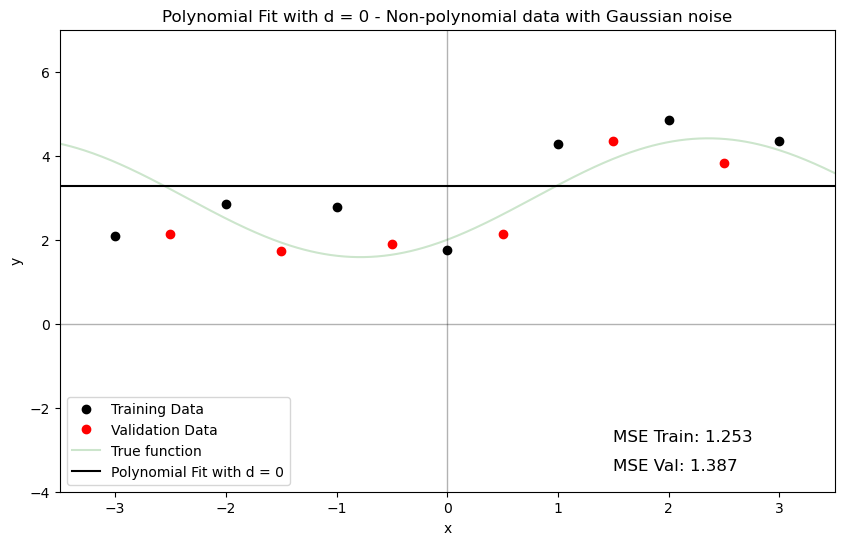

The polynomial is: 3.277415435 +0.4375374647 x 



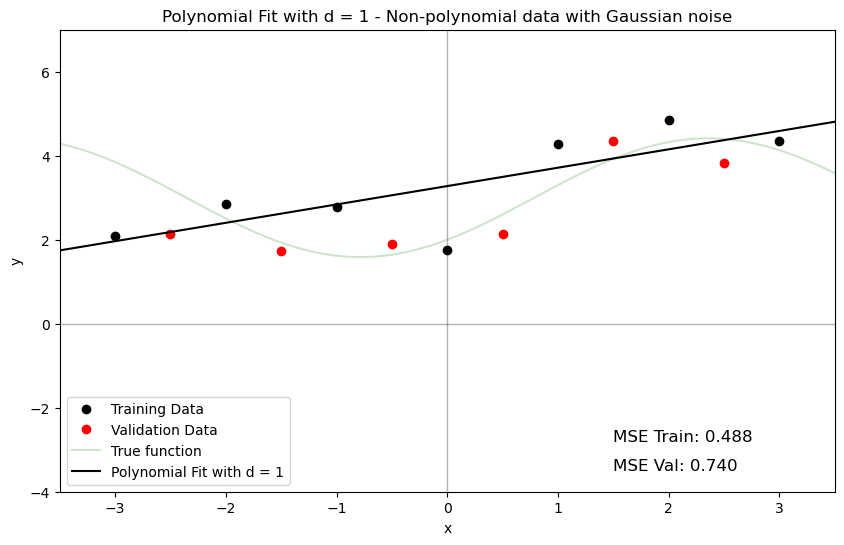

The polynomial is: 3.08191619 +0.4375374647 x +0.04887481142 x**2 



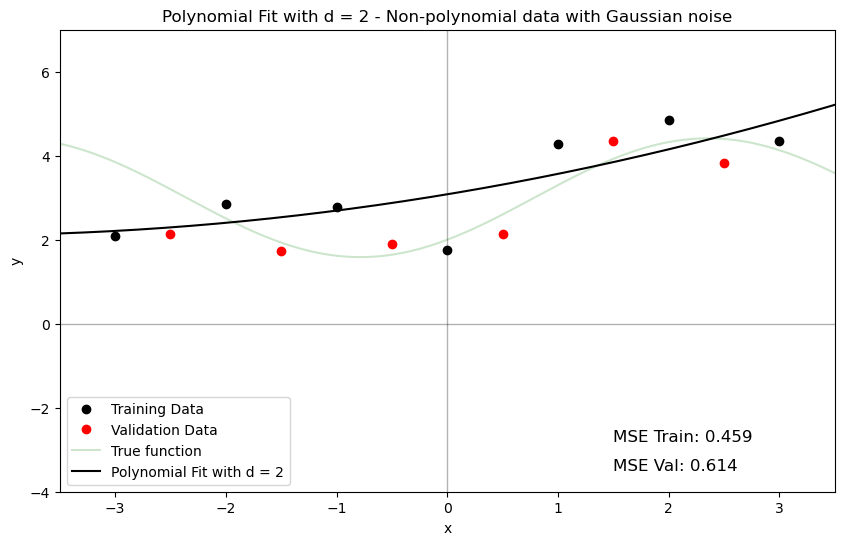

The polynomial is: 3.08191619 +0.6802381762 x +0.04887481142 x**2 -0.0346715302 x**3 



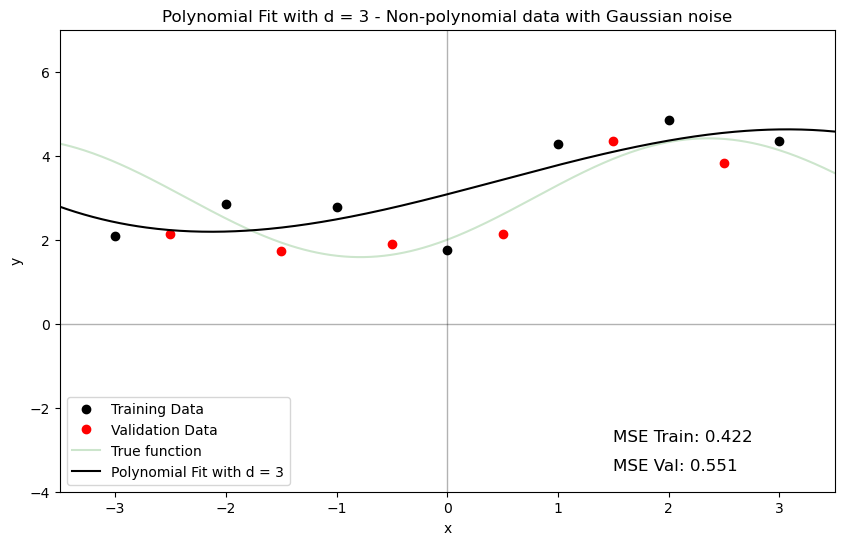

The polynomial is: 2.422266173 +0.6802381762 x +0.6627157993 x**2 -0.0346715302 x**3 -0.06413264052 x**4 



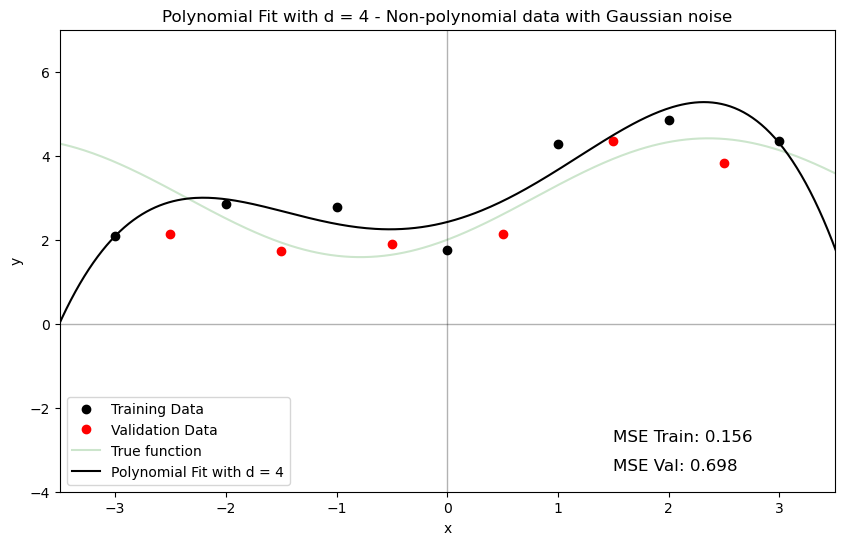

The polynomial is: 2.422266173 +0.8724533077 x +0.6627157993 x**2 -0.1245431089 x**3 -0.06413264052 x**4 +0.007703278173 x**5 



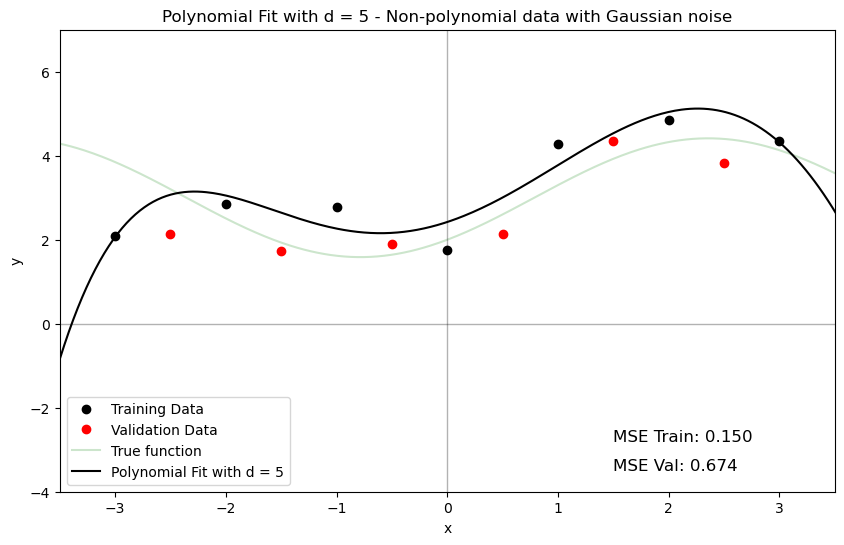

The polynomial is: 1.747563963 +0.8724533077 x +2.370836893 x**2 -0.1245431089 x**3 -0.6348182594 x**4 +0.007703278173 x**5 +0.04329339178 x**6 



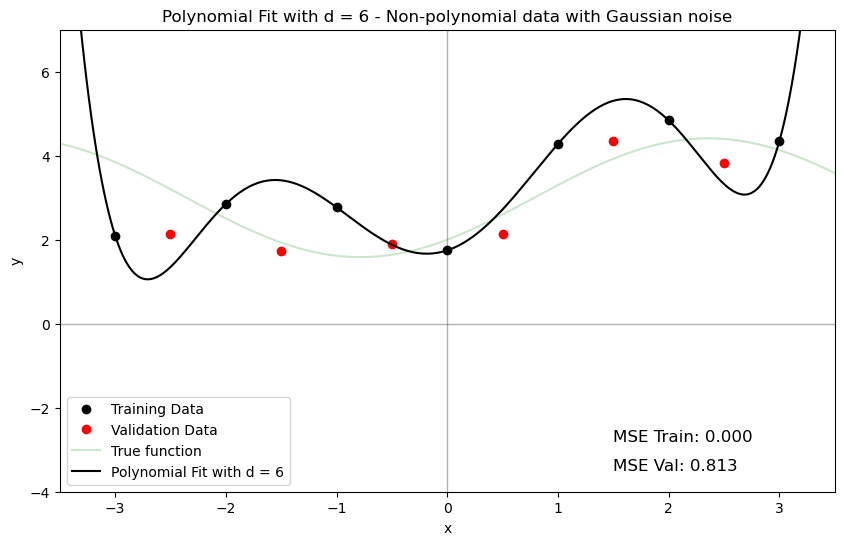

The polynomial is: 1.747563963 +0.5246680013 x +2.370836893 x**2 +0.3488313359 x**3 -0.6348182594 x**4 -0.1275465632 x**5 +0.04329339178 x**6 +0.009660702955 x**7 



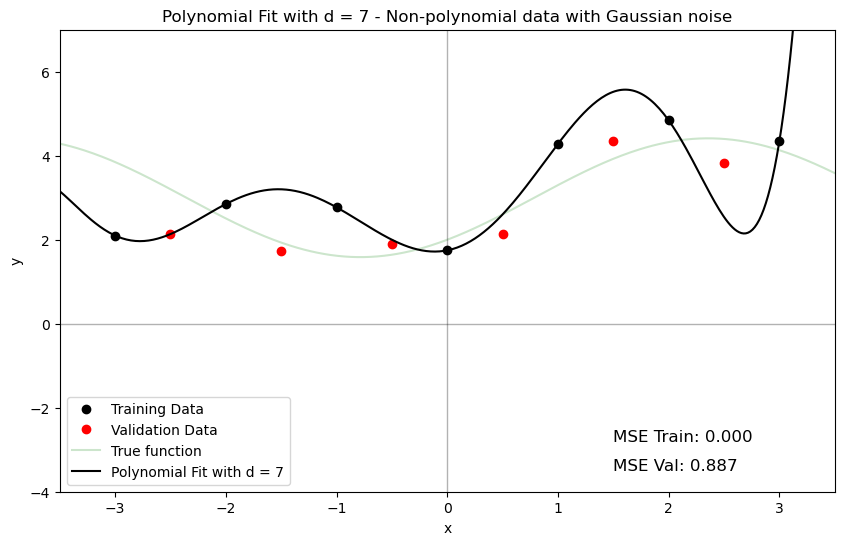

The polynomial is: 1.747563963 +0.5246680013 x +1.288596551 x**2 +0.3488313359 x**3 +0.8382310952 x**4 -0.1275465632 x**5 -0.3775778524 x**6 +0.009660702955 x**7 +0.03006223173 x**8 



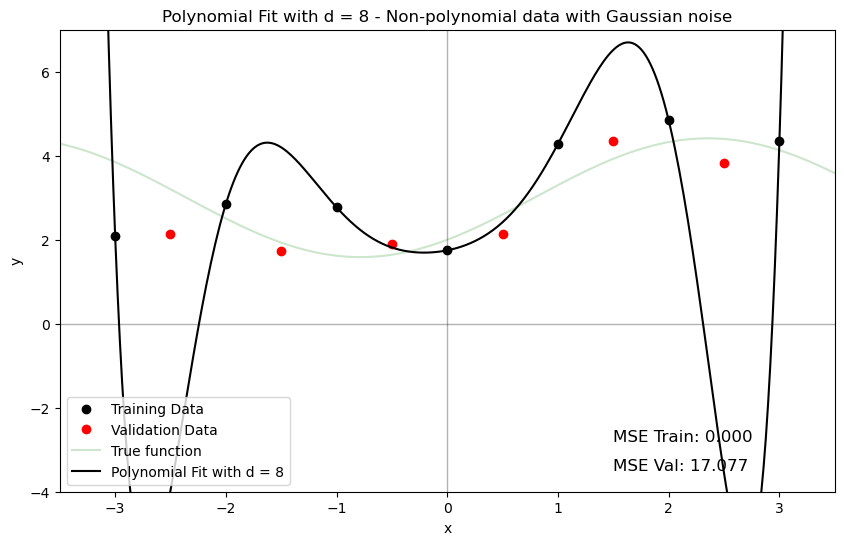

The polynomial is: 1.747563792 +0.3398541655 x +1.28859671 x**2 +0.30831164 x**3 +0.8382311979 x**4 +0.1981236452 x**5 -0.3775779012 x**6 -0.09878908101 x**7 +0.03006223569 x**8 +0.008113107259 x**9 



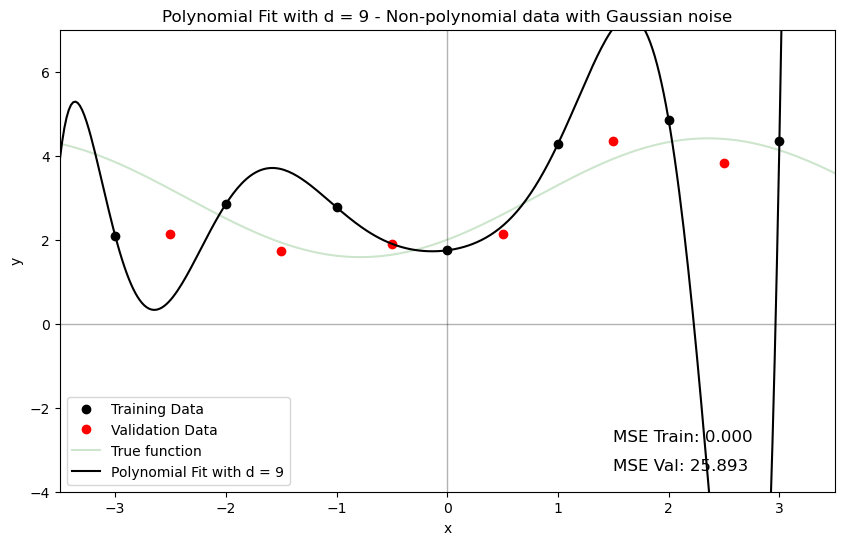

In [230]:
plot_polynomial_fits(x_train, y_train, x_val, y_val, polynomial_fits, solutions, "Non-polynomial data with Gaussian noise")

### Probabilistic model with non-polynomial fit (non-polynomial data)

In [ ]:
def y(x: tf.Tensor) -> tf.Tensor:
    """Computes the function 3 + sin(x) - cos(x) for given x values.
    
    Args:
        x: A tf tensor of x values.
    
    Returns:
        A tf tensor of y values computed from the function.
    """
    return 3. + tf.sin(x) - tf.cos(x)

def y_stat(x: tf.Tensor) -> tf.Tensor:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A tf tensor of x values.
    
    Returns:
        A tf tensor of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: tf.Tensor = y(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: tf.Tensor = true_y_values + tf.random.normal(tf.shape(true_y_values), mean=0.0, stddev=1.0, dtype=tf.float64)
    
    return noisy_y_values

def y_numpy(x: np.ndarray) -> np.ndarray:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression.
    """
    return 3 + np.sin(x) - np.cos(x)

def y_stat_numpy(x: np.ndarray) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y_numpy(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, 1)
    
    return noisy_y_values
    

def design_matrix_trig_tf(x_values: tf.Tensor) -> tf.Tensor:
    """Generates a design matrix for trigonometric regression with TensorFlow.
    
    Args:
        x_values: A tf.Tensor of x values.
    
    Returns:
        A tf.Tensor representing the design matrix with columns for 1, sin(x), and cos(x).
    """
    ones = tf.ones_like(x_values)
    sin_x = tf.sin(x_values)
    cos_x = tf.cos(x_values)
    # Stack along the second dimension (axis=1) to form the design matrix
    return tf.stack([ones, sin_x, cos_x], axis=1)

def omega_solution(X: tf.Tensor, 
                   Y: tf.Tensor
                  ) -> tf.Tensor:
    """Calculates the polynomial coefficients (omega) that best fit the data.
    
    Args:
        X: The design matrix.
        Y: A tf tensor of target y values.
    
    Returns:
        A tf tensor of calculated omega values.
    """
    XT: tf.Tensor = tf.transpose(X)
    Y: tf.Tensor = tf.reshape(Y, (-1, 1))
    omega: tf.Tensor = tf.linalg.pinv(XT @ X) @ XT @ Y
    return tf.reshape(omega, [-1])

def trig_solution(omega_solution: tf.Tensor, 
                  x_values: tf.Tensor
                 ) -> tf.Tensor:
    """Evaluates the trigonometric model at given x values using the omega coefficients.
    
    Args:
        omega_solution: A tf.Tensor of omega coefficients for [constant, sin(x), cos(x)].
        x_values: A tf.Tensor of x values for evaluation.
    
    Returns:
        A tf.Tensor of y values predicted by the trigonometric model.
    """
    return omega_solution[0] + omega_solution[1] * tf.sin(x_values) + omega_solution[2] * tf.cos(x_values)

def MSE(omega_solution: tf.Tensor, 
        x_values: tf.Tensor,
        y_true: tf.Tensor
       ) -> tf.Tensor:
    """
    Calculates the Mean Squared Error (MSE) for given omega coefficients and x values.
    Uses tensorflow MSE loss function.
    
    Args:
        omega_solution: A 1D tf.Tensor of omega coefficients.
        x_values: A 1D tf.Tensor of x values for evaluation.
    
    Returns:
        The MSE as a tf.Tensor.
    """
    y_pred: tf.Tensor = trig_solution(omega_solution, x_values)
    loss: tf.Tensor = tf.losses.MSE(y_true, y_pred)
    return loss


In [237]:
# Generate data coordinates
x_train: tf.Tensor = tf.range(-3, 4, 1, dtype=tf.float64)
x_val: tf.Tensor = tf.range(-2.5, 3.5, 1, dtype=tf.float64)

# Generate target values
tf.random.set_seed(100)
y_train: tf.Tensor = y_stat(x_train)
y_val: tf.Tensor = y_stat(x_val)

# Notice that the instance of data generated by TensorFlow2 is different than the one generated by numpy. To reproduce the same results as with numpy, one would need to generate data with numpy and then convert it to TensorFlow2 tensors. Comment/uncomment the following lines to use different/same data

# Generate data coordinates
x_train = np.arange(-3., 4., 1)
x_val = np.arange(-2.5, 3.5, 1)

# Generate target values through the statistical model
np.random.seed(100)
y_train = y_stat_numpy(x_train)
y_val = y_stat_numpy(x_val)

# Convert the numpy arrays to TensorFlow tensors
x_train = tf.convert_to_tensor(x_train, dtype=tf.float64)
x_val = tf.convert_to_tensor(x_val, dtype=tf.float64)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float64)
y_val = tf.convert_to_tensor(y_val, dtype=tf.float64)

# Flag to control printing of the solution details
show: bool = True

# Generate the design matrix
X_train: tf.Tensor = design_matrix_trig_tf(x_train)

# Compute the weights of the solution
omega_hat: tf.Tensor = omega_solution(X_train, y_train)

# Compute the MSE for the training and validation data
MSE_train: tf.Tensor = MSE(omega_hat, x_train, y_train)
MSE_val: tf.Tensor = MSE(omega_hat, x_val, y_val)

# Print the results
if show:
    print("----------------- Trigonometric Model -----------------")
    print(f"The design matrix is:\n{X_train}\n")
    print(f"The target values are:\n{y_train}\n")
    print(f"The solution for omega is: {omega_hat}\n")
    print(f"The MSE for the training data is: {MSE_train}")
    print(f"The MSE for the validation data is: {MSE_val}\n")

----------------- Trigonometric Model -----------------
The design matrix is:
[[ 1.         -0.14112001 -0.9899925 ]
 [ 1.         -0.90929743 -0.41614684]
 [ 1.         -0.84147098  0.54030231]
 [ 1.          0.          1.        ]
 [ 1.          0.84147098  0.54030231]
 [ 1.          0.90929743 -0.41614684]
 [ 1.          0.14112001 -0.9899925 ]]

The target values are:
[2.09910702 2.84952981 2.77126251 1.74756396 4.28248947 4.8396631
 4.35229217]

The solution for omega is: [ 3.23274463  1.09313872 -0.42737018]

The MSE for the training data is: 0.6231208529025821
The MSE for the validation data is: 0.4426790841588102



Fit with true function



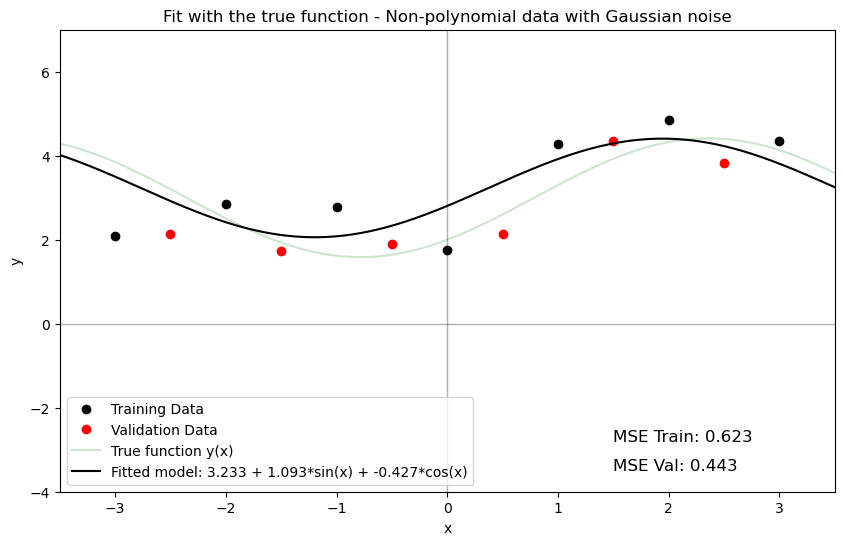

In [238]:
print("Fit with true function\n")
omega_hat_str = f"{omega_hat[0]:.3f} + {omega_hat[1]:.3f}*sin(x) + {omega_hat[2]:.3f}*cos(x)"
plt.figure(figsize=(10, 6))
plt.plot(x_train, y_train, 'o', label='Training Data', color='black')
plt.plot(x_val, y_val, 'o', label='Validation Data', color='red')

# Generate x values for plotting
x_values: tf.Tensor = tf.cast(tf.linspace(-4., 4., 400), dtype=tf.float64)

# Generate y values for the function and the model fit
y_values_func: tf.Tensor = y(x_values)
y_values_fit: tf.Tensor = trig_solution(omega_hat, x_values)  # Use trig_solution instead of poly_solution

plt.text(1.5, -2.8, f'MSE Train: {MSE_train:.3f}', fontsize=12, color='black')
plt.text(1.5, -3.5, f'MSE Val: {MSE_val:.3f}', fontsize=12, color='black')
    
plt.plot(x_values, y_values_func, label='True function y(x)', color='green', alpha=0.2)
plt.plot(x_values, y_values_fit, label='Fitted model: ' + omega_hat_str, color='black')

# Drawing axes
plt.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Finalizing plot
plt.title(f'Fit with the true function - Non-polynomial data with Gaussian noise')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='lower left')
plt.xlim(-3.5, 3.5)
plt.ylim(-4, 7)
plt.show()


## PyTorch

### Deterministic solution (polynomial data)

In [275]:
class PolynomialTorch:
    def __init__(self, coefficients):
        """
        Initializes the polynomial with given coefficients.

        Args:
            coefficients: A 1D torch.Tensor or a Python list of polynomial coefficients
                          from the lowest to the highest degree.
        """
        self.coefficients = torch.tensor(coefficients, dtype=torch.float64)

    def __call__(self, x):
        """
        Evaluates the polynomial at given x values.

        Args:
            x: A 1D torch.Tensor or a list of x values where the polynomial is to be evaluated.

        Returns:
            A torch.Tensor containing the evaluated polynomial values at each x value.
        """
        x = torch.tensor(x, dtype=torch.float64)
        degree = self.coefficients.shape[0]
        x_powers = torch.pow(x.unsqueeze(-1), torch.arange(0, degree, dtype=torch.float64))
        poly_values = torch.sum(x_powers * self.coefficients, dim=1)
        return poly_values

    def __str__(self):
        """
        Returns a string representation of the polynomial.
        """
        terms = []
        for i, coeff in enumerate(self.coefficients.numpy()):
            if coeff != 0:  # Skip terms with a coefficient of zero
                if i == 0:
                    terms.append(f"{coeff:.10g}")
                elif i == 1:
                    terms.append(f"{coeff:+.10g} x")
                else:
                    terms.append(f"{coeff:+.10g} x**{i}")
        return " ".join(terms)

In [276]:
import torch

def y(x: torch.Tensor) -> torch.Tensor:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A torch tensor of x values.
    
    Returns:
        A torch tensor of y values computed from the polynomial expression.
    """
    return (-torch.pow(x, 4)/24 - torch.pow(x, 3)/6 + torch.pow(x, 2)/2 + x + 2).to(torch.float64)

def design_matrix(degree: int, x_values: torch.Tensor) -> torch.Tensor:
    """Generates a design matrix for polynomial regression of a specified degree.
    
    Args:
        degree: The degree of the polynomial hypothesis.
        x_values: A torch tensor of x values.
    
    Returns:
        A design matrix as a torch tensor.
    """
    return torch.stack([x_values**i for i in range(degree + 1)], dim=1)

def omega_solution(X: torch.Tensor, Y: torch.Tensor) -> torch.Tensor:
    """Calculates the polynomial coefficients (omega) that best fit the data.
    
    Args:
        X: The design matrix.
        Y: A torch tensor of target y values.
    
    Returns:
        A torch tensor of calculated omega values.
    """
    XT: torch.Tensor = X.T
    Y: torch.Tensor = Y.view(-1, 1)  # Reshape to column vector
    omega: torch.Tensor = torch.linalg.pinv(XT @ X) @ XT @ Y
    return omega.view(-1)  # Flatten

def poly_solution(omega_solution: torch.Tensor) -> PolynomialTorch:
    """Converts omega coefficients to a torch PolynomialTorch object.
    
    Args:
        omega_solution: A torch.Tensor of omega coefficients.
    
    Returns:
        A torch PolynomialTorch object representing the fitted polynomial.
    """
    return PolynomialTorch(omega_solution)

def MSE(omega_solution: torch.Tensor, 
        x_values: torch.Tensor, 
        y_true: torch.Tensor
       ) -> torch.Tensor:
    """
    Calculates the Mean Squared Error (MSE) for given omega coefficients and x values.
    Uses PyTorch's MSE loss function.
    
    Args:
        omega_solution: A 1D torch.Tensor of omega coefficients.
        x_values: A 1D torch.Tensor of x values for evaluation.
        y_true: A 1D torch.Tensor of true y values.
    
    Returns:
        The MSE as a torch.Tensor.
    """
    poly: PolynomialTorch = poly_solution(omega_solution)
    y_pred: torch.Tensor = poly(x_values)
    loss: torch.Tensor = F.mse_loss(y_pred, y_true)
    return loss

In [277]:
# Generate data coordinates
x_train: torch.Tensor = torch.arange(-3, 4, 1, dtype=torch.float64)
x_val: torch.Tensor = torch.arange(-2.5, 3.5, 1, dtype=torch.float64)

# Generate target values
y_train: torch.Tensor = y(x_train)
y_val: torch.Tensor = y(x_val)

# Perform the fit for each degree and print the results
show: bool = True
for d in range(8):
    # Generate the design matrix
    X_train: torch.Tensor = design_matrix(d, x_train)
    
    # Compute the weights of the solution
    omega_hat: torch.Tensor = omega_solution(X_train, y_train)
    
    # Define the fit polynomial
    poly: PolynomialTorch = poly_solution(omega_hat)
    
    # Compute the MSE for the training and validation data
    MSE_train: torch.Tensor = MSE(omega_hat, x_train, y_train)
    MSE_val: torch.Tensor = MSE(omega_hat, x_val, y_val)
    
    # Print the results
    if show:
        print(f"===================================================")
        print(f"---------------------- d = {d} ----------------------")
        print(f"===================================================")
        print(f"The degree of the polynomial is: {d}\n")
        print(f"The design matrix is:\n{X_train}\n")
        print(f"The solution for omega is: {omega_hat}\n")  
        print(f"The polynomial is: {poly}\n")
        print(f"The MSE for the training data is: {MSE_train}")
        print(f"The MSE for the validation data is: {MSE_val}\n")

---------------------- d = 0 ----------------------
The degree of the polynomial is: 0

The design matrix is:
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]], dtype=torch.float64)

The solution for omega is: tensor([2.8333], dtype=torch.float64)

The polynomial is: 2.833333333

The MSE for the training data is: 1.2033730158730158
The MSE for the validation data is: 0.6907619900173613

---------------------- d = 1 ----------------------
The degree of the polynomial is: 1

The design matrix is:
tensor([[ 1., -3.],
        [ 1., -2.],
        [ 1., -1.],
        [ 1.,  0.],
        [ 1.,  1.],
        [ 1.,  2.],
        [ 1.,  3.]], dtype=torch.float64)

The solution for omega is: tensor([ 2.8333, -0.1667], dtype=torch.float64)

The polynomial is: 2.833333333 -0.1666666667 x

The MSE for the training data is: 1.0922619047619049
The MSE for the validation data is: 0.925715693721065

---------------------- d = 2 ----------------------
The d

/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_86164/1536676131.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.coefficients = torch.tensor(coefficients, dtype=torch.float64)
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_86164/1536676131.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float64)


### Deterministic solution (non-polynomial data)

In [253]:
def y(x: torch.Tensor) -> torch.Tensor:
    """Computes the function 3 + sin(x) - cos(x) for given x values.
    
    Args:
        x: A torch tensor of x values.
    
    Returns:
        A torch tensor of y values computed from the function.
    """
    return 3. + torch.sin(x) - torch.cos(x)

In [254]:
# Generate data coordinates
x_train = torch.arange(-3, 4, 1, dtype=torch.float64)
x_val = torch.arange(-2.5, 3.5, 1, dtype=torch.float64)

# Generate target values
y_train = y(x_train)
y_val = y(x_val)

# Perform the fit for each degree and print the results
show = True
for d in range(10):
    # Generate the design matrix
    X_train = design_matrix(d, x_train)

    # Compute the weights of the solution
    omega_hat = omega_solution(X_train, y_train)

    # Define the fit polynomial
    poly = poly_solution(omega_hat)

    # Compute the MSE for the training and validation data
    MSE_train = MSE(omega_hat, x_train, y_train)
    MSE_val = MSE(omega_hat, x_val, y_val)

    # Print the results
    if show:
        print(f"===================================================")
        print(f"---------------------- d = {d} ----------------------")
        print(f"===================================================")
        print(f"The degree of the polynomial is: {d}\n")
        print(f"The design matrix is:\n{X_train}\n")
        print(f"The solution for omega is: {omega_hat}\n")  
        print(f"The polynomial is: {poly}\n")
        print(f"The MSE for the training data is: {MSE_train}")
        print(f"The MSE for the validation data is: {MSE_val}\n")

---------------------- d = 0 ----------------------
The degree of the polynomial is: 0

The design matrix is:
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]], dtype=torch.float64)

The solution for omega is: tensor([3.1045], dtype=torch.float64)

The polynomial is: 3.104524865

The MSE for the training data is: 0.989074552609905
The MSE for the validation data is: 1.0211811587186352

---------------------- d = 1 ----------------------
The degree of the polynomial is: 1

The design matrix is:
tensor([[ 1., -3.],
        [ 1., -2.],
        [ 1., -1.],
        [ 1.,  0.],
        [ 1.,  1.],
        [ 1.,  2.],
        [ 1.,  3.]], dtype=torch.float64)

The solution for omega is: tensor([3.1045, 0.2202], dtype=torch.float64)

The polynomial is: 3.104524865 +0.2202447045 x

The MSE for the training data is: 0.7950436332141865
The MSE for the validation data is: 0.6880882026927809

---------------------- d = 2 ----------------------
The deg

/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_86164/1536676131.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.coefficients = torch.tensor(coefficients, dtype=torch.float64)
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_86164/1536676131.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float64)


### Deterministic model with non-polynomial fit (non-polynomial data)

In [255]:
def y(x: torch.Tensor) -> torch.Tensor:
    """Computes the function 3 + sin(x) - cos(x) for given x values.
    
    Args:
        x: A torch tensor of x values.
    
    Returns:
        A torch tensor of y values computed from the function.
    """
    return (3 + torch.sin(x) - torch.cos(x)).double()

def design_matrix_trig_torch(x_values: torch.Tensor) -> torch.Tensor:
    """Generates a design matrix for trigonometric regression with PyTorch.
    
    Args:
        x_values: A torch.Tensor of x values.
    
    Returns:
        A torch.Tensor representing the design matrix with columns for 1, sin(x), and cos(x).
    """
    ones = torch.ones_like(x_values)
    sin_x = torch.sin(x_values)
    cos_x = torch.cos(x_values)
    # Stack along the second dimension (axis=1) to form the design matrix
    return torch.stack([ones, sin_x, cos_x], dim=1)

def omega_solution(X: torch.Tensor, 
                   Y: torch.Tensor
                  ) -> torch.Tensor:
    """Calculates the polynomial coefficients (omega) that best fit the data.
    
    Args:
        X: The design matrix.
        Y: A torch tensor of target y values.
    
    Returns:
        A torch tensor of calculated omega values.
    """
    XT: torch.Tensor = X.t()  # Transpose of X
    Y: torch.Tensor = Y.view(-1, 1)  # Reshape Y to be a column vector
    omega: torch.Tensor = torch.linalg.pinv(XT @ X) @ XT @ Y
    return omega.view(-1)  # Flatten the omega tensor

def trig_solution(omega_solution: torch.Tensor, 
                  x_values: torch.Tensor
                 ) -> torch.Tensor:
    """Evaluates the trigonometric model at given x values using the omega coefficients.
    
    Args:
        omega_solution: A torch.Tensor of omega coefficients for [constant, sin(x), cos(x)].
        x_values: A torch.Tensor of x values for evaluation.
    
    Returns:
        A torch.Tensor of y values predicted by the trigonometric model.
    """
    return omega_solution[0] + omega_solution[1] * torch.sin(x_values) + omega_solution[2] * torch.cos(x_values)

def MSE(omega_solution: torch.Tensor, 
        x_values: torch.Tensor, 
        y_true: torch.Tensor
       ) -> torch.Tensor:
    """
    Calculates the Mean Squared Error (MSE) for given omega coefficients and x values.
    Uses PyTorch's MSE loss function.
    
    Args:
        omega_solution: A 1D torch.Tensor of omega coefficients.
        x_values: A 1D torch.Tensor of x values for evaluation.
        y_true: A 1D torch.Tensor of true y values.
    
    Returns:
        The MSE as a torch.Tensor.
    """
    y_pred: torch.Tensor = trig_solution(omega_solution, x_values)
    loss: torch.Tensor = F.mse_loss(y_pred, y_true)
    return loss

In [256]:
# Generate data coordinates
x_train = torch.arange(-3, 4, 1, dtype=torch.float64)
x_val = torch.arange(-2.5, 3.5, 1, dtype=torch.float64)

# Generate target values through the statistical model with torch
torch.manual_seed(100)
y_train = y(x_train)
y_val = y(x_val)

# Flag to control printing of the solution details
show = True

# Generate the design matrix
X_train = design_matrix_trig_torch(x_train)

# Compute the weights of the solution
omega_hat = omega_solution(X_train, y_train)

# Compute the MSE for the training and validation data
MSE_train = MSE(omega_hat, x_train, y_train)
MSE_val = MSE(omega_hat, x_val, y_val)

# Print the results
if show:
    print("----------------- Trigonometric Model -----------------")
    print(f"The design matrix is:\n{X_train}\n")
    print(f"The target values are:\n{y_train}\n")
    print(f"The solution for omega is: {omega_hat}\n")
    print(f"The MSE for the training data is: {MSE_train}")
    print(f"The MSE for the validation data is: {MSE_val}\n")

----------------- Trigonometric Model -----------------
The design matrix is:
tensor([[ 1.0000, -0.1411, -0.9900],
        [ 1.0000, -0.9093, -0.4161],
        [ 1.0000, -0.8415,  0.5403],
        [ 1.0000,  0.0000,  1.0000],
        [ 1.0000,  0.8415,  0.5403],
        [ 1.0000,  0.9093, -0.4161],
        [ 1.0000,  0.1411, -0.9900]], dtype=torch.float64)

The target values are:
tensor([3.8489, 2.5068, 1.6182, 2.0000, 3.3012, 4.3254, 4.1311],
       dtype=torch.float64)

The solution for omega is: tensor([ 3.0000,  1.0000, -1.0000], dtype=torch.float64)

The MSE for the training data is: 2.3243223100261956e-31
The MSE for the validation data is: 1.0682491424867867e-31



### Probabilistic model (polynomial data)

In [278]:
def y(x: torch.Tensor) -> torch.Tensor:
    """Generates polynomial data based on a given polynomial expression.

    Args:
        x: A torch tensor of x values.

    Returns:
        A torch tensor of y values computed from the polynomial expression.
    """
    return (-torch.pow(x, 4) / 24 - torch.pow(x, 3) / 6 + torch.pow(x, 2) / 2 + x + 2).double()

def y_stat(x: torch.Tensor) -> torch.Tensor:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.

    Args:
        x: A torch tensor of x values.

    Returns:
        A torch tensor of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values = y(x)

    # Add Gaussian noise with mean 0 and standard deviation 1
    noisy_y_values = torch.normal(mean=true_y_values, std=1.0)

    return noisy_y_values

def y_numpy(x: np.ndarray) -> np.ndarray:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression.
    """
    return -x**4/24 - x**3/6 + x**2/2 + x + 2

def y_stat_numpy(x: np.ndarray) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y_numpy(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, 1)
    
    return noisy_y_values

def omega_solution(X: torch.Tensor, Y: torch.Tensor) -> torch.Tensor:
    """Calculates the polynomial coefficients (omega) that best fit the data.
    
    Args:
        X: The design matrix.
        Y: A torch tensor of target y values.
    
    Returns:
        A torch tensor of calculated omega values.
    """
    XT: torch.Tensor = X.T
    Y: torch.Tensor = Y.view(-1, 1)  # Reshape to column vector
    omega: torch.Tensor = torch.linalg.pinv(XT @ X) @ XT @ Y
    return omega.view(-1)  # Flatten

def poly_solution(omega_solution: torch.Tensor) -> PolynomialTorch:
    """Converts omega coefficients to a torch PolynomialTorch object.
    
    Args:
        omega_solution: A torch.Tensor of omega coefficients.
    
    Returns:
        A torch PolynomialTorch object representing the fitted polynomial.
    """
    return PolynomialTorch(omega_solution)

def MSE(omega_solution: torch.Tensor, 
        x_values: torch.Tensor, 
        y_true: torch.Tensor
       ) -> torch.Tensor:
    """
    Calculates the Mean Squared Error (MSE) for given omega coefficients and x values.
    Uses PyTorch's MSE loss function.
    
    Args:
        omega_solution: A 1D torch.Tensor of omega coefficients.
        x_values: A 1D torch.Tensor of x values for evaluation.
        y_true: A 1D torch.Tensor of true y values.
    
    Returns:
        The MSE as a torch.Tensor.
    """
    poly: PolynomialTorch = poly_solution(omega_solution)
    y_pred: torch.Tensor = poly(x_values)
    loss: torch.Tensor = F.mse_loss(y_pred, y_true)
    return loss

In [279]:
# Generate data coordinates
x_train: torch.Tensor = torch.arange(-3., 4., 1, dtype=torch.float64)
x_val: torch.Tensor = torch.arange(-2.5, 3.5, 1, dtype=torch.float64)

# Generate target values with noise
torch.manual_seed(100)
y_train: torch.Tensor = y_stat(x_train)
y_val: torch.Tensor = y_stat(x_val)

# Notice that the instance of data generated by TensorFlow2 is different than the one generated by numpy. To reproduce the same results as with numpy, one would need to generate data with numpy and then convert it to TensorFlow2 tensors. Comment/uncomment the following lines to use different/same data

# Generate data coordinates
x_train = np.arange(-3., 4., 1)
x_val = np.arange(-2.5, 3.5, 1)

# Generate target values through the statistical model
np.random.seed(100)
y_train = y_stat_numpy(x_train)
y_val = y_stat_numpy(x_val)

# Convert the numpy arrays to PyTorch tensors
x_train = torch.tensor(x_train, dtype=torch.float64)
x_val = torch.tensor(x_val, dtype=torch.float64)
y_train = torch.tensor(y_train, dtype=torch.float64)
y_val = torch.tensor(y_val, dtype=torch.float64)

# Prepare a list to store solutions
solutions: List[Tuple[Any, torch.Tensor, Any, torch.Tensor, torch.Tensor]] = []

# Perform the fit for each degree and print the results
show: bool = True
for d in range(10):
    # Generate the design matrix
    X_train: torch.Tensor = design_matrix(d, x_train)
    
    # Compute the weights of the solution
    omega_hat: torch.Tensor = omega_solution(X_train, y_train)
    
    # Define the fit polynomial
    poly = poly_solution(omega_hat)  # Assuming `poly_solution` is adapted for PyTorch
    
    # Compute the MSE for the training and validation data
    MSE_train: torch.Tensor = MSE(omega_hat, x_train, y_train)
    MSE_val: torch.Tensor = MSE(omega_hat, x_val, y_val)
    
    # Store the results
    solutions.append((d, omega_hat, poly, MSE_train, MSE_val))
    
    # Print the results
    if show:
        print(f"===================================================")
        print(f"---------------------- d = {d} ----------------------")
        print(f"===================================================")
        print(f"The degree of the polynomial is: {d}\n")
        # print(f"The hypothesis is: {poly}\n")
        print(f"The design matrix is:\n{X_train}\n")
        print(f"The solution for omega is: {omega_hat}\n")  
        print(f"The polynomial is: {poly}\n")
        print(f"The MSE for the training data is: {MSE_train}")
        print(f"The MSE for the validation data is: {MSE_val}\n")

# Extract polynomial fits
polynomial_fits = [sol[2] for sol in solutions]

---------------------- d = 0 ----------------------
The degree of the polynomial is: 0

The design matrix is:
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]], dtype=torch.float64)

The solution for omega is: tensor([3.0062], dtype=torch.float64)

The polynomial is: 3.006223904

The MSE for the training data is: 0.9825576964383046
The MSE for the validation data is: 0.8936504124278191

---------------------- d = 1 ----------------------
The degree of the polynomial is: 1

The design matrix is:
tensor([[ 1., -3.],
        [ 1., -2.],
        [ 1., -1.],
        [ 1.,  0.],
        [ 1.,  1.],
        [ 1.,  2.],
        [ 1.,  3.]], dtype=torch.float64)

The solution for omega is: tensor([3.0062, 0.0506], dtype=torch.float64)

The polynomial is: 3.006223904 +0.0506260936 x

The MSE for the training data is: 0.9723056910272134
The MSE for the validation data is: 0.8240488071089421

---------------------- d = 2 ----------------------
The de

/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_86164/1536676131.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.coefficients = torch.tensor(coefficients, dtype=torch.float64)
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_86164/1536676131.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float64)


The polynomial is: 3.006223904 



/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_86164/1536676131.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float64)


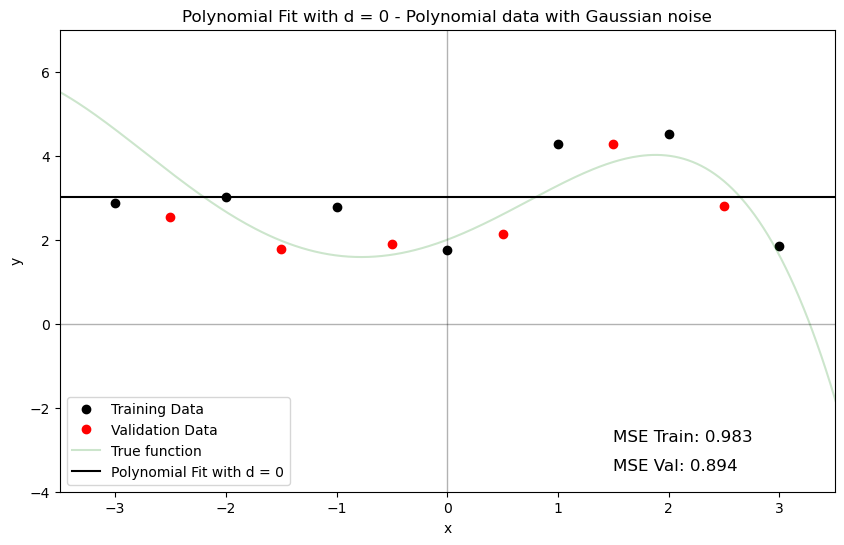

The polynomial is: 3.006223904 +0.0506260936 x 



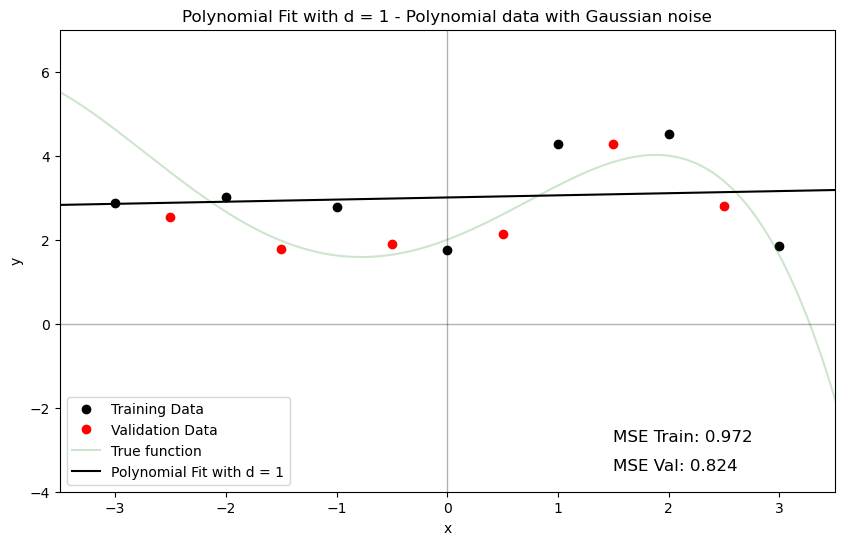

The polynomial is: 3.22223603 +0.0506260936 x -0.05400303145 x**2 



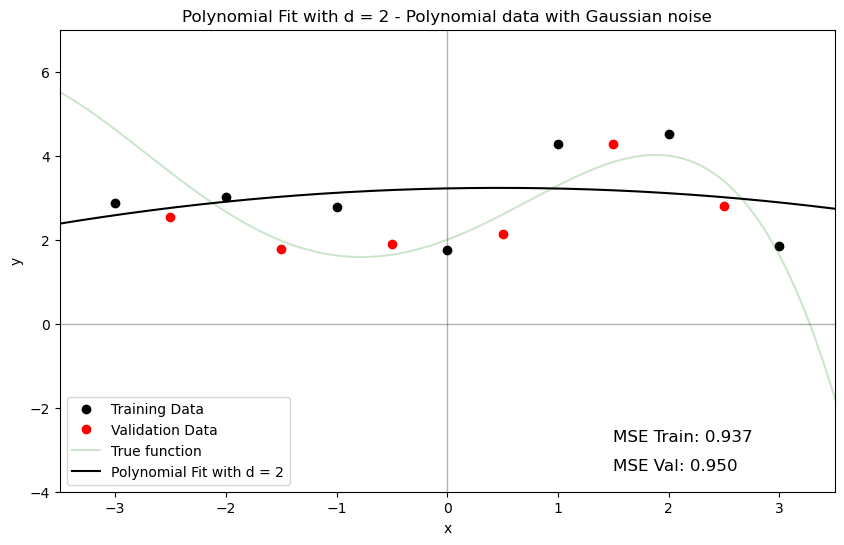

The polynomial is: 3.22223603 +0.8340190925 x -0.05400303145 x**2 -0.1119132856 x**3 



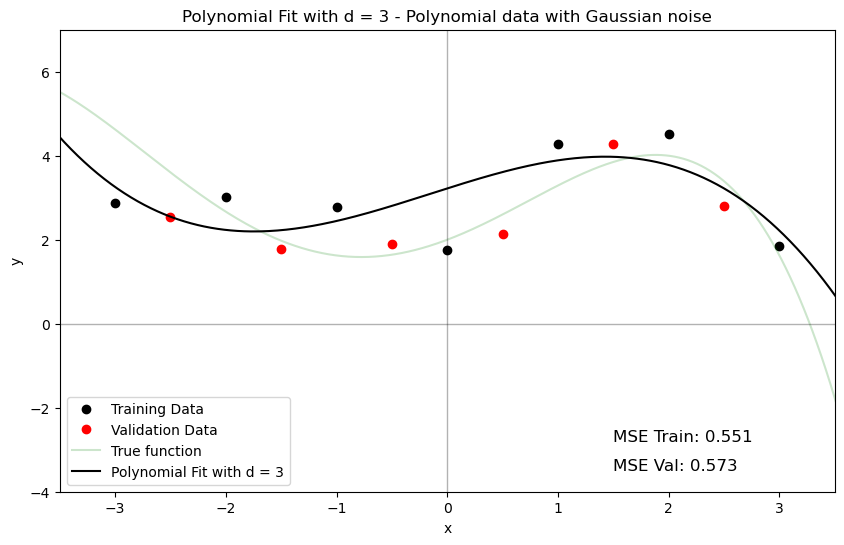

The polynomial is: 2.405444663 +0.8340190925 x +0.7060667129 x**2 -0.1119132856 x**3 -0.0794102718 x**4 



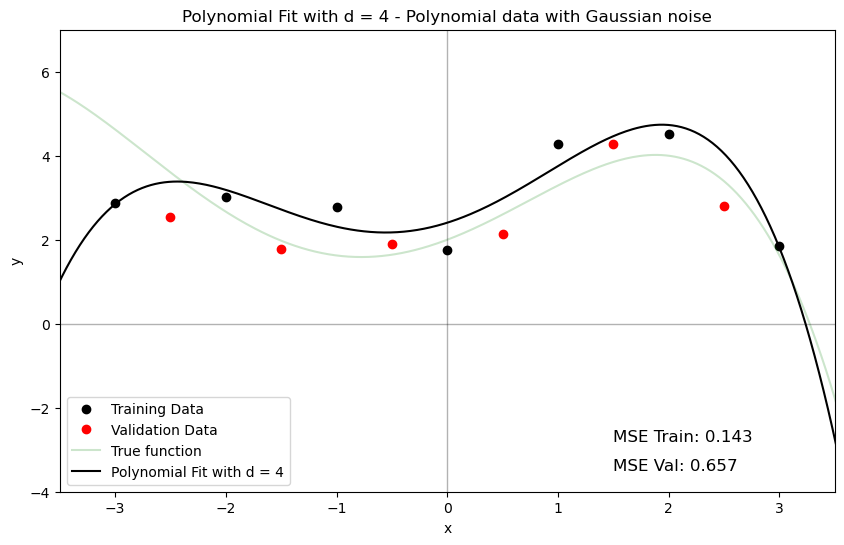

The polynomial is: 2.405444663 +0.8783320583 x +0.7060667129 x**2 -0.1326321341 x**3 -0.0794102718 x**4 +0.0017759013 x**5 



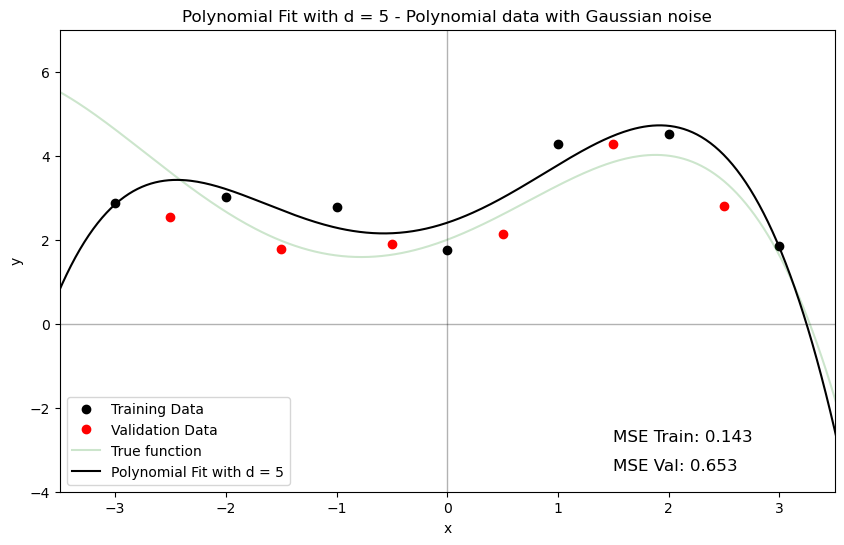

The polynomial is: 1.747563963 +0.8783320583 x +2.37160135 x**2 -0.1326321341 x**3 -0.6358676965 x**4 +0.0017759013 x**5 +0.04221401153 x**6 



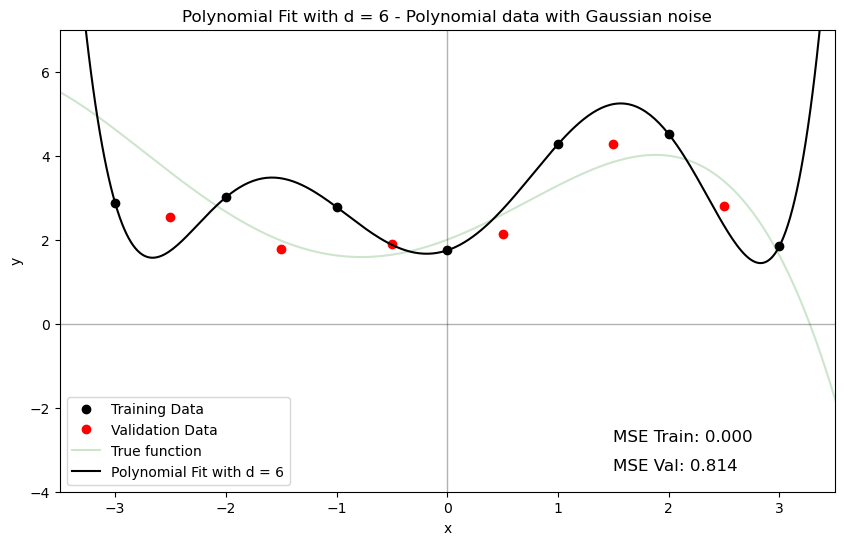

The polynomial is: 1.747563963 +0.5256930017 x +2.37160135 x**2 +0.3473488041 x**3 -0.6358676965 x**4 -0.1353615096 x**5 +0.04221401153 x**6 +0.009795529349 x**7 



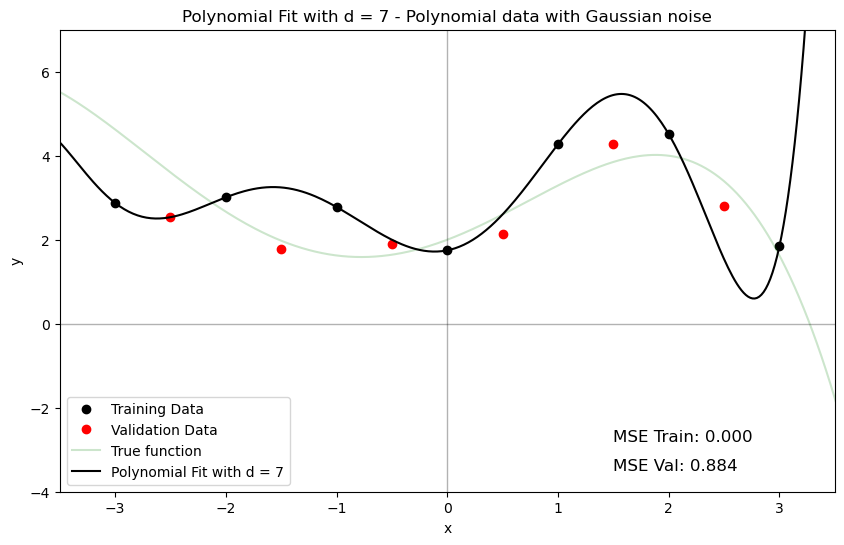

The polynomial is: 1.747563963 +0.5256930017 x +1.288770885 x**2 +0.3473488041 x**3 +0.8379848799 x**4 -0.1353615096 x**5 -0.3788867246 x**6 +0.009795529349 x**7 +0.03007862401 x**8 



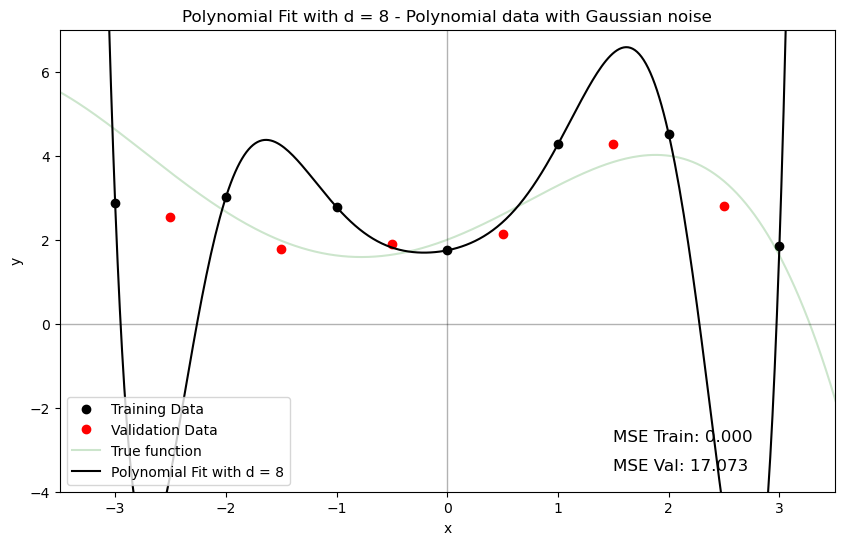

The polynomial is: 1.747563963 +0.3376454437 x +1.288770886 x**2 +0.3061201232 x**3 +0.8379848799 x**4 +0.1960070173 x**5 -0.3788867246 x**6 -0.1005518225 x**7 +0.03007862401 x**8 +0.008255063937 x**9 



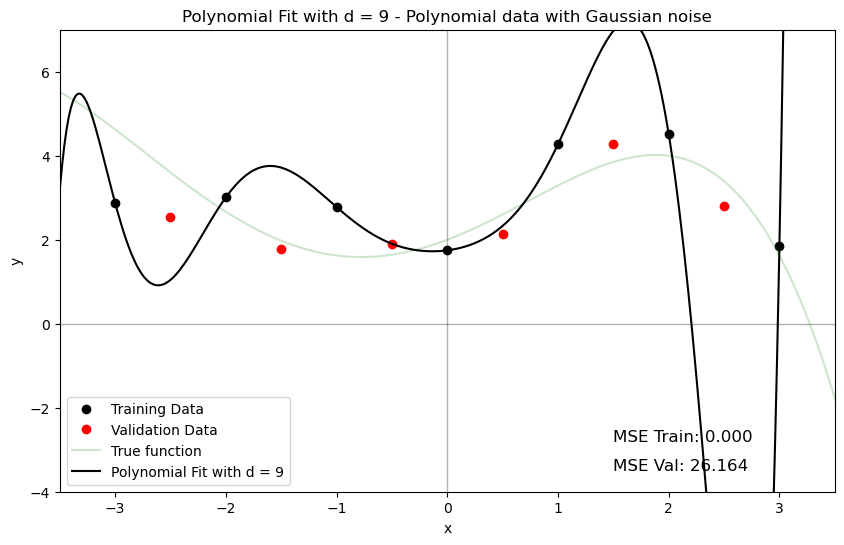

In [280]:
# Assuming polynomial_fits is a list of PolynomialTorch objects and solutions is a list of tuples containing the degree,
# omega solutions, polynomial objects, MSE for training, and MSE for validation.

# Example preparation (ensure these are defined appropriately in your actual code)
# polynomial_fits = [PolynomialTorch(omega_solution)(x) for d in range(8)]
# solutions = [(d, omega_hat, poly, MSE_train, MSE_val) for d, omega_hat, poly, MSE_train, MSE_val in ...]

def plot_polynomial_fits(x_train: torch.Tensor,
                         y_train: torch.Tensor,
                         x_val: torch.Tensor,
                         y_val: torch.Tensor,
                         polynomial_fits: List[Any],  # Replace with appropriate polynomial object type in PyTorch
                         solutions: List[Tuple[int, torch.Tensor, Any, torch.Tensor, torch.Tensor]],
                         dataset_name: str = "Dataset"
                        ) -> None:
    """Plots polynomial fits along with the training and validation data.
    
    Args:
        x_train: Training data x-values.
        y_train: Training data y-values.
        x_val: Validation data x-values.
        y_val: Validation data y-values.
        polynomial_fits: A list of polynomial fitting functions.
        solutions: A list of tuples containing information about each fit, including MSE for training and validation data.
    """
    for i in range(len(polynomial_fits)):
        print("The polynomial is:", polynomial_fits[i], "\n")
        plt.figure(figsize=(10, 6))
        plt.plot(x_train.numpy(), y_train.numpy(), 'o', label='Training Data', color='black')
        plt.plot(x_val.numpy(), y_val.numpy(), 'o', label='Validation Data', color='red')

        # Generate x values for plotting
        x_values: torch.Tensor = torch.linspace(-4., 4., 400, dtype=torch.float64)
        
        # Generate y values for the original function and its polynomial fit
        y_values_func: torch.Tensor = y(x_values)  # Assuming `y(x_values)` is defined in PyTorch
        y_values_fit: torch.Tensor = polynomial_fits[i](x_values)

        # Display MSE values as text on the plot
        mse_train: torch.Tensor = solutions[i][3]
        mse_val: torch.Tensor = solutions[i][4]
        plt.text(1.5, -2.8, f'MSE Train: {mse_train.item():.3f}', fontsize=12, color='black')
        plt.text(1.5, -3.5, f'MSE Val: {mse_val.item():.3f}', fontsize=12, color='black')
        
        # Plot the function and polynomial fit
        plt.plot(x_values.numpy(), y_values_func.numpy(), label='True function', color='green', alpha=0.2)
        plt.plot(x_values.numpy(), y_values_fit.numpy(), label=f'Polynomial Fit with d = {i}', color='black')
        
        # Draw axes
        plt.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
        plt.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
        
        # Finalizing plot
        plt.title(f'Polynomial Fit with d = {i} - {dataset_name}')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.legend(loc='lower left')
        plt.xlim(-3.5, 3.5)
        plt.ylim(-4, 7)
        plt.show()

# Call the function
plot_polynomial_fits(x_train, y_train, x_val, y_val, polynomial_fits, solutions, "Polynomial data with Gaussian noise")


### Probabilistic model (non-polynomial data)

In [281]:
def y(x: torch.Tensor) -> torch.Tensor:
    """Computes the function 3 + sin(x) - cos(x) for given x values.
    
    Args:
        x: A torch tensor of x values.
    
    Returns:
        A torch tensor of y values computed from the function.
    """
    return (3 + torch.sin(x) - torch.cos(x)).double()

def y_stat(x: torch.Tensor) -> torch.Tensor:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.

    Args:
        x: A torch tensor of x values.

    Returns:
        A torch tensor of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values = y(x)

    # Add Gaussian noise with mean 0 and standard deviation 1
    noisy_y_values = torch.normal(mean=true_y_values, std=1.0)

    return noisy_y_values

def y_numpy(x: np.ndarray) -> np.ndarray:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression.
    """
    return 3 + np.sin(x) - np.cos(x)

def y_stat_numpy(x: np.ndarray) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y_numpy(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, 1)
    
    return noisy_y_values

In [282]:
# Generate data coordinates
x_train: torch.Tensor = torch.arange(-3, 4, 1, dtype=torch.float64)
x_val: torch.Tensor = torch.arange(-2.5, 3.5, 1, dtype=torch.float64)

# Generate target values with noise
torch.manual_seed(100)
y_train: torch.Tensor = y_stat(x_train)
y_val: torch.Tensor = y_stat(x_val)

# Notice that the instance of data generated by TensorFlow2 is different than the one generated by numpy. To reproduce the same results as with numpy, one would need to generate data with numpy and then convert it to TensorFlow2 tensors. Comment/uncomment the following lines to use different/same data

# Generate data coordinates
x_train = np.arange(-3., 4., 1)
x_val = np.arange(-2.5, 3.5, 1)

# Generate target values through the statistical model
np.random.seed(100)
y_train = y_stat_numpy(x_train)
y_val = y_stat_numpy(x_val)

# Convert the numpy arrays to PyTorch tensors
x_train = torch.tensor(x_train, dtype=torch.float64)
x_val = torch.tensor(x_val, dtype=torch.float64)
y_train = torch.tensor(y_train, dtype=torch.float64)
y_val = torch.tensor(y_val, dtype=torch.float64)

# Prepare a list to store solutions
solutions: List[Tuple[Any, torch.Tensor, Any, torch.Tensor, torch.Tensor]] = []

# Perform the fit for each degree and print the results
show: bool = True
for d in range(10):
    # Generate the design matrix
    X_train: torch.Tensor = design_matrix(d, x_train)
    
    # Compute the weights of the solution
    omega_hat: torch.Tensor = omega_solution(X_train, y_train)
    
    # Define the fit polynomial
    poly = poly_solution(omega_hat)  # Assuming `poly_solution` is adapted for PyTorch
    
    # Compute the MSE for the training and validation data
    MSE_train: torch.Tensor = MSE(omega_hat, x_train, y_train)
    MSE_val: torch.Tensor = MSE(omega_hat, x_val, y_val)
    
    # Store the results
    solutions.append((d, omega_hat, poly, MSE_train, MSE_val))
    
    # Print the results
    if show:
        print(f"===================================================")
        print(f"---------------------- d = {d} ----------------------")
        print(f"===================================================")
        print(f"The degree of the polynomial is: {d}\n")
        # print(f"The hypothesis is: {poly}\n")
        print(f"The design matrix is:\n{X_train}\n")
        print(f"The solution for omega is: {omega_hat}\n")  
        print(f"The polynomial is: {poly}\n")
        print(f"The MSE for the training data is: {MSE_train}")
        print(f"The MSE for the validation data is: {MSE_val}\n")

# Extract polynomial fits
polynomial_fits = [sol[2] for sol in solutions]

---------------------- d = 0 ----------------------
The degree of the polynomial is: 0

The design matrix is:
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]], dtype=torch.float64)

The solution for omega is: tensor([3.2774], dtype=torch.float64)

The polynomial is: 3.277415435

The MSE for the training data is: 1.2534692480735974
The MSE for the validation data is: 1.3868841559961655

---------------------- d = 1 ----------------------
The degree of the polynomial is: 1

The design matrix is:
tensor([[ 1., -3.],
        [ 1., -2.],
        [ 1., -1.],
        [ 1.,  0.],
        [ 1.,  1.],
        [ 1.,  2.],
        [ 1.,  3.]], dtype=torch.float64)

The solution for omega is: tensor([3.2774, 0.4375], dtype=torch.float64)

The polynomial is: 3.277415435 +0.4375374647 x

The MSE for the training data is: 0.48771311588075067
The MSE for the validation data is: 0.7404351140390483

---------------------- d = 2 ----------------------
The d

/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_86164/1536676131.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.coefficients = torch.tensor(coefficients, dtype=torch.float64)
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_86164/1536676131.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float64)


The polynomial is: 2.520224853 



/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_41146/1536676131.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float64)


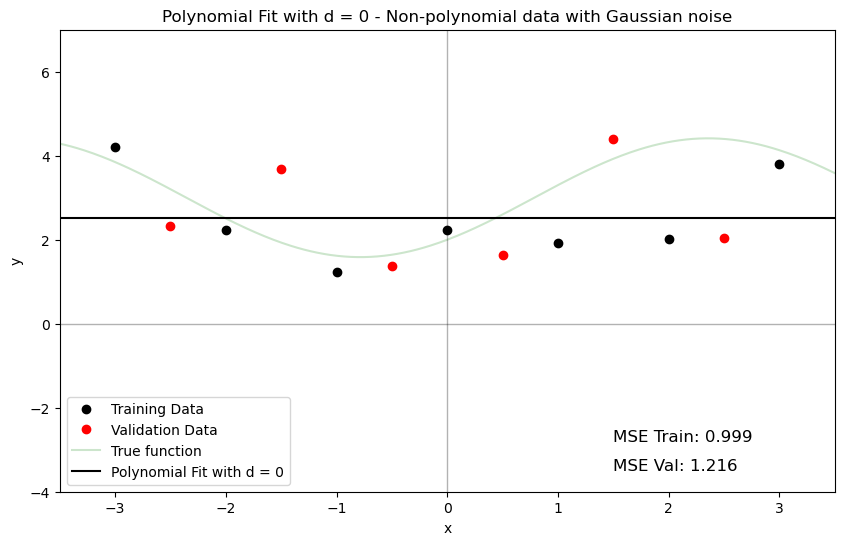

The polynomial is: 2.520224853 -0.03254416742 x 



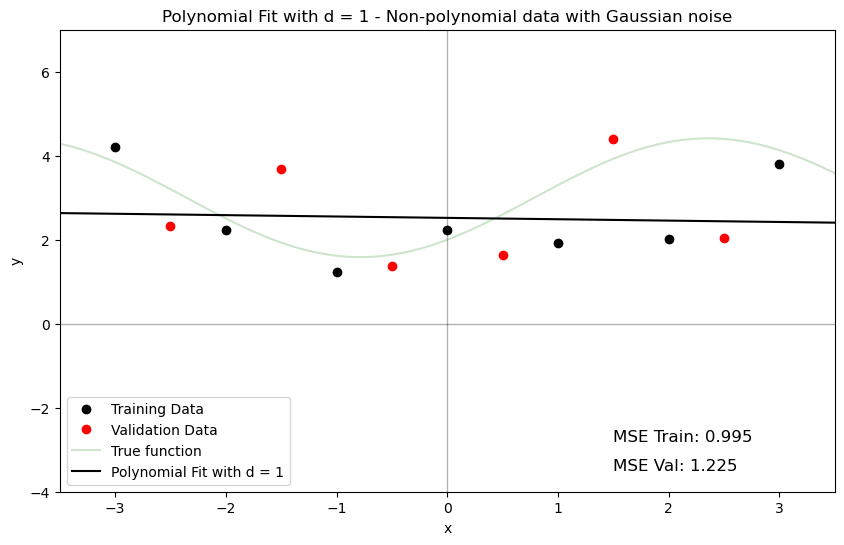

The polynomial is: 1.486000331 -0.03254416742 x +0.2585561304 x**2 



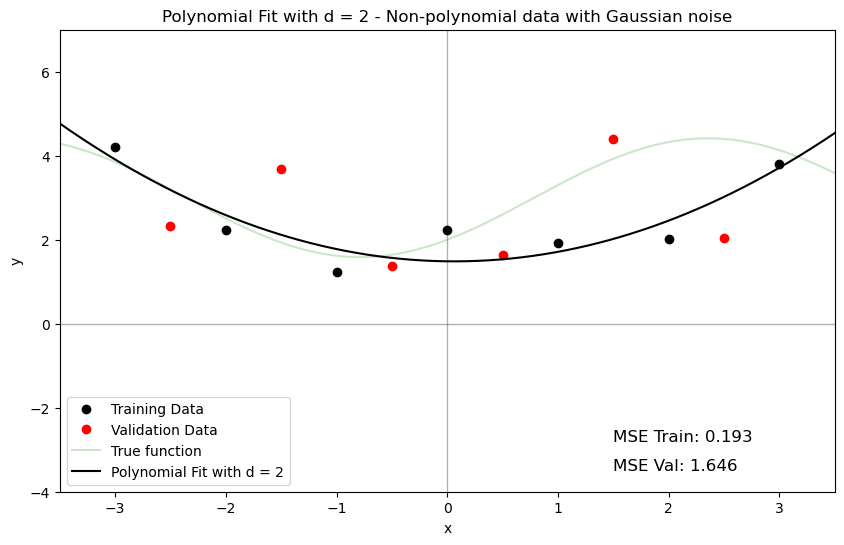

The polynomial is: 1.486000331 +0.1385917707 x +0.2585561304 x**2 -0.02444799116 x**3 



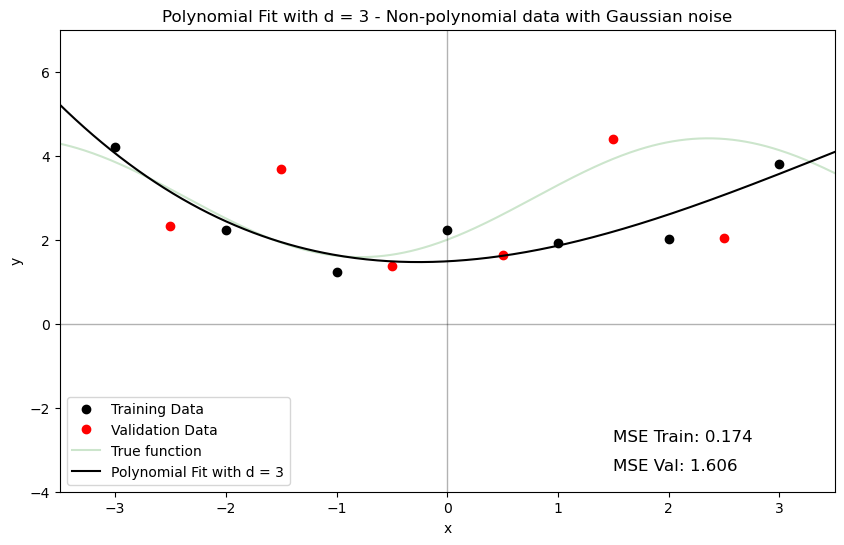

The polynomial is: 1.916117089 +0.1385917707 x -0.1416914082 x**2 -0.02444799116 x**3 +0.04181690702 x**4 



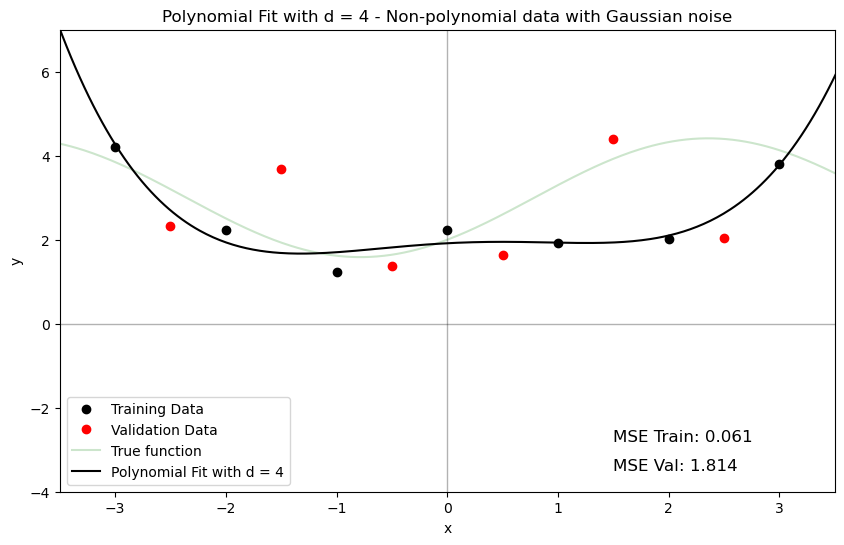

The polynomial is: 1.916117089 +0.5448219874 x -0.1416914082 x**2 -0.2143838749 x**3 +0.04181690702 x**4 +0.01628021861 x**5 



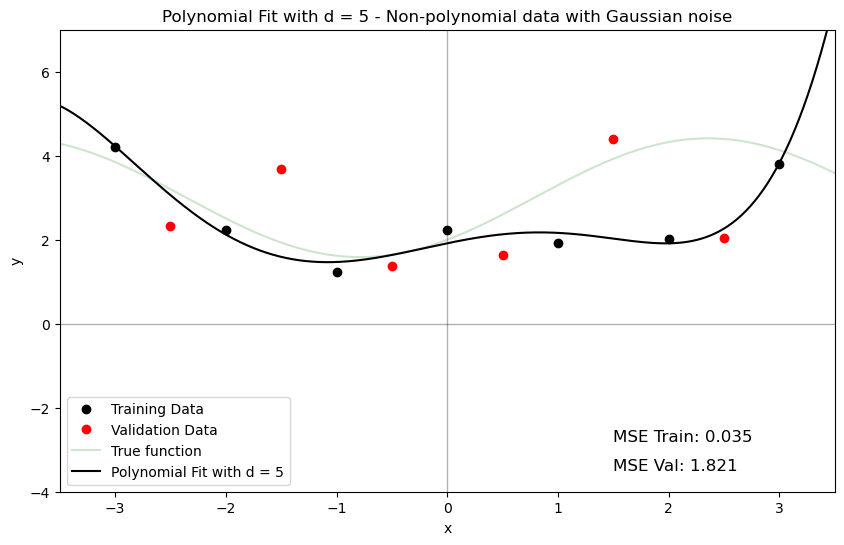

The polynomial is: 2.242937923 +0.5448219874 x -0.9690928177 x**2 -0.2143838749 x**3 +0.3182528618 x**4 +0.01628021861 x**5 -0.02097100347 x**6 



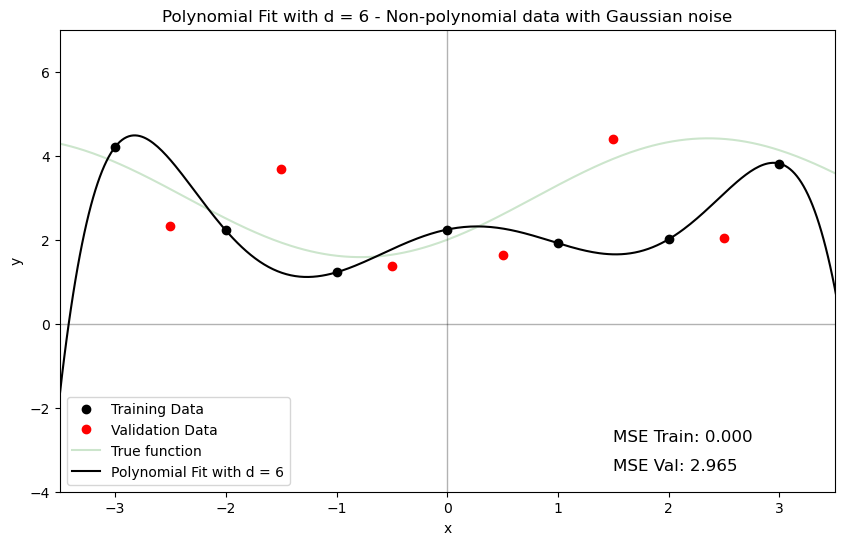

The polynomial is: 2.242937923 +0.2642704514 x -0.9690928177 x**2 +0.167477938 x**3 +0.3182528618 x**4 -0.0928231565 x**5 -0.02097100347 x**6 +0.007793098222 x**7 



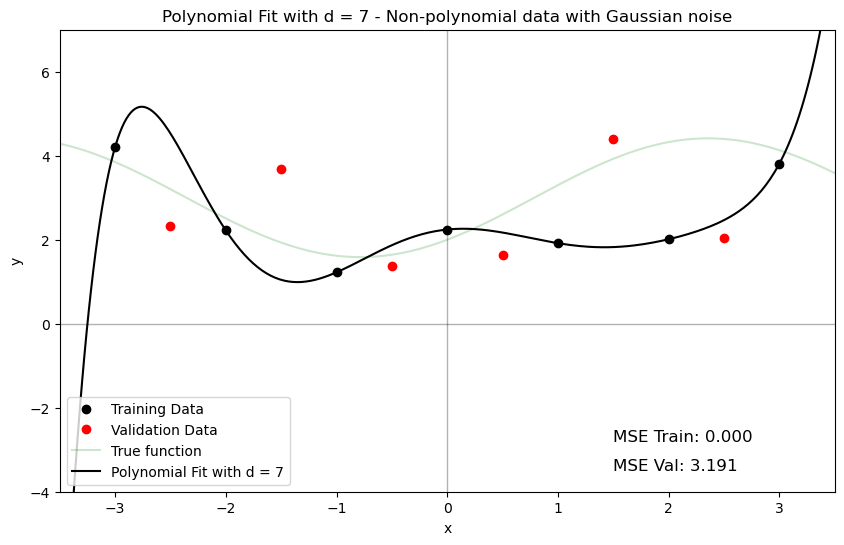

The polynomial is: 2.242937923 +0.2642704516 x -0.499675322 x**2 +0.1674779377 x**3 -0.3206765076 x**4 -0.09282315642 x**5 +0.1615802449 x**6 +0.007793098216 x**7 -0.01303937489 x**8 



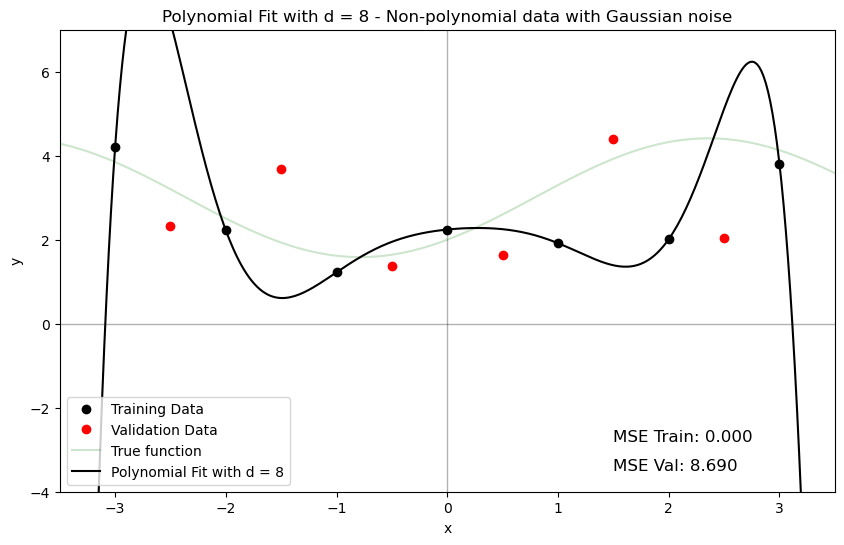

The polynomial is: 2.242937923 +0.1600079891 x -0.499675323 x**2 +0.1446188069 x**3 -0.3206765062 x**4 +0.09090323122 x**5 +0.1615802445 x**6 -0.05338869395 x**7 -0.01303937486 x**8 +0.004576997978 x**9 



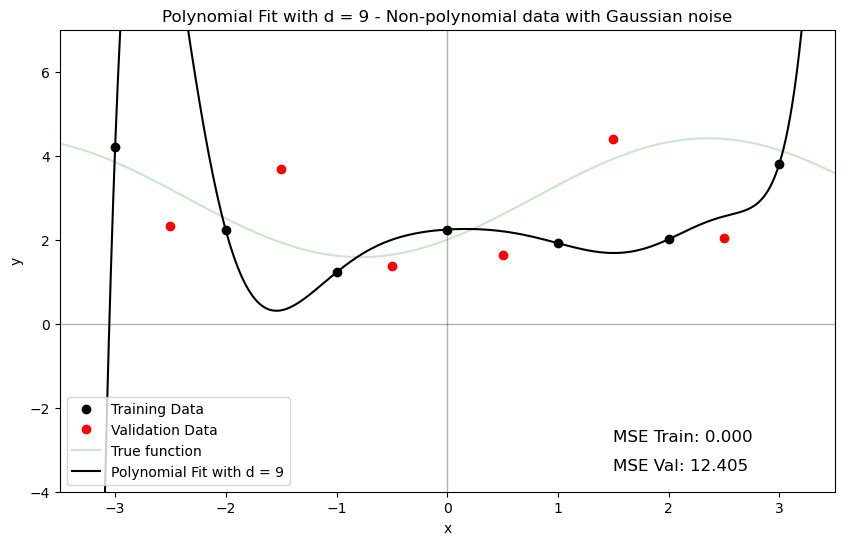

In [140]:
plot_polynomial_fits(x_train, y_train, x_val, y_val, polynomial_fits, solutions, "Non-polynomial data with Gaussian noise")

### Probabilistic model with non-polynomial fit (non-polynomial data)

In [288]:
def y(x: torch.Tensor) -> torch.Tensor:
    """Computes the function 3 + sin(x) - cos(x) for given x values.
    
    Args:
        x: A torch tensor of x values.
    
    Returns:
        A torch tensor of y values computed from the function.
    """
    return (3 + torch.sin(x) - torch.cos(x)).double()

def y_stat(x: torch.Tensor) -> torch.Tensor:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.

    Args:
        x: A torch tensor of x values.

    Returns:
        A torch tensor of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values = y(x)

    # Add Gaussian noise with mean 0 and standard deviation 1
    noisy_y_values = torch.normal(mean=true_y_values, std=1.0)

    return noisy_y_values

def y_numpy(x: np.ndarray) -> np.ndarray:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression.
    """
    return 3 + np.sin(x) - np.cos(x)

def y_stat_numpy(x: np.ndarray) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y_numpy(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, 1)
    
    return noisy_y_values

def design_matrix_trig_torch(x_values: torch.Tensor) -> torch.Tensor:
    """Generates a design matrix for trigonometric regression with PyTorch.
    
    Args:
        x_values: A torch.Tensor of x values.
    
    Returns:
        A torch.Tensor representing the design matrix with columns for 1, sin(x), and cos(x).
    """
    ones = torch.ones_like(x_values)
    sin_x = torch.sin(x_values)
    cos_x = torch.cos(x_values)
    # Stack along the second dimension (axis=1) to form the design matrix
    return torch.stack([ones, sin_x, cos_x], dim=1)

def omega_solution(X: torch.Tensor, 
                   Y: torch.Tensor
                  ) -> torch.Tensor:
    """Calculates the polynomial coefficients (omega) that best fit the data.
    
    Args:
        X: The design matrix.
        Y: A torch tensor of target y values.
    
    Returns:
        A torch tensor of calculated omega values.
    """
    XT: torch.Tensor = X.t()  # Transpose of X
    Y: torch.Tensor = Y.view(-1, 1)  # Reshape Y to be a column vector
    omega: torch.Tensor = torch.linalg.pinv(XT @ X) @ XT @ Y
    return omega.view(-1)  # Flatten the omega tensor

def trig_solution(omega_solution: torch.Tensor, 
                  x_values: torch.Tensor
                 ) -> torch.Tensor:
    """Evaluates the trigonometric model at given x values using the omega coefficients.
    
    Args:
        omega_solution: A torch.Tensor of omega coefficients for [constant, sin(x), cos(x)].
        x_values: A torch.Tensor of x values for evaluation.
    
    Returns:
        A torch.Tensor of y values predicted by the trigonometric model.
    """
    return omega_solution[0] + omega_solution[1] * torch.sin(x_values) + omega_solution[2] * torch.cos(x_values)

def MSE(omega_solution: torch.Tensor, 
        x_values: torch.Tensor, 
        y_true: torch.Tensor
       ) -> torch.Tensor:
    """
    Calculates the Mean Squared Error (MSE) for given omega coefficients and x values.
    Uses PyTorch's MSE loss function.
    
    Args:
        omega_solution: A 1D torch.Tensor of omega coefficients.
        x_values: A 1D torch.Tensor of x values for evaluation.
        y_true: A 1D torch.Tensor of true y values.
    
    Returns:
        The MSE as a torch.Tensor.
    """
    y_pred: torch.Tensor = trig_solution(omega_solution, x_values)
    loss: torch.Tensor = F.mse_loss(y_pred, y_true)
    return loss

In [289]:
# Generate data coordinates
x_train = torch.arange(-3, 4, 1, dtype=torch.float64)
x_val = torch.arange(-2.5, 3.5, 1, dtype=torch.float64)

# Generate target values through the statistical model with torch
torch.manual_seed(100)
y_train = y_stat(x_train)
y_val = y_stat(x_val)

# Notice that the instance of data generated by TensorFlow2 is different than the one generated by numpy. To reproduce the same results as with numpy, one would need to generate data with numpy and then convert it to TensorFlow2 tensors. Comment/uncomment the following lines to use different/same data

# Generate data coordinates
x_train = np.arange(-3., 4., 1)
x_val = np.arange(-2.5, 3.5, 1)

# Generate target values through the statistical model
np.random.seed(100)
y_train = y_stat_numpy(x_train)
y_val = y_stat_numpy(x_val)

# Convert the numpy arrays to PyTorch tensors
x_train = torch.tensor(x_train, dtype=torch.float64)
x_val = torch.tensor(x_val, dtype=torch.float64)
y_train = torch.tensor(y_train, dtype=torch.float64)
y_val = torch.tensor(y_val, dtype=torch.float64)

# Flag to control printing of the solution details
show = True

# Generate the design matrix
X_train = design_matrix_trig_torch(x_train)

# Compute the weights of the solution
omega_hat = omega_solution(X_train, y_train)

# Compute the MSE for the training and validation data
MSE_train = MSE(omega_hat, x_train, y_train)
MSE_val = MSE(omega_hat, x_val, y_val)

# Print the results
if show:
    print("----------------- Trigonometric Model -----------------")
    print(f"The design matrix is:\n{X_train}\n")
    print(f"The target values are:\n{y_train}\n")
    print(f"The solution for omega is: {omega_hat}\n")
    print(f"The MSE for the training data is: {MSE_train}")
    print(f"The MSE for the validation data is: {MSE_val}\n")

----------------- Trigonometric Model -----------------
The design matrix is:
tensor([[ 1.0000, -0.1411, -0.9900],
        [ 1.0000, -0.9093, -0.4161],
        [ 1.0000, -0.8415,  0.5403],
        [ 1.0000,  0.0000,  1.0000],
        [ 1.0000,  0.8415,  0.5403],
        [ 1.0000,  0.9093, -0.4161],
        [ 1.0000,  0.1411, -0.9900]], dtype=torch.float64)

The target values are:
tensor([2.0991, 2.8495, 2.7713, 1.7476, 4.2825, 4.8397, 4.3523],
       dtype=torch.float64)

The solution for omega is: tensor([ 3.2327,  1.0931, -0.4274], dtype=torch.float64)

The MSE for the training data is: 0.6231208529025825
The MSE for the validation data is: 0.4426790841588111



Fit with true function



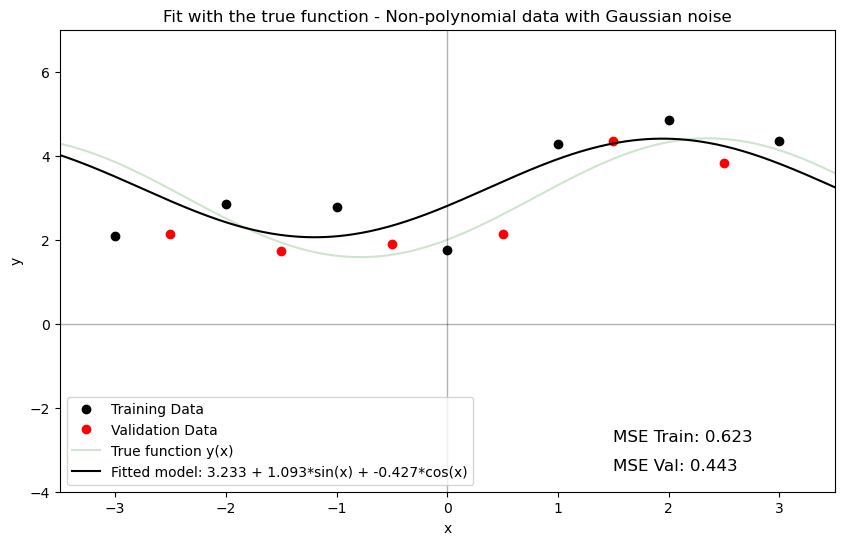

In [290]:
# Print the results
print("Fit with true function\n")
omega_hat_str = f"{omega_hat[0]:.3f} + {omega_hat[1]:.3f}*sin(x) + {omega_hat[2]:.3f}*cos(x)"

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_train.numpy(), y_train, 'o', label='Training Data', color='black')
plt.plot(x_val.numpy(), y_val, 'o', label='Validation Data', color='red')

# Generate x values for plotting (to create a smooth curve for the plot)
x_values = torch.linspace(-4., 4., 400, dtype=torch.float64)

# Generate y values for the function and the fitted model
y_values_func = y(x_values)
y_values_fit = trig_solution(omega_hat, x_values)

# Plot the results
plt.text(1.5, -2.8, f'MSE Train: {MSE_train:.3f}', fontsize=12, color='black')
plt.text(1.5, -3.5, f'MSE Val: {MSE_val:.3f}', fontsize=12, color='black')
plt.plot(x_values.numpy(), y_values_func.numpy(), label='True function y(x)', color='green', alpha=0.2)
plt.plot(x_values.numpy(), y_values_fit.numpy(), label=f'Fitted model: {omega_hat_str}', color='black')

# Drawing axes
plt.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Finalizing plot
plt.title('Fit with the true function - Non-polynomial data with Gaussian noise')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='lower left')
plt.xlim(-3.5, 3.5)
plt.ylim(-4, 7)
plt.show()